# Fetal health from cardiotocography, step by step

A walkthrough of one classification problem, built one change at a time.

**How to read this notebook.** Sections 2 onward all have the same three parts:

1. a heading block stating the question, what the code does and what to look for,
2. one code cell, commented line by line,
3. a finding block with the number and what it changes.

Section 0 draws two figures and section 1 is prose, so neither measures anything. Sections
10 to 17 and section 21 are the ones that change the model, and each of those ends its code
cell with a **state of play** panel: what changed, what that measured, the best result so
far, and the question the next section answers. If you lose the thread, that panel is where
you pick it up. The sections before 10 describe the data, and sections 18 to 20 and 22 take
the finished model apart without changing it, so none of those moves the running total or
carries a panel.

**One forward reference that is structural rather than incidental.** Sections point ahead to
each other throughout, which is normal. This one is different because the notebook's method
depends on it: section 8 writes down a list of candidate features and commits to testing them
in section 15, before any model has been fitted. That gap is
the point of it. Everything else reads in order, and where a later section needs an
earlier number it repeats the number rather than pointing back.

**What this file needs to run.** `fetal_health.csv` in `data/`, and for section 0's two
illustrations, `figs/07_ctg_anatomy.png` and `figs/08_ctg_histogram.png` from
`ctg_anatomy.py`. Nothing is imported from a project module, so every definition the
analysis uses is visible at the point it is used.

## Setup

Imports and the raw file. Nothing is decided here.

In [1]:
# ------------------------------------------------------------------ imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# scikit-learn: the split, the folds, the metrics, the linear model
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, roc_auc_score)
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# the gradient-boosted tree, and the two resampling methods compared in section 16
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

import shap

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# One seed wherever a MODEL needs one, so any two runs of this notebook agree. Fold
# assignments deliberately use their own varying seeds, for reasons section 12 measures.
SEED = 42

# ------------------------------------------------------------------ the raw file
for candidate in [Path("data/fetal_health.csv"),
                  Path("../data/fetal_health.csv"),
                  Path("/mnt/user-data/uploads/fetal-health-ctg/data/fetal_health.csv")]:
    if candidate.exists():
        DATA_PATH = candidate
        break
else:
    raise FileNotFoundError(
        "fetal_health.csv not found. Download it from kaggle.com/datasets/"
        "andrewmvd/fetal-health-classification and put it in data/ beside this notebook.")

raw = pd.read_csv(DATA_PATH)

# The label column uses 1/2/3. Remapped to 0/1/2 once, here, because XGBoost's
# multiclass objective requires labels starting at zero and a convention that shifts
# halfway down a notebook is a reliable source of silent mistakes.
CLASS_NAMES = {0: "Normal", 1: "Suspect", 2: "Pathological"}
PATHOLOGICAL = 2               # the class index this whole notebook is about
NON_PATHOLOGICAL = [0, 1]      # the classes a row falls back to below a cutoff
raw["label"] = raw["fetal_health"].astype(int) - 1

# The 21 measurement columns, without either label column.
MEASURE_COLS = [c for c in raw.columns if c not in ("fetal_health", "label")]

print(f"loaded {DATA_PATH}")
print(f"{len(raw)} rows, {len(MEASURE_COLS)} measurement columns")


loaded data/fetal_health.csv
2126 rows, 21 measurement columns


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 0. What a cardiotocograph is, and how a midwife reads one

Everything below rests on 21 numbers that came out of a machine. This section is about
what that machine was pointed at, because a column called
`percentage_of_time_with_abnormal_long_term_variability` means nothing until you have
seen the thing it is measuring.

**Two sensors, strapped to the mother's abdomen.** An ultrasound transducer picks up the
fetal heart and reports a rate, beat by beat. A pressure sensor called a tocodynamometer
sits over the top of the uterus and reports how hard it is squeezing. Both write to the
same time axis, and reading them together is the whole skill.

**Four things are read off the fetal heart rate trace**, and they are the four that FIGO's
2015 intrapartum guidance names:

| what | normal | why it matters |
|---|---|---|
| **baseline** | 110 to 160 beats per minute | the resting rate, judged over ten minutes with the wobbles ignored |
| **variability** | 5 to 25 beats per minute of wobble | a healthy nervous system constantly adjusts the rate, a flat trace means that regulation has stopped |
| **accelerations** | present | a rise of 15 beats for 15 seconds, usually with movement, and strongly reassuring |
| **decelerations** | absent, or early only | a drop in rate, and the single most important reading on the trace |

**Decelerations are where the judgement lives**, and it is entirely about timing. A dip
that starts as a contraction starts and recovers as it ends is an **early** deceleration,
caused by the baby's head being squeezed, and it is harmless. The same shaped dip
arriving after the contraction peaks is a **late** deceleration, meaning the placenta
could not deliver enough oxygen while the squeeze reduced its blood supply, and repeated
late decelerations are the classic Pathological finding. **The two look nearly identical
in isolation and differ only in when they arrive.**

**What hypoxia does to the trace, in order.** Blood flow through the placenta falls
during a contraction. If reserve is good the baby rides it out. If not, chemoreceptors
fire and the rate drops, which is the deceleration. Sustained oxygen debt then suppresses
the autonomic regulation that produces variability, so the wobble flattens. Accelerations
stop, because a baby short of oxygen stops moving. **Reduced variability with absent
accelerations and repeated late decelerations is the picture, and it is a sequence rather
than three separate findings.**

**What SisPorto did to all of this.** It took each 20-minute recording and reduced it to
21 numbers: some counts of events per second, some measures of variability, and ten
statistics of a histogram built from every heart-rate value in the recording. **The
timing was thrown away.** Nothing in the 21 numbers records when a deceleration arrived
relative to a contraction, which means the single most important distinction on the trace
is not in the file. Section 8 comes back to that, because it sets the ceiling on what any
model here can do.

The two figures below are illustrative traces, drawn rather than measured from a patient.
The first shows where the recording comes from and names each feature on it. The second
takes one trace and builds the histogram, so the ten `histogram_*` columns stop being
abstract names.

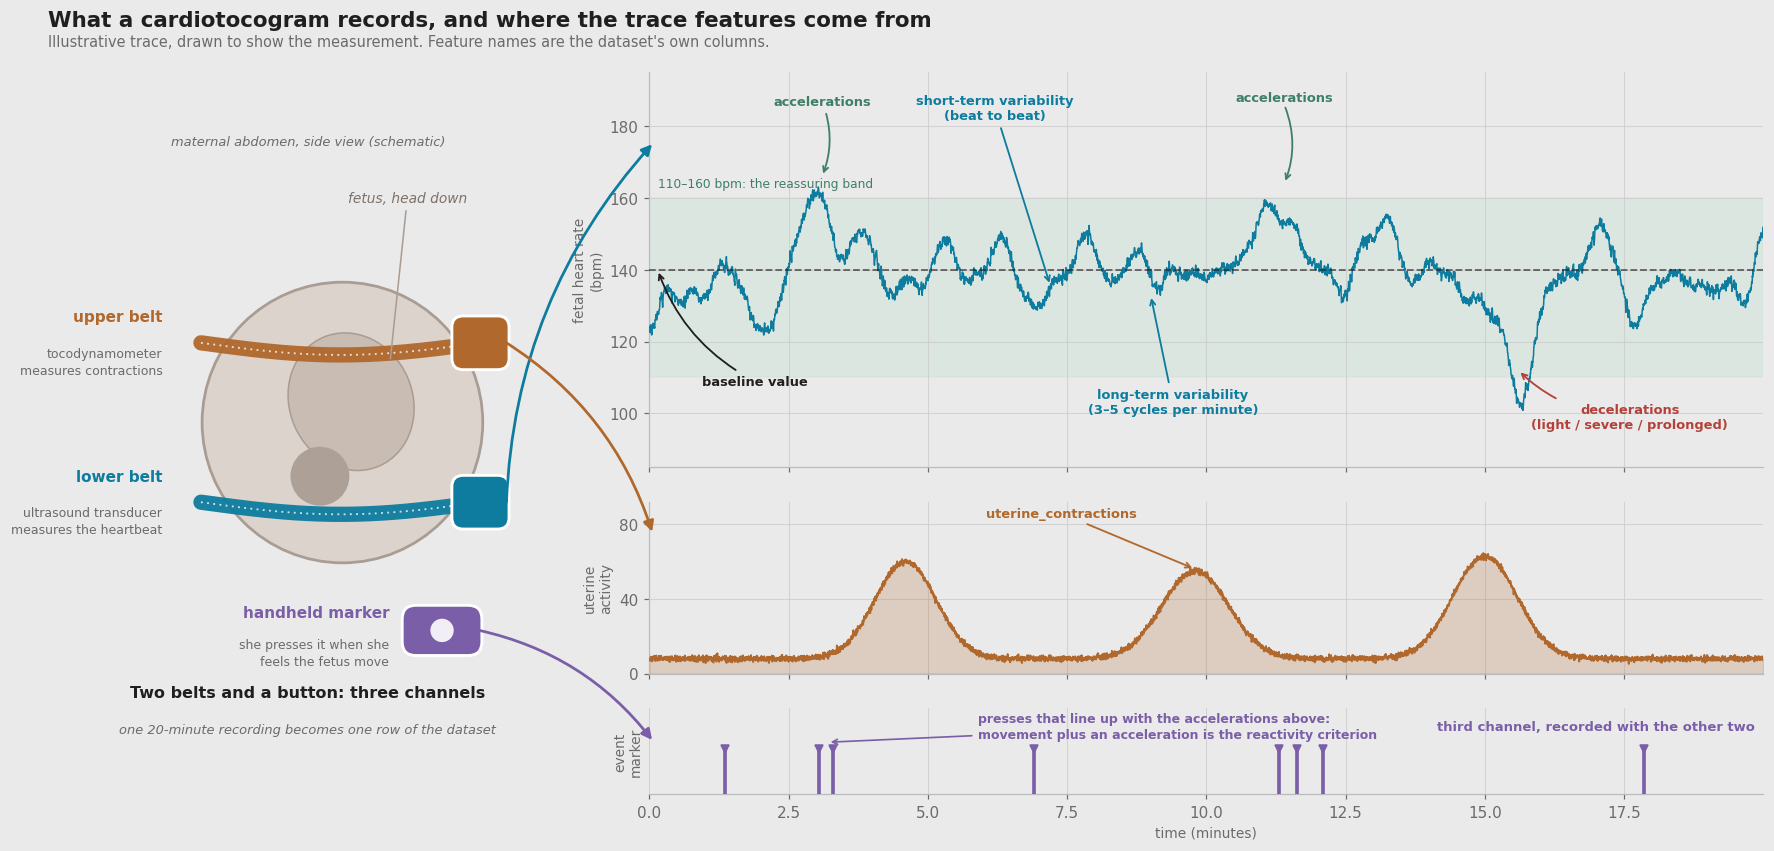

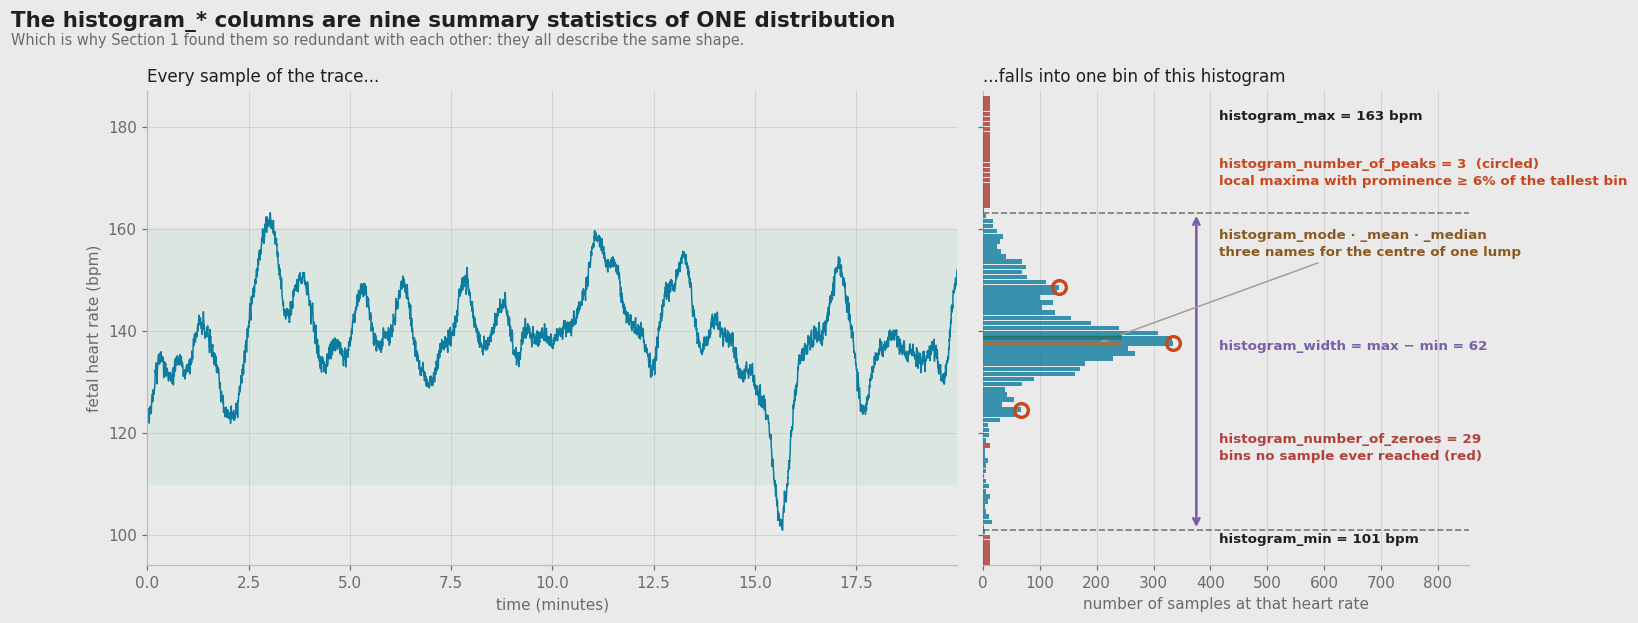

In [2]:
# Two explainer figures, drawn by ctg_anatomy.py in this project folder rather than
# rebuilt here: they are illustration, not analysis, and nothing below depends on them.
from IPython.display import Image, display

for name in ("07_ctg_anatomy.png", "08_ctg_histogram.png"):
    for folder in ("figs", "../figs", "/mnt/user-data/uploads/fetal-health-ctg/figs"):
        path = Path(folder) / name
        if path.exists():
            display(Image(filename=str(path)))
            break
    else:
        print(f"{name} not found. Run ctg_anatomy.py to regenerate it into figs/.")


**Reading the first figure.** Two belts and a button. The lower belt
holds an ultrasound transducer over the fetal heart and produces the blue trace. The upper
belt holds a pressure sensor over the top of the uterus and produces the brown one. The
mother presses the handheld marker when she feels movement, which is the third strip along
the bottom.

Every label on the blue trace is a column name in the file. `baseline value` is the dashed
line, the accelerations and decelerations are the events the arrows point at, and the two
variability measures are the fine jitter and the slower wander.

**What the figure cannot show is the thing that matters most.** A deceleration that starts
and ends with a contraction is early and harmless. The same dip arriving after the
contraction peaks is late, and repeated late decelerations are the classic Pathological
finding. **The two differ only in when they arrive, and the file records that a
deceleration happened without recording when.** Section 8 returns to this, because it is
the ceiling on what any model built from these 21 numbers can do.

**Reading the second figure.** One trace on the left, and on the right the histogram of
every heart-rate value in it. That histogram is all that survives into the dataset: its
maximum, its minimum, the width between them, its peaks, its empty bins, and three
different names for the centre of the same lump. The trace itself is discarded.

Two things on it are worth pointing at. **`histogram_width` is drawn as the distance
between max and min**, because that is exactly what it is, which section 14 confirms holds
on every one of the 1,687 training rows. The held-out rows are not checked, because at that
point in the notebook they are not allowed to be looked at. And **`histogram_mode`, `_mean` and `_median` all label the same
central lump**, which is why section 14 replaces them with one number.

*Both figures were drawn for the companion notebook, so the section numbers written on the
second one refer to that document rather than to this one.*

## 1. The case study

The dataset is 2,126 twenty-minute recordings from Portuguese hospitals, each reduced to
the 21 numbers section 0 described. Three obstetricians then read the original traces and
agreed a label for each one:

- **Normal**, no action needed,
- **Suspect**, watch more closely,
- **Pathological**, intervene.

**The question this notebook answers.** Given the 21 numbers, can a model recover the
obstetricians' judgement, and specifically, can it find the Pathological cases?

**Why that last clause carries all the weight.** The three errors are not
interchangeable. Calling a Normal reading Pathological wastes a midwife's time. Calling a
Pathological reading Normal misses an intervention. Every design decision below is made
with that asymmetry in mind, and the rule in section 9 is written to enforce it.

One limit worth stating at the start, because it bounds everything that follows: the
labels are three experts' opinions, not verified outcomes. Nobody checked afterwards which
babies were actually in trouble. A model that matched these labels perfectly would have
reproduced expert judgement, not the truth.

## 2. What the 21 numbers are

**The question.** The columns have names like `abnormal_short_term_variability`. What is each one measuring, and which of them describe the same thing?

**What the code does.** Groups the columns by which part of the recording they come from, and prints one row of real data alongside each, so the names have values attached to them.

**What to look for.** Four groups, and the fact that ten of the 21 columns are summaries of a single histogram rather than independent measurements.

In [3]:
# The 21 columns fall into four groups by what part of the recording they describe.
# Grouped by hand rather than programmatically, because the grouping is a claim about the
# domain and not something the column names can tell you.
GROUPS = {
    "the baseline heart rate": ["baseline value"],
    "events counted per second of recording": [
        "accelerations", "fetal_movement", "uterine_contractions",
        "light_decelerations", "severe_decelerations", "prolongued_decelerations"],
    "variability, how much the rate wanders": [
        "abnormal_short_term_variability", "mean_value_of_short_term_variability",
        "percentage_of_time_with_abnormal_long_term_variability",
        "mean_value_of_long_term_variability"],
    "summaries of the heart-rate histogram": [
        "histogram_width", "histogram_min", "histogram_max", "histogram_number_of_peaks",
        "histogram_number_of_zeroes", "histogram_mode", "histogram_mean",
        "histogram_median", "histogram_variance", "histogram_tendency"],
}

example = raw.iloc[0]          # one real recording, to put a value against each name
for group_name, columns in GROUPS.items():
    print(f"{group_name.upper()}  ({len(columns)} columns)")
    for col in columns:
        print(f"    {col:58s} {example[col]:>9}")
    print()

# The histogram group is the one to notice. SisPorto builds a histogram of all the
# heart-rate values in the 20 minutes, then reports ten statistics about it. Those ten are
# not ten measurements, they are ten views of one object, as section 0's second figure
# shows directly.
hist_cols = GROUPS["summaries of the heart-rate histogram"]
print(f"{sum(len(v) for v in GROUPS.values())} columns in total, of which "
      f"{len(hist_cols)} describe the same histogram.")

# Look at the row above before reading on: its mean is 137 while its max is 126. A mean
# cannot sit outside the range of the values it averages, so at least one of those three
# numbers is not what its name says. Worth measuring rather than explaining away, because
# section 14 later collapses the three centre statistics into one number and that decision
# should be made knowing how well they behave.
print()
print("a check the example row invites:")
for c in ["histogram_mean", "histogram_median", "histogram_mode"]:
    bad = ((raw[c] < raw["histogram_min"]) | (raw[c] > raw["histogram_max"])).sum()
    print(f"  {c:20s} outside its own [min, max] on {bad:>4d} of {len(raw)} rows")
print()
print("  One row in the whole file, and it is row 0, which is the row printed above. Bad")
print("  luck rather than a pattern. What to do about it is a cleaning decision, so it is")
print("  made in section 4, where the same question is asked of all twelve relationships")
print("  these columns have to satisfy, and argued there rather than settled here.")


THE BASELINE HEART RATE  (1 columns)
    baseline value                                                 120.0

EVENTS COUNTED PER SECOND OF RECORDING  (6 columns)
    accelerations                                                    0.0
    fetal_movement                                                   0.0
    uterine_contractions                                             0.0
    light_decelerations                                              0.0
    severe_decelerations                                             0.0
    prolongued_decelerations                                         0.0

VARIABILITY, HOW MUCH THE RATE WANDERS  (4 columns)
    abnormal_short_term_variability                                 73.0
    mean_value_of_short_term_variability                             0.5
    percentage_of_time_with_abnormal_long_term_variability          43.0
    mean_value_of_long_term_variability                              2.4

SUMMARIES OF THE HEART-RATE HISTOGRAM  (10 columns)
 

**Finding: 21 columns, but fewer than 21 measurements.**

Ten of the 21 describe a single object. SisPorto builds one histogram of every heart-rate
value in the 20 minutes, then reports its width, its minimum, its maximum, its peaks, its
zeroes, its mode, its mean, its median, its variance and which way it leans. Section 0's
second figure is that histogram being built, with those labels drawn onto it.

That matters twice over. A model given ten overlapping columns spends its capacity
rediscovering that they overlap, and a reader given ten importance scores cannot tell
whether the histogram matters ten times or once. Section 14 takes the overlap apart one
decision at a time.

**The printed row is worth a second look before moving on.** Its `histogram_mean` is 137
while its `histogram_max` is 126. A mean cannot sit above the largest value it averages, so
one of those two numbers is not what its name says. The check underneath finds that this
happens on exactly one row of 2,126, and that row is the one printed, which is bad luck
rather than a pattern.

What to do about it is a cleaning decision, so section 4 makes it. That section asks the same
question of all twelve relationships these columns have to satisfy if their names mean what
they say, finds that eleven come back empty, and then argues out loud about the one row this
check catches. The short version is that the row is kept and the argument for keeping it is
the weakest one in the notebook, which is why section 4 states it plainly and section 21
measures what it costs.

The other groups are cleaner. One column for the baseline rate, six counting events per
second of recording, four describing how much the rate wanders. The event counts are the
ones an obstetrician would name first, because decelerations are what a CTG is read for.

## 3. The target, and how lopsided it is

**The question.** How many of each class are there?

**What the code does.** Counts the three labels and prints them as counts and as shares.

**What to look for.** How few Pathological cases there are. That number governs every decision after it.

In [4]:
counts = raw["label"].value_counts().sort_index()
print("the three classes in the raw file:\n")
for k in (0, 1, 2):
    print(f"  {CLASS_NAMES[k]:14s} {counts[k]:5d} readings   {counts[k]/len(raw):6.1%}")
print(f"\n  {'total':14s} {len(raw):5d}")
print(f"\nNormal outnumbers Pathological {counts[0]/counts[2]:.1f} to 1.")


the three classes in the raw file:

  Normal          1655 readings    77.8%
  Suspect          295 readings    13.9%
  Pathological     176 readings     8.3%

  total           2126

Normal outnumbers Pathological 9.4 to 1.


**Finding: Normal outnumbers Pathological 9.4 to 1.**

1,655 Normal, 295 Suspect, 176 Pathological. The class this project exists to catch is
8.3% of the file.

**Two consequences, and both shape everything below.** A model that ignores the data
entirely and answers Normal every time is right about 78% of the time, which section 10
measures directly. And every estimate of how well the model finds Pathological cases rests
on 176 readings in the raw file, 175 after section 4's cleaning, which is a small enough
number that the arithmetic of a single case
becomes visible. Section 9 turns that into a rule about what size of difference is worth
reporting.

## 4. Three problems in the raw rows, two of them worth acting on

**The question.** Before anything is explored or modelled, are all 2,126 rows usable?

**What the code does.** Looks for three faults: rows whose 21 measurements are identical but whose labels disagree, rows that are exact duplicates of another row, and rows that contradict themselves on relationships the column names guarantee. Removes the first two, and explains why this change is not measured for its effect on accuracy.

**What to look for.** A small number of rows, a reason for removing them that has nothing to do with making the score better, and one row that is kept despite failing a check.

In [5]:
# ---- problem 1: identical measurements, different labels ----------------------
# Group by the full set of measurements. Any group with more than one distinct label is a
# contradiction: the same recording was judged two different ways.
grouped = raw.groupby(MEASURE_COLS, sort=False)["label"].nunique()
conflicting_keys = grouped[grouped > 1]
conflict_mask = raw.duplicated(subset=MEASURE_COLS, keep=False) & \
    raw.set_index(MEASURE_COLS).index.isin(conflicting_keys.index)

print(f"rows whose measurements match another row but whose label differs: "
      f"{int(conflict_mask.sum())}")
if conflict_mask.any():
    print(raw.loc[conflict_mask, MEASURE_COLS[:4] + ["label"]].to_string())
print()

# ---- problem 2: exact duplicates ----------------------------------------------
dup_mask = raw.duplicated(subset=MEASURE_COLS + ["label"], keep="first")
print(f"exact duplicate rows (same measurements, same label): {int(dup_mask.sum())}")
print()

# ---- remove both, before anything else happens --------------------------------
# The ORDER matters and it is the one subtle thing here. Duplicates have to go before the
# train and test split. If a row appears twice and the split puts one copy on each side,
# the model is tested on a row it was trained on, and the test score is inflated by a
# leak that removing them afterwards would not repair.
# Keep the raw row number alongside each surviving row. Nothing models on it; it lets
# section 21 point at the one row section 4 flagged and kept.
clean = raw.loc[~conflict_mask & ~dup_mask].copy()
SOURCE_INDEX = clean.index.to_numpy()
clean = clean.reset_index(drop=True)

print(f"{len(raw)} rows  ->  {len(clean)} rows   ({len(raw) - len(clean)} removed)")
print()
for k in (0, 1, 2):
    n = int((clean["label"] == k).sum())
    print(f"  {CLASS_NAMES[k]:14s} {n:5d} readings   {n/len(clean):6.1%}")

# ---- problem 3: rows that contradict THEMSELVES --------------------------------
# The two checks above compare rows against each other. This one checks each row against
# itself, using relationships that must hold if the column names mean what they say. It
# reads no labels and needs no model, which is what makes it safe to run this early.
#
# Nothing below removes anything. The sweep runs on the raw frame and reports, so every
# figure in the rest of the notebook is the same whether this cell runs or not.
print("\n" + "=" * 78)
print("A THIRD CHECK: does each row agree with itself?")
print("=" * 78)
_ev = ["accelerations", "fetal_movement", "uterine_contractions",
       "light_decelerations", "severe_decelerations", "prolongued_decelerations"]
CONSISTENCY = {
    "histogram_width == max - min":
        raw["histogram_width"] != raw["histogram_max"] - raw["histogram_min"],
    "histogram_min <= histogram_max":
        raw["histogram_min"] > raw["histogram_max"],
    "mode inside [min, max]":
        (raw["histogram_mode"] < raw["histogram_min"])
        | (raw["histogram_mode"] > raw["histogram_max"]),
    "median inside [min, max]":
        (raw["histogram_median"] < raw["histogram_min"])
        | (raw["histogram_median"] > raw["histogram_max"]),
    "mean inside [min, max]":
        (raw["histogram_mean"] < raw["histogram_min"])
        | (raw["histogram_mean"] > raw["histogram_max"]),
    "abnormal_short_term_variability is a percentage":
        (raw["abnormal_short_term_variability"] < 0)
        | (raw["abnormal_short_term_variability"] > 100),
    "percentage_of_time_with_abnormal_LTV is a percentage":
        (raw["percentage_of_time_with_abnormal_long_term_variability"] < 0)
        | (raw["percentage_of_time_with_abnormal_long_term_variability"] > 100),
    "histogram_tendency is one of -1, 0, 1":
        ~raw["histogram_tendency"].isin([-1, 0, 1]),
    "event rates are not negative": (raw[_ev] < 0).any(axis=1),
    "histogram_variance is not negative": raw["histogram_variance"] < 0,
    "histogram_number_of_peaks is not negative": raw["histogram_number_of_peaks"] < 0,
    "histogram_number_of_zeroes is not negative": raw["histogram_number_of_zeroes"] < 0,
}
_failed = pd.Series(False, index=raw.index)
for _name, _bad in CONSISTENCY.items():
    _n = int(_bad.sum())
    _failed |= _bad
    _where = ("  <-- " + ", ".join(f"row {i}" for i in raw.index[_bad][:3])) if _n else ""
    print(f"  {_name:54s} {_n:>4d}{_where}")
print(f"\n  {len(CONSISTENCY)} checks, {int(_failed.sum())} row of {len(raw)} failing one.")
BAD_ROW = int(raw.index[_failed][0])

# One check is deliberately NOT in that list, and the reason matters more than the check.
_base_out = int(((raw["baseline value"] < raw["histogram_min"])
                 | (raw["baseline value"] > raw["histogram_max"])).sum())
print(f"\n  Left out on purpose: 'baseline inside [min, max]', which {_base_out} rows fail.")
print(f"  That is not a fault. The baseline is drawn through the settled part of the trace")
print(f"  and the histogram covers the whole recording, so the two can legitimately")
print(f"  disagree. A check that flags healthy rows is worse than no check at all.")

# ---- the one row that fails, and what is done about it -------------------------
_bad = int(raw.index[_failed][0])
_r = raw.loc[_bad]
_gap, _over = raw["histogram_mean"] - raw["histogram_median"], \
    raw["histogram_mean"] - raw["histogram_max"]
print("\n" + "-" * 78)
print(f"THE ROW THAT FAILS: row {_bad}, labelled {CLASS_NAMES[int(_r['label'])]}")
print("-" * 78)
print(f"  baseline {_r['baseline value']:.0f}    min {_r['histogram_min']:.0f}    "
      f"max {_r['histogram_max']:.0f}    width {_r['histogram_width']:.0f}    "
      f"mode {_r['histogram_mode']:.0f}    median {_r['histogram_median']:.0f}    "
      f"MEAN {_r['histogram_mean']:.0f}")
print()
print(f"  One cell is wrong and the rest of the row is coherent. Width is exactly max minus")
print(f"  min, and baseline, mode and median agree within 1 bpm. Only the mean is")
print(f"  impossible: {_r['histogram_mean'] - _r['histogram_max']:.0f} bpm above the largest "
      f"value in its own histogram.")
print()
print(f"  Two ways of asking how unusual, both answering transcription error rather than")
print(f"  unusual patient:")
print(f"    mean minus median is {_gap.iloc[_bad]:+.0f} here, the largest in the file. The")
print(f"      99th percentile is {_gap.quantile(.99):+.0f} and the median is {_gap.median():+.0f}.")
print(f"    it is the only row above its own max, and the next closest row sits")
print(f"      {abs(sorted(_over.values)[-2]):.0f} bpm inside the range.")
print()
print(f"  THE DECISION: the row is kept. That is a judgement call and not a consequence of")
print(f"  the rule above it, so it is argued rather than asserted. Three things could be")
print(f"  done and none is free:")
print(f"    repair the cell   mode and median constrain it tightly enough to guess a value,")
print(f"                      and guessing is inventing data. Section 16 rejects SMOTE")
print(f"                      partly for inventing patients, so it cannot be done here.")
print(f"    drop the cell     average the two survivors into histogram_center_avg instead")
print(f"                      of three. Defensible, and it turns a one-sentence cleaning")
print(f"                      rule into one with a discretionary clause.")
print(f"    drop the row      correct in principle, and it costs one row of {len(raw)}.")
print()
print(f"  Dropping it would reshuffle the stratified split in section 5, moving about a")
print(f"  fifth of the held-out rows across for reasons unrelated to this fault, and every")
print(f"  cross-validated figure in this notebook would move with them. The 140 training")
print(f"  and 35 held-out Pathological readings would stay the same, so no conclusion")
print(f"  would change and every digit would. That is the trade, stated so a reader can")
print(f"  disagree with it. Section 21 reports what the decision costs on this row.")
print()
print(f"  What is NOT being claimed is that the file is free of measurement error. These")
print(f"  {len(CONSISTENCY)} checks found one row. An error that leaves a row internally consistent, a")
print(f"  mis-set baseline or a mislabelled recording, is invisible to every check that can")
print(f"  be run on this file, and section 22 keeps that on the list of limits.")


rows whose measurements match another row but whose label differs: 4
      baseline value  accelerations  fetal_movement  uterine_contractions  label
806            146.0            0.0             0.0                 0.001      0
807            146.0            0.0             0.0                 0.001      1
1380           121.0            0.0             0.0                 0.003      1
1381           121.0            0.0             0.0                 0.003      0

exact duplicate rows (same measurements, same label): 13

2126 rows  ->  2109 rows   (17 removed)

  Normal          1644 readings    78.0%
  Suspect          290 readings    13.8%
  Pathological     175 readings     8.3%

A THIRD CHECK: does each row agree with itself?
  histogram_width == max - min                              0
  histogram_min <= histogram_max                            0
  mode inside [min, max]                                    0
  median inside [min, max]                                  0
  mean

**Finding: 17 rows removed, one row kept that arguably should not have been, and none of it for the sake of the score.**

**Four rows contradict each other.** Rows 806 and 807 carry identical measurements on all
21 columns and were labelled Normal and Suspect. Rows 1380 and 1381 do the same in
reverse. No model can be right about both members of a pair, and leaving them in means
carrying a guaranteed error and a corrupted ceiling.

**Thirteen rows are exact duplicates**, identical measurements and identical labels. Not
contradictory, just counted twice. 2,126 rows become 2,109.

**The order is the part worth understanding.** Duplicates have to go before the train and
test split. If a recording appears twice and the split puts one copy on each side, the
model is tested on a row it was trained on and the held-out score is inflated by a leak.
Removing them afterwards would not repair that, because the split would already have been
made. That is why this section comes before section 5 rather than alongside the other
column work in section 14.

**This is also the one change in the notebook that is deliberately not measured**, and
that needs saying out loud rather than looking like an omission. If the duplicates were
leaking, removing them makes the apparent score go **down**, because the leak was propping
it up. A change that lowers the score and is nonetheless right cannot be judged by the
rule in section 9, so it is argued for on integrity instead, and the argument is above.

---

**The third check asks a different question, and it is the one most projects skip.** The
two checks above compare rows against each other. This one compares each row against
itself, on twelve relationships that have to hold if the column names mean what they say: a
width that equals max minus min, centre statistics that fall inside their own histogram,
percentages between 0 and 100, counts that are not negative. It reads no labels and needs
no model, which is what makes it safe to run this early.

**Eleven of the twelve come back empty**, which is the useful half of the result. This file
is internally consistent almost everywhere, and that is worth knowing before trusting it.

**The twelfth finds one row, and one cell inside it.** Row 0 reports a `histogram_mean` of
137 bpm when the largest value in its own histogram is 126. A mean cannot sit above the
largest value it averages. Everything else in the row is coherent: the width is exactly max
minus min, and the baseline, mode and median agree within 1 bpm at 120, 120 and 121. One
cell is wrong, not one recording.

**Two measurements say transcription error rather than unusual patient.** Its mean minus
median is +16, the largest gap in the file, where the 99th percentile is +4 and the median
is −2. And it is the only row in 2,126 sitting above its own maximum, missing by 11 bpm
when the next closest row sits 2 bpm inside the range. This is not the tail of a
distribution, it is off the end of one.

**One check was deliberately left out, and that matters more than the eleven that passed.**
A baseline outside the histogram range looks like the same kind of fault and is not one: the
baseline is drawn through the settled part of the trace while the histogram covers the whole
recording, so a trace that spends most of its time low and settles high will do this
legitimately. Sixteen rows would have been flagged. **A check that flags healthy rows is
worse than no check**, because it trains whoever runs it to ignore the output.

**The decision: the row is kept, and that is a judgement rather than a rule.** Three things
could be done and none is free. Repairing the cell means guessing a value, and section 16
rejects SMOTE partly for inventing patients, so that road is closed here too. Dropping just
the cell and averaging the two survivors is defensible and turns a one-sentence cleaning
rule into one with a discretionary clause. Dropping the row is correct in principle and
costs one row of 2,126.

**What tips it is what dropping the row would do to everything else.** Removing one row
reshuffles the stratified split in section 5, moving about a fifth of the held-out rows
across for reasons that have nothing to do with this fault. The 140 training and 35
held-out Pathological readings stay exactly the same, so **no conclusion in this notebook
would change and every cross-validated digit would**. That is a large amount of churn
bought for one cell, and churn is where quiet transcription mistakes get introduced.

**That argument is weaker than it sounds and should be weighed as such.** It is a reason
about the cost of the fix rather than about the fault, and a reader who would rather ship
data they believe in has a case. So the notebook does the one thing that makes the
disagreement possible: it prints the check, names the row, and **section 21 measures what
keeping it costs** rather than assuming the cost is nothing.

**The measured answer, reported in section 21, is that on this row it costs no decision.**
The bad cell reaches `centre_minus_baseline`, which section 19 shows is the model's largest
driver, and moves it by 5.5 bpm. P(Pathological) moves with it, from 0.008 to 0.072, a
factor of nine. Both sit far below the 0.201 cutoff, so the row is called the same way
either way. That is the right size to quote: not nothing, and not a changed answer. On a row
nearer the cutoff, or on a Pathological row rather than a Suspect one, the same error would
have cost a decision, and nothing about keeping this row makes that safer in general.

If this project were rebuilt from scratch, the sweep would belong here from the start and
the row would never have reached the split.

**What is not being claimed is that the file is free of measurement error.** Twelve checks
found one row. An error that leaves a row internally consistent, a mis-set baseline or a
recording labelled by a tired obstetrician, is invisible to every check that can be run on
21 summary columns with no trace behind them. Section 22 keeps that on the list of
limits.

## 5. The split, and what is now off limits

**The question.** Which rows is the rest of this notebook allowed to look at?

**What the code does.** Splits the cleaned data 80/20, stratified by class. Everything from here to section 21 uses only the training side, including the exploratory figures in section 6 and the feature screening in section 8.

**What to look for.** How few Pathological readings end up on each side, and what that does to the precision of anything measured on them.

In [6]:
X_all = clean[MEASURE_COLS]
y_all = clean["label"].values

# Stratified so the three classes appear in the same proportions on both sides. Without
# it a random 20% could take an unlucky share of the 175 Pathological rows and make the
# held-out score meaningless.
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED)
# the raw row numbers that went to each side, carried only so section 21 can find the
# row section 4 flagged. Splitting the index array on the same seed gives the same halves.
_src_train, test_source_index = train_test_split(
    SOURCE_INDEX, test_size=0.2, stratify=y_all, random_state=SEED)

N_PATH = int((y_train == PATHOLOGICAL).sum())        # Pathological cases available for training
N_PATH_TEST = int((y_test == PATHOLOGICAL).sum())

print(f"training rows  {len(X_train):5d}      held-out rows  {len(X_test):5d}\n")
print(f"  {'':14s} {'training':>9s} {'held out':>9s}")
for k in (0, 1, 2):
    print(f"  {CLASS_NAMES[k]:14s} {int((y_train == k).sum()):9d} "
          f"{int((y_test == k).sum()):9d}")

print(f"\nWhat that costs in precision:")
print(f"  one training Pathological case is worth {1/N_PATH:6.2%} of training recall")
print(f"  one held-out Pathological case is worth {1/N_PATH_TEST:6.2%} of held-out recall")
print(f"\nThe held-out set is used exactly once, in section 21. Nothing between here and")
print(f"there reads X_test or y_test, which is why sections 6 and 7 explore the training")
print(f"rows rather than the whole file.")


training rows   1687      held-out rows    422

                  training  held out
  Normal              1315       329
  Suspect              232        58
  Pathological         140        35

What that costs in precision:
  one training Pathological case is worth  0.71% of training recall
  one held-out Pathological case is worth  2.86% of held-out recall

The held-out set is used exactly once, in section 21. Nothing between here and
there reads X_test or y_test, which is why sections 6 and 7 explore the training
rows rather than the whole file.


**Finding: 140 Pathological readings to learn from, and 35 to be judged on.**

1,687 training rows and 422 held out. The class split is 1,315 / 232 / 140 in training and
329 / 58 / 35 held out.

**Those two Pathological counts set the precision of everything that follows.** One
training case is worth 0.71 percentage points of training recall. One held-out case is
worth 2.9 points. **A held-out figure quoted to three decimal places is therefore mostly
decoration**, and section 21 says so again when it reports one.

**Why the split comes here and not later.** Sections 6 and 7 explore the data and screen
candidate features, and both of those are decisions in disguise. Choosing what to plot,
noticing which columns separate, deciding a construction is worth trying: all of it shapes
what the model eventually becomes. Doing that on the full file would mean the held-out
rows had influenced the model without ever being fitted to, which is the same error as
scoring on them, one step earlier and much harder to see. From here to section 21 nothing
reads `X_test` or `y_test`.

## 6. Exploring the data

**The question.** What do these columns actually look like, and which of them separate the three classes?

**What the code does.** Four views of the training rows only. How lopsided the classes are, how the strongest single column falls by class, how much of the event data is exactly zero, and where the heart rate sat against its own baseline.

**What to look for.** One panel that suggests a quantity nobody measured, and one that will matter again when SMOTE comes up.

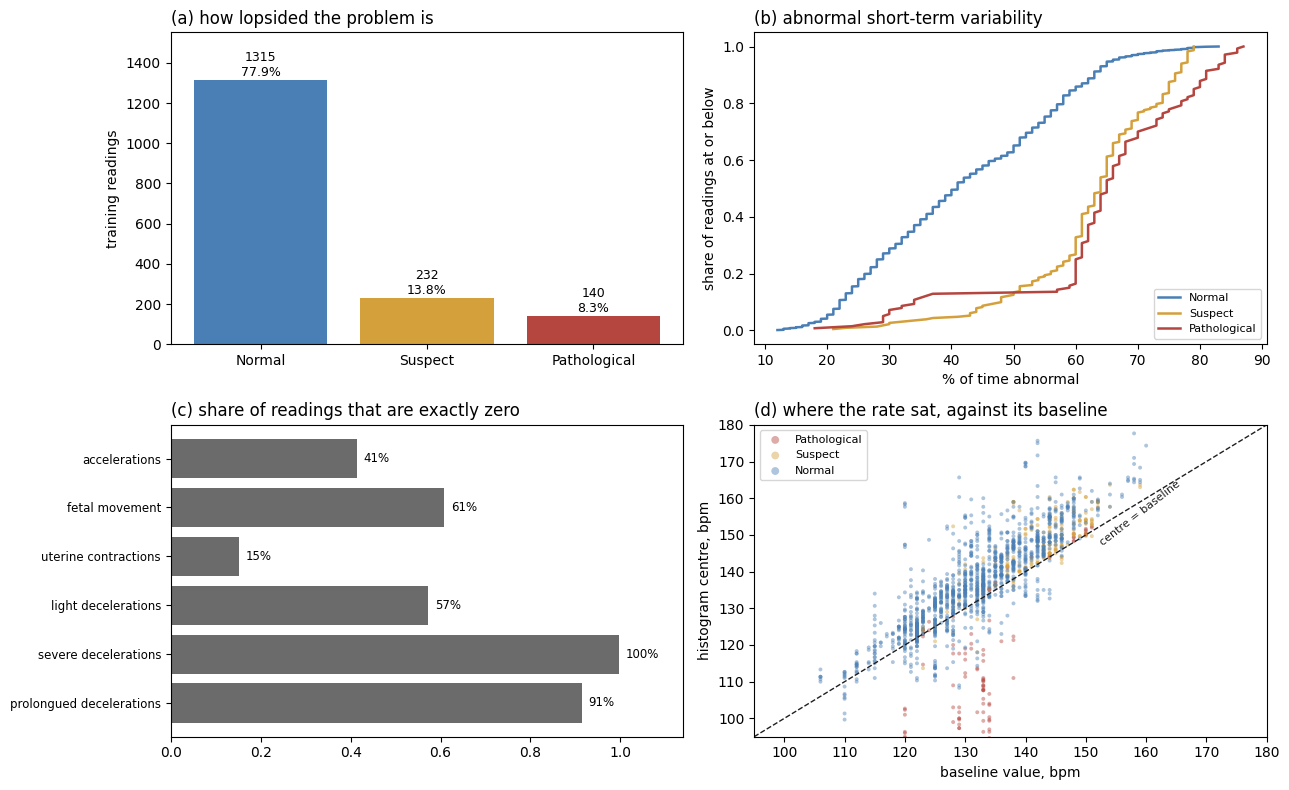

panel (b), the quartiles of abnormal short-term variability:

  Normal         lower quartile  29.0%   upper quartile  55.0%
  Suspect        lower quartile  59.0%   upper quartile  70.0%
  Pathological   lower quartile  60.8%   upper quartile  74.0%

panel (d), distance from the baseline to the histogram centre:

  Normal         median   +5.0 bpm    below the line on 14.4% of readings
  Suspect        median   +3.3 bpm    below the line on  7.3% of readings
  Pathological   median  -18.0 bpm    below the line on 65.7% of readings

class medians on the columns most likely to matter:

  column                                                     Normal  Suspect  Pathological
  baseline value                                            132.000  143.000       133.000
  accelerations                                               0.003    0.000         0.000
  abnormal_short_term_variability                            41.000   64.000        65.000
  mean_value_of_long_term_variability       

In [7]:
COLOURS = {0: "#4a7fb5", 1: "#d4a03c", 2: "#b5453f"}

# Training rows only. Looking at the held-out rows here would be the same error as
# scoring on them, one step earlier and harder to see.
tr = X_train.copy()
tr["label"] = y_train

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# ---- (a) how many of each class ------------------------------------------------
ax = axes[0, 0]
counts = tr["label"].value_counts().sort_index()
ax.bar([CLASS_NAMES[k] for k in counts.index], counts.values,
       color=[COLOURS[k] for k in counts.index])
for k, v in counts.items():
    ax.text(k, v + 20, f"{v}\n{v/len(tr):.1%}", ha="center", fontsize=9)
ax.set_ylim(0, max(counts) * 1.18)
ax.set_title("(a) how lopsided the problem is", loc="left")
ax.set_ylabel("training readings")

# ---- (b) short-term variability by class ---------------------------------------
# Cumulative curves rather than histograms: no bin width has to be chosen by hand, and
# reading across at any height compares the three classes at the same percentile.
ax = axes[0, 1]
COL_B = "abnormal_short_term_variability"
quartiles = {}
for k in (0, 1, 2):
    v = np.sort(tr.loc[tr["label"] == k, COL_B].values)
    ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=COLOURS[k], lw=1.8,
            label=CLASS_NAMES[k])
    quartiles[k] = (np.quantile(v, 0.25), np.quantile(v, 0.75))
ax.set_title("(b) abnormal short-term variability", loc="left")
ax.set_xlabel("% of time abnormal")
ax.set_ylabel("share of readings at or below")
ax.legend(fontsize=8, loc="lower right")

# ---- (c) how much of the event data is exactly zero -----------------------------
# This panel matters twice: these columns are mostly absence, and that is the reason
# SMOTE gets into difficulty in section 16.
ax = axes[1, 0]
EVENT_COLS = ["accelerations", "fetal_movement", "uterine_contractions",
              "light_decelerations", "severe_decelerations", "prolongued_decelerations"]
zero_share = [(tr[c] == 0).mean() for c in EVENT_COLS]
ax.barh(range(len(EVENT_COLS)), zero_share, color="#6b6b6b")
ax.set_yticks(range(len(EVENT_COLS)))
ax.set_yticklabels([c.replace("_", " ") for c in EVENT_COLS], fontsize=8.5)
ax.set_xlim(0, 1.14)
for i, v in enumerate(zero_share):
    ax.text(v + 0.015, i, f"{v:.0%}", va="center", fontsize=8.5)
ax.invert_yaxis()
ax.set_title("(c) share of readings that are exactly zero", loc="left")

# ---- (d) the baseline against where the rate actually sat -----------------------
ax = axes[1, 1]
centre = tr[["histogram_mean", "histogram_median", "histogram_mode"]].mean(axis=1)
for k in (2, 1, 0):                       # Normal drawn last so it does not hide the rest
    m = tr["label"] == k
    ax.scatter(tr.loc[m, "baseline value"], centre[m], s=8, alpha=0.45,
               color=COLOURS[k], label=CLASS_NAMES[k], edgecolors="none")
lims = [95, 180]
ax.plot(lims, lims, color="#1f1f1f", ls="--", lw=1.0)
ax.text(152, 147, "centre = baseline", fontsize=8, rotation=38, color="#1f1f1f")
ax.set_xlim(*lims); ax.set_ylim(*lims)
ax.set_xlabel("baseline value, bpm")
ax.set_ylabel("histogram centre, bpm")
ax.set_title("(d) where the rate sat, against its baseline", loc="left")
ax.legend(fontsize=8, loc="upper left", markerscale=2)

plt.tight_layout()
plt.show()

# ---- the numbers behind the panels, so nothing is claimed from an image alone ----
print("panel (b), the quartiles of abnormal short-term variability:\n")
for k in (0, 1, 2):
    lo, hi = quartiles[k]
    print(f"  {CLASS_NAMES[k]:14s} lower quartile {lo:5.1f}%   upper quartile {hi:5.1f}%")

print("\npanel (d), distance from the baseline to the histogram centre:\n")
gap_tr = centre - tr["baseline value"]
for k in (0, 1, 2):
    v = gap_tr[tr["label"] == k]
    print(f"  {CLASS_NAMES[k]:14s} median {v.median():+6.1f} bpm    "
          f"below the line on {(v < 0).mean():5.1%} of readings")

print("\nclass medians on the columns most likely to matter:\n")
print(f"  {'column':56s} {'Normal':>8s} {'Suspect':>8s} {'Pathological':>13s}")
for c in ["baseline value", "accelerations", "abnormal_short_term_variability",
          "mean_value_of_long_term_variability", "prolongued_decelerations",
          "histogram_variance"]:
    med = [tr.loc[tr["label"] == k, c].median() for k in (0, 1, 2)]
    print(f"  {c:56s} {med[0]:>8.3f} {med[1]:>8.3f} {med[2]:>13.3f}")


**Finding: panel (d) shows a quantity nobody measured.**

**Read the bottom right panel first.** Each point is one training recording, with the
baseline an obstetrician judged on the horizontal axis and where the heart rate actually
spent its twenty minutes on the vertical. The dashed line is where the two agree.

**Normal and Suspect readings mostly sit above that line and Pathological readings mostly
sit below it.** The medians are +5.0 bpm for Normal, +3.3 for Suspect and −18.0 for
Pathological, and 65.7% of Pathological readings fall below the line against 14.4% of
Normal ones. It is a tendency, not a rule: about a third of Pathological readings sit
above the line, and the separation is real without being clean.

That is the physiology of section 0 showing up as geometry. A baseline is drawn through
the settled part of the trace, so on a healthy recording the accelerations above and the
brief dips below roughly cancel and the centre lands near it. Repeated decelerations hold
the rate down for minutes at a time, and the time-weighted centre falls away from a
baseline drawn through the top. **Neither axis measures that distance. The file contains
both coordinates and not the gap between them**, and section 8 builds it.

**Panel (b) is the sharpest separation of Normal from Pathological in the file, and the
quartiles are printed
below it rather than left to the eye.** Normal readings run from 29.0% to 55.0% of the
time with abnormal short-term variability across the middle half of the class. Suspect
runs 59.0 to 70.0 and Pathological 60.8 to 74.0. **Normal's upper quartile sits below
Suspect's lower quartile**, so the middle halves of those two classes do not overlap at
all. Suspect and Pathological sit almost on top of each other on this column.

That last point is worth holding loosely. It says Suspect and Pathological are hard to tell
apart **on this one axis**, which is not the same as saying that is where the model's Suspect
errors will go. Section 20 counts where they actually go, and the answer is not the one this
panel suggests. Section 7 goes further and asks whether these three classes sit on one scale
at all, and finds that on most columns they do not.

**Panel (c) will matter again in section 16.** The event columns are mostly exact zeros,
severe decelerations almost entirely so. These columns are absence with occasional
presence rather than quantities that vary, and that shape is the reason SMOTE runs into
difficulty: interpolating halfway between two rows that are almost entirely zeros produces
a patient nobody recorded.

**Panel (a) is the one to hold in mind while reading every number after it.** The red bar
is 140 readings.

## 7. Where the three classes are not on one scale

**The question.** Section 6 read the columns as though Normal, Suspect and Pathological sat in order along each of them. Do they?

**What the code does.** Three checks on the training rows. Whether each column moves monotonically across the three classes, whether the Pathological class is one group or several, and whether one suspicious column is measuring the fetus or the histogram binning.

**What to look for.** How many of the 21 columns fail to move in order across the three classes, and one class that turns out to be two.

class means, and whether they move in order. A reversal smaller than 0.10 of
the within-class standard deviation is reported as flat rather than as a reversal.

  column                                                       Normal    Suspect       Path          order    size
  baseline value                                                131.8      141.2      131.9       REVERSES   1.08SD
  accelerations                                              0.004052  0.0002414  0.0004214           flat         
  fetal_movement                                             0.008629   0.006177    0.02961           flat         
  uterine_contractions                                       0.004815   0.002284   0.003864       REVERSES   0.53SD
  light_decelerations                                        0.001931  0.0005043     0.0034       REVERSES   0.52SD
  severe_decelerations                                      7.605e-07          0  4.286e-05           flat         
  prolongued_decelerations  

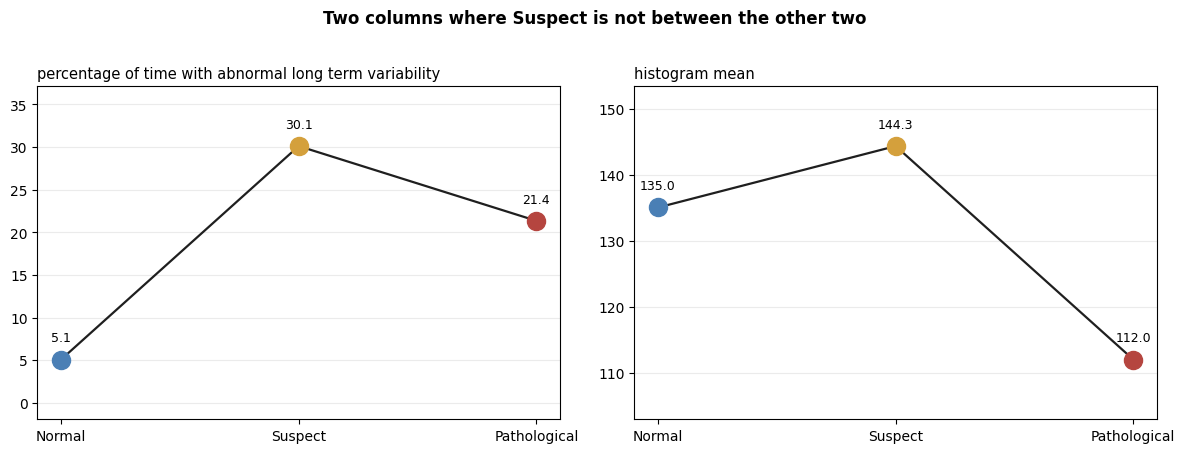


how cleanly the 140 training Pathological rows split:

  k=2   silhouette 0.421
  k=3   silhouette 0.369
  k=4   silhouette 0.355
  k=5   silhouette 0.320

  control: the same procedure on 20 random samples of 140 NORMAL rows
  gives 0.212 on average, range 0.190 to 0.238
  Pathological at k=2 scores 2.0 times the control.


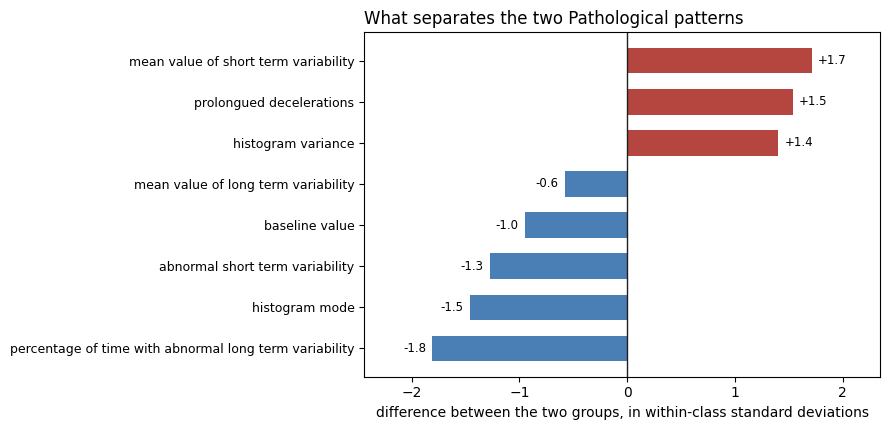


  pattern A,  90 rows: baseline 129 bpm, histogram variance 83, abnormal long-term variability 0%
  pattern B,  50 rows: baseline 137 bpm, histogram variance 0.5, abnormal long-term variability 60%

  what else distinguishes the two patterns, and whether the clustering used it:

  column                                          used?         A         B    Normal
  baseline value                                    yes    128.87    137.24    131.85
  histogram_min                                      no     60.29    121.94     91.25
  histogram_max                                      no    170.77    146.74    164.66
  histogram_number_of_peaks                          no      6.29      1.30      4.15
  mean_value_of_short_term_variability              yes      2.32      0.31      1.43
  mean_value_of_long_term_variability               yes      2.72      5.15      8.65
  accelerations (per hour)                           no      2.36      0.00     14.59
  fetal_movement (per hour)    

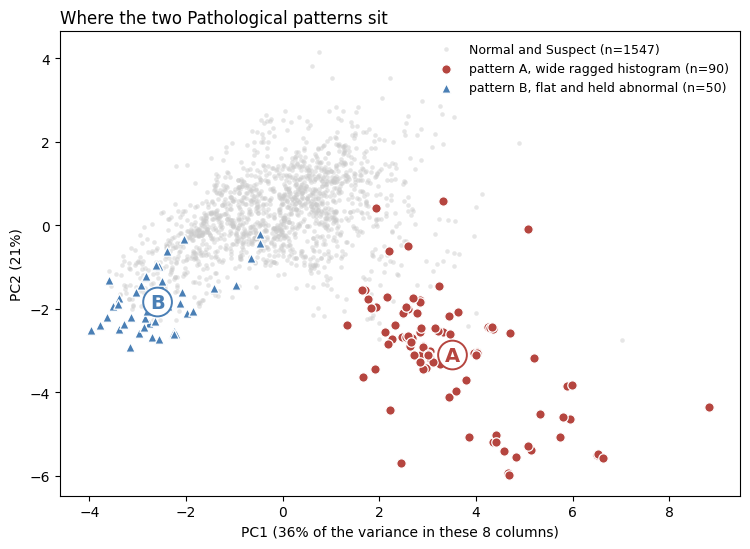


  PC1 and PC2 carry 35.8% and 21.4% of the variance in those 8 columns,
  57.2% together, so this is a shadow of an 8-dimensional space and two points
  that look close in it need not be. The clusters were found in the full 8 columns,
  not in this picture, so the separation visible here is a consequence rather
  than the evidence.

histogram_number_of_zeroes correlates with:
  the label            -0.011
  the histogram width  +0.323
  histogram_min        -0.316

  share of readings with any empty bin, by class:
    Normal          24.8%
    Suspect         17.7%
    Pathological    24.3%


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

tr = X_train.copy()
tr["label"] = y_train

# ---- (1) which columns actually move in order across the three classes -----------
# A column is monotonic if its class means go up, up or down, down. Anything else means
# Suspect is not simply "between" Normal and Pathological on that measurement, and a model
# has to learn a shape rather than a threshold.
# A reversal only counts if it is big enough to see. Suspect sitting 0.001 above
# Pathological on a column whose readings vary by 5 is a tie, not a pattern, so each
# reversal is measured against the spread WITHIN the classes and anything under a tenth of
# a standard deviation is called flat.
TOL = 0.10
print(f"class means, and whether they move in order. A reversal smaller than {TOL:.2f} of")
print(f"the within-class standard deviation is reported as flat rather than as a reversal.\n")
print(f"  {'column':56s} {'Normal':>10s} {'Suspect':>10s} {'Path':>10s} {'order':>14s} {'size':>7s}")
reversed_cols, flat_cols = [], []
for c in MEASURE_COLS:
    m = [tr.loc[tr["label"] == k, c].mean() for k in (0, 1, 2)]
    spread = tr.groupby("label")[c].std().mean()
    if m[0] < m[1] < m[2] or m[0] > m[1] > m[2]:
        tag, size = ("rising" if m[0] < m[2] else "falling"), 0.0
    else:
        # how far the middle class sits outside the range the other two span
        lo, hi = min(m[0], m[2]), max(m[0], m[2])
        size = max(lo - m[1], m[1] - hi, 0.0) / max(spread, 1e-9)
        if size < TOL:
            tag, flat_cols = "flat", flat_cols + [c]
        else:
            tag, reversed_cols = "REVERSES", reversed_cols + [c]
    print(f"  {c:56s} {m[0]:>10.4g} {m[1]:>10.4g} {m[2]:>10.4g} {tag:>14s} "
          + (f"{size:>6.2f}SD" if tag == "REVERSES" else " " * 8))
print(f"\n  {len(reversed_cols)} of {len(MEASURE_COLS)} columns reverse direction by more "
      f"than {TOL:.2f} SD:")
for c in reversed_cols:
    print(f"     {c}")
print(f"  {len(flat_cols)} more are out of order by less than that, which is a tie rather "
      f"than a pattern.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, c in zip(axes, ["percentage_of_time_with_abnormal_long_term_variability",
                        "histogram_mean"]):
    m = [tr.loc[tr["label"] == k, c].mean() for k in (0, 1, 2)]
    ax.plot([0, 1, 2], m, "o-", color="#1f1f1f", lw=1.6, ms=8, zorder=3)
    for k in (0, 1, 2):
        ax.plot(k, m[k], "o", ms=13, color=COLOURS[k], zorder=4)
        ax.annotate(f"{m[k]:.1f}", (k, m[k]), textcoords="offset points",
                    xytext=(0, 13), ha="center", fontsize=9)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels([CLASS_NAMES[k] for k in (0, 1, 2)])
    ax.set_title(c.replace("_", " "), loc="left", fontsize=10.5)
    ax.margins(y=0.28)
    ax.grid(axis="y", alpha=0.25)
fig.suptitle("Two columns where Suspect is not between the other two", y=1.02,
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- (2) is Pathological one group or two? --------------------------------------
# Clustering finds groups in anything, so the number alone proves nothing. The control is
# the same procedure on a same-sized random sample of Normal rows: if Pathological does not
# cluster better than an arbitrary group of that size, there is no structure to report.
CLUSTER_FEATS = ["abnormal_short_term_variability", "mean_value_of_short_term_variability",
                 "percentage_of_time_with_abnormal_long_term_variability",
                 "mean_value_of_long_term_variability", "histogram_mode", "baseline value",
                 "prolongued_decelerations", "histogram_variance"]
# the same list in the section 14 spelling, for the architectures in section 17
CLUSTER_FEATS_FEAT = [c if c != "histogram_mode" else "histogram_center_avg"
                      for c in CLUSTER_FEATS]

path_rows = X_train.loc[y_train == PATHOLOGICAL]
Xp = StandardScaler().fit_transform(path_rows[CLUSTER_FEATS])
fits = {k: KMeans(k, n_init=20, random_state=SEED).fit(Xp) for k in (2, 3, 4, 5)}
sil = {k: silhouette_score(Xp, m.labels_) for k, m in fits.items()}

normal_pool = X_train.loc[y_train == 0]
null = []
for seed in range(20):
    samp = normal_pool.sample(n=len(path_rows), random_state=seed)
    Xn = StandardScaler().fit_transform(samp[CLUSTER_FEATS])
    # the SAME settings as above, so the control is not handicapped by fewer restarts
    null.append(silhouette_score(Xn, KMeans(2, n_init=20, random_state=SEED).fit_predict(Xn)))

print(f"\nhow cleanly the {len(path_rows)} training Pathological rows split:\n")
for k, v in sil.items():
    print(f"  k={k}   silhouette {v:.3f}")
print(f"\n  control: the same procedure on {len(null)} random samples of {len(path_rows)} "
      f"NORMAL rows")
print(f"  gives {np.mean(null):.3f} on average, range {min(null):.3f} to {max(null):.3f}")
print(f"  Pathological at k=2 scores {sil[2]/np.mean(null):.1f} times the control.")

# the profile of the two groups, in units of the spread WITHIN the Pathological class
km = fits[2]
Z = pd.DataFrame(Xp, columns=CLUSTER_FEATS, index=path_rows.index)
Z["g"] = km.labels_
diff = (Z.groupby("g")[CLUSTER_FEATS].mean().loc[1]
        - Z.groupby("g")[CLUSTER_FEATS].mean().loc[0]).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(range(len(diff)), diff.values,
        color=["#4a7fb5" if v < 0 else "#b5453f" for v in diff.values], height=0.62)
ax.set_yticks(range(len(diff)))
ax.set_yticklabels([c.replace("_", " ") for c in diff.index], fontsize=9)
for i, v in enumerate(diff.values):
    ax.text(v + (0.06 if v >= 0 else -0.06), i, f"{v:+.1f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5)
ax.axvline(0, color="#1f1f1f", lw=1)
ax.margins(x=0.18)
ax.set_xlabel("difference between the two groups, in within-class standard deviations")
ax.set_title("What separates the two Pathological patterns", loc="left")
plt.tight_layout()
plt.show()

raw_prof = path_rows.groupby(km.labels_)[
    ["baseline value", "histogram_variance",
     "percentage_of_time_with_abnormal_long_term_variability"]].mean()
wide = int(raw_prof["histogram_variance"].idxmax())
SUBTYPE = pd.Series(np.where(km.labels_ == wide, "A", "B"), index=path_rows.index)
print(f"\n  pattern A, {int((SUBTYPE=='A').sum()):3d} rows: baseline "
      f"{raw_prof.loc[wide, 'baseline value']:.0f} bpm, histogram variance "
      f"{raw_prof.loc[wide, 'histogram_variance']:.0f}, abnormal long-term variability "
      f"{raw_prof.loc[wide, 'percentage_of_time_with_abnormal_long_term_variability']:.0f}%")
print(f"  pattern B, {int((SUBTYPE=='B').sum()):3d} rows: baseline "
      f"{raw_prof.loc[1-wide, 'baseline value']:.0f} bpm, histogram variance "
      f"{raw_prof.loc[1-wide, 'histogram_variance']:.1f}, abnormal long-term variability "
      f"{raw_prof.loc[1-wide, 'percentage_of_time_with_abnormal_long_term_variability']:.0f}%")

# ---- what else separates them, including columns the clustering never saw --------
# The eight columns above are what k-means was handed. A column used to FIND a split cannot
# also be evidence that the split means something, so the table below is marked: the ones
# the clustering saw, and the ones it did not. The second group is the corroboration.
_isA = (SUBTYPE == "A").values
_seen = set(CLUSTER_FEATS)
_extra = ["baseline value", "histogram_min", "histogram_max", "histogram_number_of_peaks",
          "mean_value_of_short_term_variability", "mean_value_of_long_term_variability",
          "accelerations", "fetal_movement", "light_decelerations",
          "prolongued_decelerations"]
print("\n  what else distinguishes the two patterns, and whether the clustering used it:\n")
print(f"  {'column':46s} {'used?':>6s} {'A':>9s} {'B':>9s} {'Normal':>9s}")
for _c in _extra:
    _mk = "yes" if _c in _seen else "no"
    _vals = [path_rows.loc[_isA, _c].mean(), path_rows.loc[~_isA, _c].mean(),
             X_train.loc[y_train == 0, _c].mean()]
    # the event columns are counts per SECOND, so two decimals rounds them all to 0.00.
    # Shown per hour instead, which is both readable and the rate a midwife would think in.
    if max(abs(v) for v in _vals) < 1:
        _vals, _c_lbl = [v * 3600 for v in _vals], _c + " (per hour)"
    else:
        _c_lbl = _c
    print(f"  {_c_lbl:46s} {_mk:>6s} {_vals[0]:>9.2f} {_vals[1]:>9.2f} {_vals[2]:>9.2f}")

_norm = X_train.loc[y_train == 0]
print(f"\n  {'share with ANY prolonged deceleration':46s} {'yes':>6s} "
      f"{(path_rows.loc[_isA, 'prolongued_decelerations'] > 0).mean():>8.1%} "
      f"{(path_rows.loc[~_isA, 'prolongued_decelerations'] > 0).mean():>9.1%} "
      f"{(_norm['prolongued_decelerations'] > 0).mean():>9.1%}")
print(f"  {'share with NO accelerations at all':46s} {'no':>6s} "
      f"{(path_rows.loc[_isA, 'accelerations'] == 0).mean():>8.1%} "
      f"{(path_rows.loc[~_isA, 'accelerations'] == 0).mean():>9.1%} "
      f"{(_norm['accelerations'] == 0).mean():>9.1%}")

# One number in that table does not fit the rest and is flagged rather than smoothed over.
print(f"\n  Note the long-term variability pair, which point opposite ways. Pattern A's MEAN")
print(f"  long-term variability is the lower of the two, yet pattern A is flagged abnormal")
print(f"  0% of the recording and pattern B 60%. The likely reading is that the percentage")
print(f"  measure needs abnormality SUSTAINED over some minimum stretch, so A's low mean is")
print(f"  a few deep deceleration minutes dragging an average without any stretch");
print(f"  qualifying, while B is uniformly flat. That is inference about how SisPorto")
print(f"  computes the column, not something this file states.")

# ---- the same two groups, as a picture -------------------------------------------
# The numbers above say the two patterns differ. This says where they sit relative to
# everything else, which the numbers cannot.
#
# The projection is fitted on ALL the training rows rather than on the Pathological ones.
# Fitting it on the rows whose structure is in question would pick the axes that flatter
# that structure; this way the two patterns are drawn in the space the whole dataset
# occupies, and the Normal and Suspect rows can be left in as context.
_scale_all = StandardScaler().fit(X_train[CLUSTER_FEATS])
_pca2 = PCA(n_components=2, random_state=SEED)
_xy = _pca2.fit_transform(_scale_all.transform(X_train[CLUSTER_FEATS]))
_ev = _pca2.explained_variance_ratio_ * 100
_is_path = y_train == PATHOLOGICAL          # y_train is an ndarray here
_xy_path = _xy[_is_path]                      # same row order as path_rows
_a, _b = (SUBTYPE == "A").values, (SUBTYPE == "B").values

fig, ax = plt.subplots(figsize=(7.6, 5.6))
ax.scatter(_xy[~_is_path, 0], _xy[~_is_path, 1], s=11, c="#c9c9c9", alpha=0.45,
           linewidths=0, label=f"Normal and Suspect (n={(~_is_path).sum()})")
ax.scatter(_xy_path[_a, 0], _xy_path[_a, 1], s=46, c="#b5453f", edgecolors="white",
           linewidths=0.9, label=f"pattern A, wide ragged histogram (n={_a.sum()})")
ax.scatter(_xy_path[_b, 0], _xy_path[_b, 1], s=46, c="#4a7fb5", marker="^",
           edgecolors="white", linewidths=0.9,
           label=f"pattern B, flat and held abnormal (n={_b.sum()})")
for _m, _c, _t in ((_a, "#b5453f", "A"), (_b, "#4a7fb5", "B")):
    ax.annotate(_t, (_xy_path[_m, 0].mean(), _xy_path[_m, 1].mean()), fontsize=14,
                fontweight="bold", color=_c, ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.25", fc="white", ec=_c, lw=1.4))
ax.set_xlabel(f"PC1 ({_ev[0]:.0f}% of the variance in these {len(CLUSTER_FEATS)} columns)")
ax.set_ylabel(f"PC2 ({_ev[1]:.0f}%)")
ax.set_title("Where the two Pathological patterns sit", loc="left")
ax.legend(frameon=False, fontsize=9, loc="best")
plt.tight_layout()
plt.show()

print(f"\n  PC1 and PC2 carry {_ev[0]:.1f}% and {_ev[1]:.1f}% of the variance in those "
      f"{len(CLUSTER_FEATS)} columns,")
print(f"  {_ev.sum():.1f}% together, so this is a shadow of an {len(CLUSTER_FEATS)}-"
      f"dimensional space and two points")
print(f"  that look close in it need not be. The clusters were found in the full "
      f"{len(CLUSTER_FEATS)} columns,")
print(f"  not in this picture, so the separation visible here is a consequence rather")
print(f"  than the evidence.")

# ---- (3) is histogram_number_of_zeroes measuring the fetus or the binning? --------
# A real severity marker should track the label. A binning side effect should track the
# histogram's shape instead, because a wider histogram has more sparsely filled bins.
z = tr["histogram_number_of_zeroes"]
width = tr["histogram_max"] - tr["histogram_min"]
print(f"\nhistogram_number_of_zeroes correlates with:")
print(f"  the label            {np.corrcoef(z, y_train)[0,1]:+.3f}")
print(f"  the histogram width  {np.corrcoef(z, width)[0,1]:+.3f}")
print(f"  histogram_min        {np.corrcoef(z, tr['histogram_min'])[0,1]:+.3f}")
print(f"\n  share of readings with any empty bin, by class:")
for k in (0, 1, 2):
    print(f"    {CLASS_NAMES[k]:14s} {(tr.loc[tr['label']==k, 'histogram_number_of_zeroes']>0).mean():6.1%}")


**Finding: thirteen of the twenty-one columns reverse direction, and the Pathological class is two classes.**

**Start with the reversals, because they change how every column should be read.** Thirteen
of the 21 do not move in order across Normal, Suspect and Pathological by a margin worth
calling a margin. Five more are out of order by less than a tenth of a standard deviation,
which is a tie rather than a pattern, and only three are genuinely monotonic:
`prolongued_decelerations` and `abnormal_short_term_variability` rising, and
`mean_value_of_long_term_variability` falling.

**`baseline value` is the sharpest case and the most useful one to understand.** Normal
averages 131.8 bpm, Pathological 131.9, and Suspect sits 1.08 standard deviations above
both at 141.2. As a way of telling Normal from Pathological the column is worthless, and
section 8's table confirms it at a separation of 0.502, a coin flip. As a way of spotting
Suspect it is one of the better columns in the file. **A single number for how good a
column is would have hidden that completely**, which is why section 8 scores all three
pairings separately.

**Then the bigger finding: the Pathological class is not one thing.** Clustering the 140
training Pathological rows on their variability and histogram-shape columns splits them
cleanly in two, at a silhouette of 0.421.

Clustering finds groups in anything, so that number alone proves nothing. **The control is
the same procedure run on twenty random samples of 140 Normal rows**, which score 0.212 on
average across a range of 0.190 to 0.238. Pathological clusters twice as cleanly as an
arbitrary group of the same size, and the gap is far outside the control's whole range.

The two patterns are recognisable rather than statistical:

| | n | baseline | histogram variance | abnormal long-term variability |
|---|---|---|---|---|
| **A: wide ragged histogram, no sustained LTV abnormality** | 90 | 129 bpm | 83 | 0% |
| **B: flat histogram, held abnormal** | 50 | 137 bpm | 0.5 | 60% |

**They are abnormal in opposite directions on the same column.** Pattern A's histogram is
wide and ragged at a variance of 83, pattern B's has collapsed almost flat at 0.5, and the
class average of 53.7 sits between two groups that have nothing in common on that axis. The
separating column is the histogram, not the baseline: 129 bpm and 137 bpm both sit inside
FIGO's 110 to 160 band and both are within a few bpm of the Normal mean of 131.8, so neither
pattern is defined by its baseline and neither should be described as dragged out of range.
What does separate them besides the histogram is long-term variability, flagged abnormal for
60% of the recording in pattern B and 0% in pattern A. Pattern B is the reduced-variability
picture section 0 described. Pattern A is the ragged one.

**The two patterns have a clinical reading, and it is not a coincidence that there are two
of them.** FIGO's 2015 criteria make a trace pathological if it meets **any** of a short
list: a baseline abnormality, a variability abnormality, or repetitive late or prolonged
decelerations. That is a disjunction. A class defined by an OR is a union of the things it
lists, so a class defined this way should split, and what the clustering found is the
structure of the diagnostic rule rather than a hidden biology.

**Pattern A is intermittent stress with the fetal response intact.** 87.8% of these
readings carry a prolonged deceleration, against 4.3% of Normal. The histogram runs 60 to
171 bpm across 6.3 peaks, which is what repeated plunges to 60 and returns to 130 look like
once time is discarded: one lump at the baseline and another at the nadir. Short-term
variability averages 2.32, **above** Normal's 1.43, and fetal movement is about five times
the Normal rate. That combination, deep decelerations with variability preserved or raised,
is the picture of a fetus responding to an acute intermittent load such as cord or head
compression. The control loop is working.

**Pattern B is the silent trace.** No prolonged decelerations at all, no light
decelerations, and **every one of the 50 has zero accelerations**. The histogram spans 122
to 147 bpm across 1.3 peaks, a single spike. Short-term variability averages 0.31, the
lowest figure anywhere in this table. This is loss of beat-to-beat modulation, and the
baseline sitting at 137 against pattern A's 129 fits it: a rate held up while the
modulation around it disappears.

**Pattern B's differential is the part that matters clinically, and these columns cannot
settle it.** A flat non-reactive trace is produced by progressive hypoxia, by quiet fetal
sleep, by maternal drugs that depress the fetal central nervous system, and by neurological
abnormality or prematurity. Quiet sleep runs in cycles of tens of minutes, which is exactly
why a non-reactive trace is normally extended or the fetus stimulated before anyone commits
to a reading. Nothing in the 21 columns distinguishes those causes, and the recording length
is not in the file either.

**How much of this is circular, stated plainly.** `prolongued_decelerations` and
`histogram_variance` were both given to the clustering, so finding the groups differ on them
is close to a tautology. `histogram_min`, `histogram_max`, `histogram_number_of_peaks`,
`accelerations` and `fetal_movement` were **not**, and those are the columns carrying the
60-versus-122 bpm floor, the 6.3-versus-1.3 peaks and the total absence of accelerations in
pattern B. The clinical reading rests on the second group.

**One number refuses to fit and is left visible rather than smoothed over.** Pattern A's
mean long-term variability is the lower of the two at 2.72 against 5.15, yet pattern A is
flagged abnormal 0% of the recording and pattern B 60%. The printed note under the table
offers a reading, that the percentage measure requires abnormality sustained over some
minimum stretch, but that is inference about SisPorto's internals rather than anything this
file establishes.

**And the standing limit still applies here.** Prolonged decelerations are defined by
duration rather than by timing, so pattern A's signature survives the missing-timing problem
that section 8 names as this project's ceiling. The light decelerations do not: early and
late ones mean opposite things and these columns cannot tell them apart.

**This is why so many columns reverse.** Suspect is a genuine middle on some of them, and on
others the Pathological class is pulling in two directions at once and its mean lands
wherever the two groups happen to balance.

**Third, one column is measuring the instrument rather than the fetus.**
`histogram_number_of_zeroes` correlates with the label at −0.011, which is nothing, and with
the histogram's width at +0.323. A wider histogram has more sparsely filled bins, and that
is all this column is recording. The share of readings with any empty bin is 24.8% for
Normal, 17.7% for Suspect and 24.3% for Pathological, which is not a severity trend in any
direction. Section 15 tests whether the model can be talked out of using it anyway.

**All of this is measured on the training rows only.** Clustering the full file and then
reporting the structure would mean the held-out readings had shaped the analysis, which is the
error section 5 exists to prevent. Section 20 comes back to the two patterns and asks whether
the model catches both, with a control for how much of that answer is the clustering choosing
its own best case.

## 8. Ten candidate features, written down before any model exists

**The question.** Two sources have now suggested quantities the file does not contain: FIGO's criteria from section 0, and the structure sections 6 and 7 found in the data itself. Which can actually be built, and which are gone for good?

**What the code does.** Builds ten candidates, four from the guideline and six from the exploration, and scores every column in the file plus every candidate on the same footing. No candidate is dropped on these numbers: all ten are committed to now and tested in section 15.

**What to look for.** Ten constructions, a longer list of things that cannot be constructed at all, and one distinction between two kinds of feature that changes how they have to be tested.

In [9]:
# A candidate is a pair: a fit step and a transform step.
#
#   fit(X_fit, y_fit) -> params      what the feature needs to learn from data, or None
#   transform(frame, params) -> values
#
# That split is the point of this section. C1 to C4 are pure functions of a row: the same
# arithmetic on any patient, nothing learned. C5 to C8 need a reference point taken from
# the data, such as where Normal readings usually sit. A feature with a fitted reference
# CANNOT be built once on the training set and reused, because the reference would have
# seen the rows it is later used to score. Section 15 fits those inside each fold.

def centre_of(frame):
    # Where the heart rate spent the recording. Section 14 replaces the three centre
    # statistics with their average, so this handles a frame from either side of it.
    if "histogram_center_avg" in frame:
        return frame["histogram_center_avg"]
    return frame[["histogram_mean", "histogram_median", "histogram_mode"]].mean(axis=1)


def severe_present(frame):
    if "severe_decelerations_present" in frame:
        return frame["severe_decelerations_present"] > 0
    return frame["severe_decelerations"] > 0


NO_FIT = lambda X_fit, y_fit: None        # for candidates that learn nothing

# ============================== from FIGO's criteria, section 0 ====================

# C1: repeated decelerations hold the rate below the baseline, so the time-weighted centre
# drifts below a baseline drawn through the settled part of the trace. The file has both
# quantities and not their difference. Negative is the worrying end.
C1 = (NO_FIT, lambda f, p: centre_of(f) - f["baseline value"])

# C2: FIGO's normal baseline is 110 to 160 bpm, abnormal in both directions. Given the raw
# baseline a model must learn two cut points and that the middle is safe; given the
# distance outside the band, the safe region is already a single value of zero.
C2 = (NO_FIT, lambda f, p: np.maximum(0, 110 - f["baseline value"])
      + np.maximum(0, f["baseline value"] - 160))

# C3: FIGO calls decelerations repetitive when they accompany more than half the
# contractions. The file counts both per second and never relates them. No contractions
# means no repetitiveness, so the ratio is zero there rather than undefined.
C3 = (NO_FIT, lambda f, p: np.where(
    f["uterine_contractions"] > 0,
    (f["light_decelerations"] + f["prolongued_decelerations"])
    / f["uterine_contractions"].replace(0, np.nan), 0.0))

# C4: FIGO treats absent accelerations as unremarkable alone and significant alongside
# reduced variability. That is an AND, which costs a tree two levels of depth to express.
C4 = (NO_FIT, lambda f, p: ((f["accelerations"] == 0)
                            & (f["mean_value_of_long_term_variability"] < 5.0)).astype(int))

# ============================== from the exploration, sections 6 and 7 =============

def two_sided_departure(col_getter, lo_q=0.10, hi_q=0.90):
    """How far outside the middle of NORMAL a row sits, in either direction.

    Section 7 found columns where Suspect is not between Normal and Pathological, and a
    Pathological class that splits into a high-variance and a near-zero-variance group. On
    such a column both tails are abnormal and the middle is safe. A tree can learn that,
    but it spends a split per side and has to find both with 140 cases. One unsigned
    distance makes a single feature out of two tails.

    This is the same SHAPE as C2, with one difference that matters: C2's band comes from a
    published guideline and this one comes from the data, which is why it has a fit step.
    """
    def fit(X_fit, y_fit):
        normal = col_getter(X_fit)[y_fit == 0]
        return float(normal.quantile(lo_q)), float(normal.quantile(hi_q))

    def transform(frame, params):
        lo, hi = params
        v = col_getter(frame)
        # Both tails divided by the SAME width, the span of Normal's middle, so one unit
        # below lo counts exactly as much as one unit above hi. Scaling each tail by its
        # own endpoint would make the feature's two halves incomparable, which is not what
        # "distance outside the middle" means.
        return (np.maximum(0.0, lo - v) + np.maximum(0.0, v - hi)) / max(hi - lo, 1e-9)
    return fit, transform


def standardised_gap(col_a, col_b):
    """One column minus another, each put on its own scale first.

    Two columns measured in different units cannot be subtracted directly, so each is
    centred and scaled using the training rows before the subtraction. That scaling is a
    fitted parameter, which is why this pair has a fit step.
    """
    def fit(X_fit, y_fit):
        return (X_fit[col_a].mean(), X_fit[col_a].std(),
                X_fit[col_b].mean(), X_fit[col_b].std())

    def transform(frame, p):
        ma, sa, mb, sb = p
        return ((frame[col_a] - ma) / max(sa, 1e-9)
                - (frame[col_b] - mb) / max(sb, 1e-9))
    return fit, transform


STV = "abnormal_short_term_variability"
LTV = "percentage_of_time_with_abnormal_long_term_variability"

# C5: section 7 showed histogram variance is the column the two Pathological patterns sit
# at opposite ends of, one wide and ragged, one collapsed flat.
C5 = two_sided_departure(lambda f: f["histogram_variance"])

# C6: section 7 showed the histogram centre rises from Normal to Suspect and then falls
# below both for Pathological, so distance from the Normal middle beats the raw value.
C6 = two_sided_departure(centre_of)

# C7: short-term variability abnormality rises across all three classes; long-term does
# not, with Suspect averaging higher than Pathological. The two disagree in a
# class-specific way, which is a quantity neither carries alone. Aimed at the Suspect
# against Pathological boundary, the weakest one in this notebook.
C7 = standardised_gap(STV, LTV)

# C8: the axis separating the two Pathological patterns, stated directly. Positive is the
# wide ragged histogram with little long-term abnormality, negative the flat histogram
# held abnormal for most of the recording. Written by hand from section 7's profile rather
# than by refitting the clustering, because clustering the Pathological rows and feeding
# the result back is a supervised step that would need its own nested validation.
C8 = standardised_gap("histogram_variance", LTV)

# C9: section 7 found histogram_number_of_zeroes correlates with the label at about -0.01
# and with the histogram width at about +0.32: a wider histogram simply has more sparsely
# filled bins. Dividing by the width removes the mechanism and leaves whatever is left.
C9 = (NO_FIT, lambda f, p: f["histogram_number_of_zeroes"]
      / (f["histogram_max"] - f["histogram_min"]).replace(0, np.nan).fillna(1))

# C10: section 6 panel (c) showed the deceleration columns are mostly exact zeros, so they
# carry presence rather than magnitude. Counting how many KINDS a recording shows turns
# three near-empty rate columns into one small integer.
C10 = (NO_FIT, lambda f, p: ((f["light_decelerations"] > 0).astype(int)
                             + (f["prolongued_decelerations"] > 0).astype(int)
                             + severe_present(f).astype(int)))

CANDIDATES = {
    "centre_minus_baseline": C1, "baseline_outside_figo": C2,
    "decels_per_contraction": C3, "absent_accels_low_var": C4,
    "departure_variance": C5, "departure_centre": C6,
    "variability_disagreement": C7, "subtype_axis": C8,
    "zeroes_per_width": C9, "decel_kinds_present": C10,
}
SOURCE = {n: ("FIGO" if n in ("centre_minus_baseline", "baseline_outside_figo",
                              "decels_per_contraction", "absent_accels_low_var")
              else "exploration") for n in CANDIDATES}
FITTED = [n for n, (fit, _) in CANDIDATES.items() if fit is not NO_FIT]

# Committed to NOW. If C1 fails the accuracy rule it is still kept, because one named
# column a midwife can read beats the same quantity hidden inside an interaction between
# two others. That reason is recorded here rather than invented in section 15.
KEEP_REGARDLESS = ["centre_minus_baseline"]

print(f"{len(CANDIDATES)} candidates committed to, "
      f"{sum(v == 'FIGO' for v in SOURCE.values())} from FIGO and "
      f"{sum(v == 'exploration' for v in SOURCE.values())} from the exploration.")
print(f"{len(FITTED)} of them learn a reference point from the data and must therefore be")
print(f"fitted inside each cross-validation fold: {', '.join(FITTED)}\n")
print(f"COMMITTED TO NOW, before any of them is tested:")
print(f"  {KEEP_REGARDLESS[0]} is kept even if it fails the accuracy rule,")
print(f"  because one named column a midwife can read beats the same quantity hidden inside")
print(f"  an interaction between two others. That is an interpretability reason and not an")
print(f"  accuracy claim, and it is written here so that section 15 cannot invent it after")
print(f"  seeing the result. No other candidate has such a reason: the remaining nine stand")
print(f"  or fall on the rule alone.\n")

# ---- how well each column separates each pair of classes, on its own --------------
# Every column in the file AND every candidate, scored the same way on the training rows,
# so the comparison is complete rather than a hand-picked shortlist. Parameters are fitted
# on all the training rows here, which is description only: nothing below decides which
# candidates go forward, and section 15 refits them inside the fold.
def separation(values, a, b):
    """Area under the ROC curve for one pair of classes, folded so 0.5 is no separation.

    A column that predicts perfectly in reverse separates as well as one predicting
    forwards, so direction is taken out. Nothing can score below 0.500 on this measure.
    """
    m = np.isin(y_train, [a, b])
    auc = roc_auc_score((y_train[m] == b).astype(int),
                        np.asarray(values, dtype=float)[m])
    return max(auc, 1 - auc)


rows = []
for c in MEASURE_COLS:
    rows.append({"column": c, "source": "in the file",
                 "N vs P": separation(X_train[c], 0, PATHOLOGICAL),
                 "S vs P": separation(X_train[c], 1, PATHOLOGICAL),
                 "N vs S": separation(X_train[c], 0, 1)})
for name, (fit_fn, tr_fn) in CANDIDATES.items():
    v = np.asarray(tr_fn(X_train, fit_fn(X_train, y_train)), dtype=float)
    rows.append({"column": "** " + name, "source": SOURCE[name],
                 "N vs P": separation(v, 0, PATHOLOGICAL),
                 "S vs P": separation(v, 1, PATHOLOGICAL),
                 "N vs S": separation(v, 0, 1)})

SEP = pd.DataFrame(rows).sort_values("N vs P", ascending=False)
print("separation between each pair of classes, all columns and all candidates")
print("(candidates marked **, N = Normal, S = Suspect, P = Pathological)\n")
print(SEP.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print("\nbest on each pairing:")
for pair in ("N vs P", "S vs P", "N vs S"):
    top = SEP.sort_values(pair, ascending=False).iloc[0]
    print(f"  {pair}   {top['column']:28s} {top[pair]:.3f}")

# ---- two checks that explain a flat result before it is blamed on the construction ----
b = X_train["baseline value"]
outside = (b < 110) | (b > 160)
print(f"\nC2 encodes FIGO's 110 to 160 band. Training readings outside it: "
      f"{int(outside.sum())} of {len(X_train)}, "
      f"all labelled { {CLASS_NAMES[k] for k in np.unique(y_train[outside.values])} }.")
print(f"C3 divides by the contraction rate. Training rows with no contractions at all: "
      f"{int((X_train['uterine_contractions'] == 0).sum())}.")

n_cols = len(MEASURE_COLS)
print(f"\nFor scale: {n_cols} columns admit {n_cols*(n_cols-1)//2} pairwise differences "
      f"and {n_cols*(n_cols-1)} ratios, since a over b is not b over a.\nThe best of those "
      f"by separation would look impressive here whether or not it meant anything, which "
      f"is\nwhy these ten were fixed before any model was fitted.")


10 candidates committed to, 4 from FIGO and 6 from the exploration.
4 of them learn a reference point from the data and must therefore be
fitted inside each cross-validation fold: departure_variance, departure_centre, variability_disagreement, subtype_axis

COMMITTED TO NOW, before any of them is tested:
  centre_minus_baseline is kept even if it fails the accuracy rule,
  because one named column a midwife can read beats the same quantity hidden inside
  an interaction between two others. That is an interpretability reason and not an
  accuracy claim, and it is written here so that section 15 cannot invent it after
  seeing the result. No other candidate has such a reason: the remaining nine stand
  or fall on the rule alone.



separation between each pair of classes, all columns and all candidates
(candidates marked **, N = Normal, S = Suspect, P = Pathological)

                                                column      source  N vs P  S vs P  N vs S
                              ** centre_minus_baseline        FIGO   0.919   0.915   0.550
                       abnormal_short_term_variability in the file   0.852   0.565   0.853
                                         accelerations in the file   0.803   0.525   0.822
                                      histogram_median in the file   0.795   0.888   0.707
                                 ** departure_variance exploration   0.789   0.744   0.585
                   mean_value_of_long_term_variability in the file   0.788   0.815   0.520
                                        histogram_mean in the file   0.786   0.882   0.721
                                        histogram_mode in the file   0.778   0.883   0.695
                              prolongued_d

**Finding: ten constructions, and the most important reading of all cannot be built.**

Two sources, and they behave differently. FIGO gives four. The exploration in sections 6 and
7 gives six.

| candidate | source | what it encodes |
|---|---|---|
| **C1** `centre_minus_baseline` | FIGO | decelerations dragging the time-weighted centre below the baseline |
| **C2** `baseline_outside_figo` | FIGO | distance outside the 110 to 160 band |
| **C3** `decels_per_contraction` | FIGO | repetitiveness, decelerations against contractions |
| **C4** `absent_accels_low_var` | FIGO | absent accelerations together with reduced variability |
| **C5** `departure_variance` | exploration | distance outside Normal's middle on histogram variance, either tail |
| **C6** `departure_centre` | exploration | the same, for the histogram centre |
| **C7** `variability_disagreement` | exploration | short-term abnormality minus long-term, each standardised |
| **C8** `subtype_axis` | exploration | the axis separating the two Pathological patterns |
| **C9** `zeroes_per_width` | exploration | empty histogram bins, divided by the thing that creates them |
| **C10** `decel_kinds_present` | exploration | how many kinds of deceleration appear at all |

**And the short list of what cannot be built matters more than the long one that can:**

| FIGO criterion | can it be built? |
|---|---|
| **late against early decelerations** | **no, needs the timing the file discards** |
| deceleration depth and recovery shape | no, needs the trace |
| sinusoidal pattern | no, needs the trace |

**That first row is the ceiling on this whole project.** Section 0 described a dip arriving
after a contraction peaks. Move it half a minute earlier and it is harmless. The 21 columns
record that a deceleration happened and never when, so the distinction a midwife leans on
hardest is not available at any amount of feature engineering.

**Four of the ten learn something from the data, and that changes how they must be tested.**
C1 to C4 are pure arithmetic on a row: the same calculation for any patient, nothing fitted.
C5 to C8 need a reference point, either where Normal readings usually sit or the scale of a
column. **A feature with a fitted reference cannot be built once on the training set and
reused**, because the reference would have seen the rows it is later used to score. Section
15 refits those inside every fold. This is a distinction the FIGO four never forced, and it
is worth more than any of the ten features.

**C2 and C5 are the same shape and only one of them is fitted**, which makes the pair a
clean illustration. Both ask how far outside a safe middle a reading sits. C2's middle comes
from a published guideline, so it is a constant. C5's comes from the data, so it is a
parameter.

**The separation table scores all three class pairings, not one.** `centre_minus_baseline`
leads on both pairings that involve Pathological, at 0.919 and 0.915, ahead of every column
in the file. On Normal against Suspect it manages 0.550, barely better than a coin flip, and
the leaders there are entirely different measurements:
`mean_value_of_short_term_variability` at 0.882 and
`percentage_of_time_with_abnormal_long_term_variability` at 0.881, with the candidate
`subtype_axis` third at 0.864. **A single ranking would have called C1 the best feature
and `baseline value` a useless one**, when in fact `baseline value` is worthless for
Pathological at 0.502 and strong for Suspect at 0.790.

**C2 barely clears the 0.500 floor on any pairing, and the reason is not the construction.** Only 6
training readings out of 1,687 have a baseline outside FIGO's band. All six are labelled
Normal. The criterion is central clinically and almost entirely absent here, which is a
different thing from a badly built feature. A construction can be correct and have nothing
to work with.

**All ten go forward to section 15 regardless of these numbers.** 21 columns admit 210
pairwise differences and 420 ratios, so the best of those by separation would look
impressive whether or not it meant anything. A list fixed before any model is fitted, drawn
half from a guideline and half from a documented exploration, is what separates feature
engineering from fishing.

## 9. How this is judged, decided before any model is fitted

**The question.** Which number decides whether a change is an improvement, and how big does a difference have to be before it means anything?

**What the code does.** Defines the scoring function, the machinery that repeats every measurement over ten fold assignments, the running log, and the rule for adopting a change. Every adoption decision in the rest of the notebook goes through this one code path. The hyperparameter grid in section 16 is the one thing judged differently, against a measured noise floor rather than the rule, and that section says so.

**What to look for.** Three clauses, and one of them that will look like over-engineering until section 16.

In [10]:
# ---------------------------------------------------------------- the metric
# Accuracy is not used as a headline anywhere in this notebook. Section 10 shows why in one
# line. The number that matters is recall on the Pathological class: of the readings the
# obstetricians called Pathological, what fraction did the model flag?

def score(y_true, y_pred):
    """Accuracy plus per-class recall plus Pathological precision, as a plain dict."""
    out = {"accuracy": accuracy_score(y_true, y_pred)}
    for k in (0, 1, 2):
        # labels=[k] restricts the calculation to that one class BEFORE any averaging, so
        # this is that class's recall alone. average="macro" over a one-item list returns
        # that value while keeping the call signature sklearn wants.
        out[f"recall_{CLASS_NAMES[k].lower()}"] = recall_score(
            y_true, y_pred, labels=[k], average="macro")
    out["precision_pathological"] = precision_score(
        y_true, y_pred, labels=[PATHOLOGICAL], average="macro", zero_division=0)
    return out


# ------------------------------------------------- the measurement, repeated
N_SEEDS = 10          # every comparison is repeated over this many fold assignments


def oof_predict(fit_predict, X, y, fold_seed):
    """Out-of-fold predictions for one fold assignment.

    Each row is predicted by the one fold in which it was held out, so no row is ever
    scored by a model trained on it. fit_predict takes (X_fit, y_fit, X_score) and returns
    predictions, which lets resampling and sample weights live INSIDE the fold: doing
    either before the split would put invented or reweighted rows on both sides.
    """
    pred = np.zeros(len(y), dtype=int)
    for fit_idx, score_idx in StratifiedKFold(
            5, shuffle=True, random_state=fold_seed).split(X, y):
        pred[score_idx] = fit_predict(X.iloc[fit_idx], y[fit_idx], X.iloc[score_idx])
    return pred


def repeat_cv(fit_predict, X, y, n_seeds=N_SEEDS):
    """The same measurement over n_seeds fold assignments, with the model seed fixed.

    What varies is only which rows land in which fold, which is the luck section 12
    measures. Returns one row per assignment so later code can compare paired, on
    identical folds, rather than comparing two averages.
    """
    rows = []
    for fold_seed in range(n_seeds):
        s = score(y, oof_predict(fit_predict, X, y, fold_seed))
        rows.append({"path": s["recall_pathological"], "normal": s["recall_normal"],
                     "suspect": s["recall_suspect"],
                     "precision": s["precision_pathological"], "accuracy": s["accuracy"]})
    return pd.DataFrame(rows)


def sd(series):
    """Population standard deviation, used everywhere so no two figures disagree."""
    return float(np.std(np.asarray(series, dtype=float)))


# ---------------------------------------------------------------- the running log
STEPS = []


def log_step(name, changed, runs, single=False):
    """Record one step. `changed` is the single thing this step altered."""
    r = runs["path"] if isinstance(runs, pd.DataFrame) else pd.Series(runs)
    STEPS.append({"step": name, "changed": changed, "mean": r.mean(), "sd": sd(r),
                  "n_seeds": 1 if single else len(r),
                  "normal": (runs["normal"].mean() if isinstance(runs, pd.DataFrame)
                             else np.nan),
                  "precision": (runs["precision"].mean() if isinstance(runs, pd.DataFrame)
                                else np.nan)})


def state_of_play(open_question):
    last = STEPS[-1]
    # Only cross-validated steps compete for "best". A single held-out run is not on the
    # same footing as an average of ten fold assignments, and ranking them together would
    # invite exactly the comparison section 22 warns against.
    cv_steps = [s for s in STEPS if s["n_seeds"] > 1]
    best = max(cv_steps, key=lambda s: s["mean"]) if cv_steps else last
    print("\n" + "=" * 78)
    print(f"STATE OF PLAY   after step {len(STEPS)}")
    print("=" * 78)
    print(f"  changed this step : {last['changed']}")
    print(f"  just measured     : {last['step']}")
    print(f"                      Pathological recall {last['mean']:.3f}"
          + (f" +/- {last['sd']:.3f} over {last['n_seeds']} fold assignments"
             if last["n_seeds"] > 1 else "  (single run)"))
    print(f"  best cross-validated : {best['step']}   {best['mean']:.3f}")
    print(f"  open question     : {open_question}")
    print("=" * 78)


# ---------------------------------------------------------------- the floors
print(f"FLOOR 1, the smallest step the metric can take")
print(f"  {N_PATH} Pathological readings available for training")
print(f"  so one case is worth {1/N_PATH:.2%} of recall, and a claimed difference of")
print(f"  0.3 points would be {0.003*N_PATH:.2f} of a patient\n")
print(f"FLOOR 2, the fold assignment: measured in section 12, where there is a model to")
print(f"  measure it on. It turns out to be the larger of the two by some way.\n")

# ---------------------------------------------------------------- the adoption rule
ADOPT_WINS = 8        # better on at least this many of the ten fold assignments
ADOPT_CASES = 2.0     # mean gain worth at least this many Pathological cases
MAX_NORMAL_COST = 2.0 # and costing no more than this many points of Normal recall

# A second way to earn adoption, added later. The reason and the honesty problem with
# adding it are set out in the finding below this cell; the short version is that the three
# clauses above only look at Pathological recall, so a change that HOLDS recall and improves
# something else is invisible to them. Route B closes that, and every comparison already
# made in this notebook is re-judged under it so the amendment cannot be a way of letting
# one favoured result through.
HOLD_TOLERANCE = 0.5   # recall may drift by this many cases and still count as held
SECONDARY_GAIN = 2.0   # the other metric must improve by at least this many points

print("THE ADOPTION RULE\n")
print(f"  ROUTE A, for a change that GAINS Pathological recall. All three must hold:")
print(f"    A1. better on at least {ADOPT_WINS} of {N_SEEDS} fold assignments")
print(f"    A2. mean gain worth at least {ADOPT_CASES:.0f} Pathological cases")
print(f"    A3. costing no more than {MAX_NORMAL_COST:.0f} points of Normal recall")
print()
print(f"  ROUTE B, for a change that HOLDS Pathological recall and improves something")
print(f"  else. All four must hold:")
print(f"    B1. Pathological recall within {HOLD_TOLERANCE:.1f} of a case either way")
print(f"    B2. and not worse on more than {N_SEEDS - 3} of {N_SEEDS} assignments")
print(f"    B3. a named second metric better on at least {ADOPT_WINS} of {N_SEEDS}, by at")
print(f"        least {SECONDARY_GAIN:.0f} points")
print(f"    B4. nothing else worse by more than {MAX_NORMAL_COST:.0f} points")
print()
print(f"  Clause 3 is there because of the asymmetry in section 1. A method can buy")
print(f"  Pathological recall by flagging far more readings, and a rule watching one")
print(f"  number would wave that through. Section 16 contains exactly such a method.")
print()
print()
print(f"  A change failing both routes is not adopted, and the verdict says WHICH way it")
print(f"  failed: 'no measurable effect', 'buys Pathological recall and overspends Normal")
print(f"  recall' and 'makes the model worse' are three different outcomes, and calling")
print(f"  all three the first would be false of the other two.")
print(f"  A rejected change can still be kept for another reason, but the reason has to")
print(f"  be stated and it is not accuracy.")


COMPARISONS = []


def compare(label, before_runs, after_runs, indent="  ", secondary=None):
    """Judge one paired comparison against both routes and print the verdict.

    `secondary` names a column to test under route B. Without it only route A applies,
    which is how every comparison made before the amendment was judged.
    """
    d = (after_runs["path"] - before_runs["path"]).values
    normal_cost = (before_runs["normal"].mean() - after_runs["normal"].mean()) * 100
    wins, cases = int((d > 0).sum()), d.mean() * N_PATH
    strip = " ".join("+" if x > 0 else ("-" if x < 0 else "=") for x in d)
    # Kept so that section 17 can re-judge every earlier comparison under the amended
    # rule. A rule loosened after the fact has to be checked against what it would have
    # let through, and that check is worthless unless it runs on the same stored runs.
    COMPARISONS.append((label, before_runs, after_runs))

    # ---- route B, when a second metric is named ----------------------------------
    route_b = None
    if secondary is not None and secondary in after_runs:
        ds = (after_runs[secondary] - before_runs[secondary]).values
        held = abs(cases) <= HOLD_TOLERANCE and int((d < 0).sum()) <= N_SEEDS - 3
        gained = (int((ds > 0).sum()) >= ADOPT_WINS
                  and ds.mean() * 100 >= SECONDARY_GAIN)
        others_ok = normal_cost <= MAX_NORMAL_COST
        route_b = (held and gained and others_ok, ds.mean() * 100, int((ds > 0).sum()))

    ok = [wins >= ADOPT_WINS, cases >= ADOPT_CASES, normal_cost <= MAX_NORMAL_COST]
    # The headline says what actually happened, because failing the rule covers three very
    # different outcomes: a change that does nothing, one that buys Pathological recall at
    # too high a price, and one that is simply worse. Calling all three "no measurable
    # effect" would be false of the last two.
    if all(ok):
        verdict = "ADOPTED by route A, it gains Pathological recall"
    elif route_b is not None and route_b[0]:
        verdict = (f"ADOPTED by route B, recall held and {secondary} "
                   f"+{route_b[1]:.2f} points on {route_b[2]}/{N_SEEDS}")
    else:
        if cases <= -ADOPT_CASES and wins <= N_SEEDS - ADOPT_WINS:
            headline = "REJECTED, and it makes the model worse"
        elif ok[0] and ok[1] and not ok[2]:
            headline = "REJECTED, it buys Pathological recall and overspends Normal recall"
        elif abs(cases) < ADOPT_CASES:
            headline = "no measurable effect"
        else:
            headline = "REJECTED"
        failed = [str(i + 1) for i, good in enumerate(ok) if not good]
        reasons = {"1": f"better on only {wins} of {N_SEEDS}",
                   "2": f"worth {cases:+.1f} cases",
                   "3": f"costs {normal_cost:.2f} points of Normal recall"}
        verdict = (headline + "; fails clause " + " and ".join(failed)
                   + " (" + "; ".join(reasons[f] for f in failed) + ")")

    print(f"{indent}{label}")
    print(f"{indent}   before {before_runs['path'].mean():.3f}   "
          f"after {after_runs['path'].mean():.3f}   "
          f"difference {d.mean():+.4f}  ({cases:+.1f} cases)")
    print(f"{indent}   better on {wins} of {N_SEEDS}   {strip}")
    print(f"{indent}   Normal recall {before_runs['normal'].mean():.4f} -> "
          f"{after_runs['normal'].mean():.4f}  ({-normal_cost:+.2f} points)")
    if secondary is not None and secondary in after_runs:
        ds = (after_runs[secondary] - before_runs[secondary]).values
        print(f"{indent}   {secondary} {before_runs[secondary].mean():.4f} -> "
              f"{after_runs[secondary].mean():.4f}  ({ds.mean()*100:+.2f} points, "
              f"better on {int((ds > 0).sum())}/{N_SEEDS})")
    print(f"{indent}   VERDICT: {verdict}")
    print()
    return all(ok) or (route_b is not None and route_b[0])


FLOOR 1, the smallest step the metric can take
  140 Pathological readings available for training
  so one case is worth 0.71% of recall, and a claimed difference of
  0.3 points would be 0.42 of a patient

FLOOR 2, the fold assignment: measured in section 12, where there is a model to
  measure it on. It turns out to be the larger of the two by some way.

THE ADOPTION RULE

  ROUTE A, for a change that GAINS Pathological recall. All three must hold:
    A1. better on at least 8 of 10 fold assignments
    A2. mean gain worth at least 2 Pathological cases
    A3. costing no more than 2 points of Normal recall

  ROUTE B, for a change that HOLDS Pathological recall and improves something
  else. All four must hold:
    B1. Pathological recall within 0.5 of a case either way
    B2. and not worse on more than 7 of 10 assignments
    B3. a named second metric better on at least 8 of 10, by at
        least 2 points
    B4. nothing else worse by more than 2 points

  Clause 3 is there becau

**Finding: two noise floors, and the second one is the one that bites.**

**Floor one is arithmetic.** Pathological recall is a fraction whose denominator is the
number of Pathological cases, of which 140 are available for training. The metric cannot
move in steps smaller than 0.71 percentage points, so a claimed difference of 0.3 points
would be 0.42 of a patient.

**Floor two is luck, and it is measured in section 12 rather than asserted here**, because
there has to be a model to measure it on. It turns out to be considerably larger.

**The adoption rule has two routes, and the second one was added later and does not work.**
Route A is the original: three clauses, two of them asking whether Pathological recall went up
and the third capping what may be spent on Normal recall to get it. What route A has no way to
express is a change that holds Pathological recall steady and improves something else, because
both of its gain clauses read zero in that case. Route B was written after section 17 measured
exactly that.

**Read section 17 before trusting route B.** Its clause B1 asks whether recall is held to
within 0.5 of a case, and section 12 measures a single run's standard deviation at 1.9 cases.
A tolerance set at a quarter of the noise floor is not a test, and section 17 shows the
consequence: the one thing route B adopts holds in one world of six, the unperturbed one, and
is reversed by every row dropped and by every change of fold assignment tried. **Route B adopts
nothing in this notebook.** It is left in, failing, because a rule that was amended and then
shown not to work is a more useful thing for a reader to see than a rule quietly deleted.

**Amending a rule after seeing a result that fails it is the exact move a fixed rule exists
to prevent**, so the amendment comes with a condition. It is written generally rather than
around the change that prompted it, and **every comparison already made in this notebook is
re-judged under it**. That is every paired comparison the notebook has made: the model
choices in sections 12 and 13, the four column decisions in section 14, the candidates and
the two redundancy controls in section 15 and the imbalance methods in section 16. Section 17
lists them and prints the result: **not one of them changes verdict.**

**That check passes and it is not the check that was needed**, which section 17 goes on to
demonstrate. Asking whether a loosened rule admits things it used to reject tests the rule in
one direction only. The question it misses is whether the rule's own new adoption is
reproducible, and when section 17 asks that, route B's single adoption survives **none of
the five perturbations tried**. **A rule can be tight enough to reject everything it should and
still be too noisy to trust when it accepts.** Route B therefore adopts nothing in this
notebook, and the sequence is left in, failing, because it is more useful to read than a rule
quietly deleted.

**Route A is fixed before any result exists**, which is the only time it can
be fixed honestly. Once numbers are on the table, any rule chosen afterwards is a rule
chosen to fit them.

Every comparison from here on goes through one function, so the same clauses are
applied the same way to a dropped column, an added feature and a resampling method. That
matters more than it sounds: a rule applied carefully in one section and loosely in
another is not a rule.

Clause 3, the limit on Normal recall, will look like over-engineering until section 16.
There, one method buys three and a half extra Pathological cases by raising the alarm far
more often, and a rule watching only the headline number would have adopted it without
ever showing the bill.

## 10. The score to beat

**The question.** What does the laziest possible answer score?

**What the code does.** Predicts Normal for every training row without looking at a single measurement, then scores it two ways: overall accuracy, and recall on each class separately.

**What to look for.** One high number and two zeros, side by side.

In [11]:
# np.zeros_like gives an array the same shape as y_train, and 0 is the code for Normal.
always_normal = np.zeros_like(y_train)
s = score(y_train, always_normal)

print("A model that always answers Normal, on the training rows:\n")
print(f"  overall accuracy          {s['accuracy']:.3f}")
print(f"  Normal recall             {s['recall_normal']:.3f}   catches every Normal case")
print(f"  Suspect recall            {s['recall_suspect']:.3f}   catches none")
print(f"  Pathological recall       {s['recall_pathological']:.3f}   catches none")
print(f"\nThat zero is {N_PATH} Pathological readings called Normal.")

log_step("always answer Normal", "nothing, this is the floor",
         [s["recall_pathological"]], single=True)
state_of_play("can a simple model beat a rule that ignores the data?")


A model that always answers Normal, on the training rows:

  overall accuracy          0.779
  Normal recall             1.000   catches every Normal case
  Suspect recall            0.000   catches none
  Pathological recall       0.000   catches none

That zero is 140 Pathological readings called Normal.

STATE OF PLAY   after step 1
  changed this step : nothing, this is the floor
  just measured     : always answer Normal
                      Pathological recall 0.000  (single run)
  best cross-validated : always answer Normal   0.000
  open question     : can a simple model beat a rule that ignores the data?


**Finding: 77.9% accuracy, and every Pathological case missed.**

The two numbers together are the whole argument. A model reported at 77.9% accuracy sounds
usable, and this one is worthless, because the class it exists to catch is the class it
never predicts. That zero is 140 Pathological readings called Normal.

Accuracy is not quoted as a headline anywhere else in this notebook. It is still printed,
because it is the number an audience expects and its absence needs explaining, but nothing
is decided by it.

## 11. A first real model

**The question.** The floor is a Pathological recall of 0.000. What does the simplest real model get, with no tuning, no feature work and nothing removed?

**What the code does.** Fits logistic regression on the 21 measurements, over ten fold assignments so the figure comes with its own spread rather than as a single number.

**What to look for.** A large jump, and a first look at which class is the hard one.

In [12]:
def linear_fit_predict(X_fit, y_fit, X_score):
    """Standardise, then fit logistic regression, then predict."""
    model = make_pipeline(
        # Logistic regression is scale-sensitive and these columns are on wildly
        # different scales: accelerations peaks near 0.02 while histogram_variance reaches
        # 269 and histogram_tendency runs from -1 to 1.
        # The scaler is built here, inside the fold, so it never sees the rows it will be
        # used to scale. Fitting it once on all training rows is a small leak but a real
        # one.
        StandardScaler(),
        LogisticRegression(max_iter=2000,      # raised from the default 100, which does
                           random_state=SEED),  # not converge on this data
    )
    return model.fit(X_fit, y_fit).predict(X_score)


linear_runs = repeat_cv(linear_fit_predict, X_train, y_train)

print("Logistic regression on the 21 raw measurements, ten fold assignments:\n")
for col, label in (("accuracy", "overall accuracy"), ("normal", "Normal recall"),
                   ("path", "Pathological recall"), ("precision", "Pathological precision")):
    print(f"  {label:26s} {linear_runs[col].mean():.3f}")

# One assignment written out as counts, because a rate on a small class is easier to argue
# about when the number of readings behind it is visible.
pred0 = oof_predict(linear_fit_predict, X_train, y_train, 0)
print("\nas counts, on fold assignment 0:")
for k in (0, 1, 2):
    total = int((y_train == k).sum())
    caught = int(((y_train == k) & (pred0 == k)).sum())
    print(f"  {CLASS_NAMES[k]:14s} {caught:5d} of {total:5d} found, {total-caught:4d} missed")
print(f"  Suspect recall {recall_score(y_train, pred0, labels=[1], average='macro'):.3f}")

log_step("logistic regression, raw columns", "the model now reads the features", linear_runs)
state_of_play("how much of that number is real, and how much is the fold assignment?")


Logistic regression on the 21 raw measurements, ten fold assignments:

  overall accuracy           0.896
  Normal recall              0.954
  Pathological recall        0.745
  Pathological precision     0.823

as counts, on fold assignment 0:
  Normal          1256 of  1315 found,   59 missed
  Suspect          151 of   232 found,   81 missed
  Pathological     106 of   140 found,   34 missed
  Suspect recall 0.651

STATE OF PLAY   after step 2
  changed this step : the model now reads the features
  just measured     : logistic regression, raw columns
                      Pathological recall 0.745 +/- 0.013 over 10 fold assignments
  best cross-validated : logistic regression, raw columns   0.745
  open question     : how much of that number is real, and how much is the fold assignment?


**Finding: Pathological recall goes from 0.000 to 0.745, and Suspect is the hard class.**

Averaged over ten fold assignments, logistic regression reaches 0.745 on Pathological
recall and 0.823 on Pathological precision. Accuracy rose too, from 0.779 to 0.896, but
that rise is the less informative of the two: about 12 points against 74 for the number that
matters. Read those two accuracies loosely rather than subtracting them, because they are not
the same measurement: 0.779 is what the always-Normal rule scores on the training rows it was
handed, and 0.896 is a ten-assignment cross-validated average.

**On a single assignment the counts are 106 of 140 Pathological readings found and 34
missed.** Normal is 1,256 of 1,315 and Suspect is 151 of 232.

**The class ordering here holds for the rest of the notebook.** Normal is easy at 0.954 and
Pathological sits at 0.745, both averaged over ten assignments. Suspect is the hard one: on
the single assignment the counts above come from it reaches 0.651, with 81 of its 232
readings missed. Suspect is defined as the middle, so its readings resemble their neighbours on
either side, and no model below changes that ordering. What the later models do is close the
Normal-to-Pathological gap, from 0.209 here to 0.058 by section 17. The gap between
Pathological and Suspect does not close, and by section 17 it stands at 0.106. The figure for
this section is deliberately not quoted next to it: Suspect recall here is a single-assignment
number and the section 17 figure is a ten-assignment average, which is the comparison the
paragraph above has just warned against. Suspect stays the hard class either way, and every
improvement in this notebook happens above it rather than to it.

**Which neighbour they get confused with is a separate question, and this section does not
answer it.** Section 6 panel (b) showed Suspect sitting almost on top of Pathological on the
strongest column for telling Normal from Pathological, which would suggest one answer. Section 20's confusion matrix gives
a different one. Worth holding the question open until then rather than settling it from one
column.

**Note that the figure comes with a spread attached.** Every model number in this notebook
is an average over ten fold assignments rather than one run, for the reason the next
section measures.

## 12. A random forest, and how much luck is in these numbers

**The question.** Does any tree model beat the linear one, and how much would the answer move if the folds had been drawn differently?

**What the code does.** Fits a random forest over the same ten fold assignments, compares it against logistic regression paired on identical folds, then measures how much one fixed model moves when only the fold assignment changes.

**What to look for.** A clear win, and underneath it the number that sets the resolution of every comparison in the rest of the notebook.

In [13]:
# A random forest is the obvious first tree model and the right one to try before
# reaching for gradient boosting. It grows many deep trees, each on a bootstrap sample of
# the rows and each considering a random subset of the columns at every split, then
# averages their votes. The trees are grown independently, so the forest reduces variance
# by averaging rather than by chasing the errors of the tree before it.
def forest_fit_predict(X_fit, y_fit, X_score):
    model = RandomForestClassifier(
        n_estimators=500,      # more trees only ever helps a forest, it just costs time
        max_features="sqrt",   # each split considers about sqrt(21) of the columns, which
                               # is what decorrelates the trees and makes averaging pay
        min_samples_leaf=1,    # left deep on purpose: a forest controls overfitting by
                               # averaging, not by pruning the individual trees
        random_state=SEED, n_jobs=-1)
    return model.fit(X_fit, y_fit).predict(X_score)


forest_runs = repeat_cv(forest_fit_predict, X_train, y_train)

print(f"random forest on the 21 raw measurements, {N_SEEDS} fold assignments:\n")
for col, label in (("accuracy", "overall accuracy"), ("normal", "Normal recall"),
                   ("path", "Pathological recall"), ("precision", "Pathological precision")):
    print(f"  {label:26s} {forest_runs[col].mean():.3f}")
print()
compare("random forest against logistic regression", linear_runs, forest_runs)

# ---- how much of any of this is luck ---------------------------------------------
print(f"Pathological recall over {N_SEEDS} fold assignments, nothing else changed:\n")
for name, runs in (("logistic regression", linear_runs), ("random forest", forest_runs)):
    r = runs["path"]
    print(f"  {name:24s} mean {r.mean():.3f}   sd {sd(r):.4f}   "
          f"range {r.min():.3f} to {r.max():.3f}")
    print(f"  {'':24s} spread of {r.max()-r.min():.3f} = "
          f"{(r.max()-r.min())*N_PATH:.1f} Pathological cases")

forest_sd = sd(forest_runs["path"])
print(f"\nFor ONE fixed model, with nothing different about it, the figure carries a")
print(f"  standard deviation of {forest_sd:.4f} = {forest_sd*N_PATH:.1f} Pathological cases,")
print(f"  and a best-to-worst spread across ten runs of "
      f"{(forest_runs['path'].max()-forest_runs['path'].min())*N_PATH:.1f} cases.")
print(f"\nThat is the resolution of a single five-fold run, and it is why every comparison")
print(f"below is repeated ten times and read paired, on identical folds.")

# One more quantity, needed in section 16 and easy to get wrong there. An AVERAGE of five
# runs does not wobble as much as a single run: averaging five cuts the standard deviation
# by roughly the square root of five. A grid whose cells are five-run averages has to be
# judged against the smaller figure, and section 13 prints it for the model the grid uses.
print(f"\n  a SINGLE five-fold run          sd {forest_sd:.4f} = {forest_sd*N_PATH:.1f} cases")
print(f"  an AVERAGE of five such runs    sd {forest_sd/np.sqrt(5):.4f} = "
      f"{forest_sd/np.sqrt(5)*N_PATH:.1f} cases")

log_step("random forest, raw columns", "linear model swapped for a forest", forest_runs)
state_of_play("does gradient boosting beat the forest?")


random forest on the 21 raw measurements, 10 fold assignments:

  overall accuracy           0.939
  Normal recall              0.982
  Pathological recall        0.866
  Pathological precision     0.932

  random forest against logistic regression
     before 0.745   after 0.866   difference +0.1207  (+16.9 cases)
     better on 10 of 10   + + + + + + + + + +
     Normal recall 0.9538 -> 0.9824  (+2.86 points)
     VERDICT: ADOPTED by route A, it gains Pathological recall

Pathological recall over 10 fold assignments, nothing else changed:

  logistic regression      mean 0.745   sd 0.0128   range 0.729 to 0.771
                           spread of 0.043 = 6.0 Pathological cases
  random forest            mean 0.866   sd 0.0139   range 0.836 to 0.886
                           spread of 0.050 = 7.0 Pathological cases

For ONE fixed model, with nothing different about it, the figure carries a
  standard deviation of 0.0139 = 1.9 Pathological cases,
  and a best-to-worst spread across t

**Finding: the forest wins clearly, and the fold assignment is worth seven cases.**

**The comparison first.** The random forest beats logistic regression on all ten fold
assignments, by a mean of 0.121, which is 16.9 Pathological cases. It also gains 2.86 points
of Normal recall rather than trading any away, so this is not a trade, it is a better model
on both counts.

**The number underneath it is the more useful one.** Running one fixed model ten times,
changing nothing at all except which rows land in which fold, the forest returned anything
from 0.836 to 0.886. That is a spread of seven Pathological cases produced entirely by the
random assignment. Logistic regression showed six.

**So the real resolution of a single five-fold run is not one case.** Floor one in section 9
said the metric moves in steps of 0.71 points. A single run of this model carries a standard
deviation of 0.0139, which is 1.9 cases, and a best-to-worst spread across ten runs of seven.
The second is the binding constraint, and most changes attempted below are smaller than it.

That is why every comparison from here on is repeated over ten fold assignments and reported
paired, on identical folds. It is also why the adoption rule asks how many of the ten improved
rather than only how large the mean difference was. A change that helps on six of ten and
hurts on four is a different object from one that helps on ten of ten, even when the two have
the same average.

**Why a forest before gradient boosting.** It is the cheaper hypothesis. A forest has
essentially one setting worth arguing about, the number of trees, and more is always better.
If it matched what comes next there would be no case for a model with three interacting knobs
and a tuning grid. Reaching for boosting first and never checking leaves that question open,
and somebody in the room will ask it.

**One distinction this section sets up deliberately, because section 16 needs it.** A single
run and an average of five runs do not wobble by the same amount. Averaging five cuts the
standard deviation from 0.0139 to 0.0062, from 1.9 cases to 0.9. A grid whose cells are
five-run averages has to be judged against the smaller of those, and comparing it against the
larger would make any grid look like noise.

## 13. Gradient boosting instead, and whether it is actually better

**The question.** The forest is a strong baseline. Does boosting beat it by enough to matter?

**What the code does.** Fits a gradient-boosted tree over the same ten fold assignments and compares it against the forest paired, on identical folds, judged by route A of the rule from section 9 rather than by which mean is larger.

**What to look for.** Whether the difference clears the bar section 12 just measured, and how small it is next to the gap between trees and the linear model.

In [14]:
def make_tree(**overrides):
    """Gradient-boosted trees. Shallow and slow-learning by default.

    Boosting is the opposite idea to a forest. Rather than many deep trees grown
    independently and averaged, it grows many shallow trees in sequence, each fitted to the
    errors the previous ones left behind. max_depth=3 limits how many splits lie between
    the root and any leaf, so each tree asks at most three questions about a row.
    learning_rate=0.05 means each tree corrects 5% of the remaining error, so 400 are
    needed to get there. Shallow and slow is the usual start on 1,687 rows; section 16
    tests whether it is the right one rather than assuming it.
    """
    params = dict(objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                  max_depth=3, learning_rate=0.05, n_estimators=400, random_state=SEED)
    params.update(overrides)
    return XGBClassifier(**params)


def tree_fit_predict(**params):
    """Build a fit_predict for the boosted tree at a given setting."""
    def inner(X_fit, y_fit, X_score):
        return make_tree(**params).fit(X_fit, y_fit).predict(X_score)
    return inner


tree_runs = repeat_cv(tree_fit_predict(), X_train, y_train)

print(f"the two tree models side by side, {N_SEEDS} fold assignments each:\n")
print(f"  {'':22s} {'Path recall':>12s} {'Normal recall':>14s} "
      f"{'Path precision':>15s} {'sd':>8s}")
for name, runs in (("random forest", forest_runs), ("gradient boosting", tree_runs)):
    print(f"  {name:22s} {runs['path'].mean():>12.3f} {runs['normal'].mean():>14.3f} "
          f"{runs['precision'].mean():>15.3f} {sd(runs['path']):>8.4f}")
print()
compare("gradient boosting against the random forest", forest_runs, tree_runs)

# For scale, both against the linear model, so the size of the tree jump sits next to the
# size of the difference between the two trees.
d_lin = (tree_runs["path"] - linear_runs["path"]).values
print(f"  for scale: boosting against logistic regression is {d_lin.mean()*N_PATH:+.1f} "
      f"cases, better on {int((d_lin > 0).sum())} of {N_SEEDS}.")
print(f"  Whatever separates the two TREE models is small next to what separates trees")
print(f"  from the linear model, which is the usual shape and worth saying out loud.")
print()

# The yardstick section 16 needs, printed for the model that section 16 actually tunes.
tree_sd = sd(tree_runs["path"])
print(f"  boosting, one fixed setting: a SINGLE five-fold run carries sd {tree_sd:.4f} "
      f"= {tree_sd*N_PATH:.1f} cases,")
print(f"  and an AVERAGE of five runs carries sd {tree_sd/np.sqrt(5):.4f} = "
      f"{tree_sd/np.sqrt(5)*N_PATH:.1f} cases. Section 16 uses the second.")

log_step("gradient boosting, raw columns", "forest swapped for boosting", tree_runs)
state_of_play("ten of the 21 columns describe one histogram, does removing the overlap cost anything?")


the two tree models side by side, 10 fold assignments each:

                          Path recall  Normal recall  Path precision       sd
  random forest                 0.866          0.982           0.932   0.0139
  gradient boosting             0.913          0.981           0.948   0.0135

  gradient boosting against the random forest
     before 0.866   after 0.913   difference +0.0471  (+6.6 cases)
     better on 10 of 10   + + + + + + + + + +
     Normal recall 0.9824 -> 0.9809  (-0.14 points)
     VERDICT: ADOPTED by route A, it gains Pathological recall

  for scale: boosting against logistic regression is +23.5 cases, better on 10 of 10.
  Whatever separates the two TREE models is small next to what separates trees
  from the linear model, which is the usual shape and worth saying out loud.

  boosting, one fixed setting: a SINGLE five-fold run carries sd 0.0135 = 1.9 cases,
  and an AVERAGE of five runs carries sd 0.0060 = 0.8 cases. Section 16 uses the second.

STATE OF PL

**Finding: boosting does beat the forest, and by a fraction of the margin that mattered.**

| model | Pathological recall | Normal recall | Pathological precision | sd |
|---|---|---|---|---|
| random forest | 0.866 | 0.982 | 0.932 | 0.0139 |
| gradient boosting | 0.913 | 0.981 | 0.948 | 0.0135 |

**Boosting wins on all ten fold assignments by 6.6 Pathological cases**, and costs 0.14
points of Normal recall, a fourteenth of what clause 3 allows. It clears every part of the rule
and is adopted. **It is also the last change in this notebook that any rule adopts.**
Sections 14 to 16 adopt nothing. Section 17 finds a design that route B accepts and then
shows that acceptance is not reproducible, so it adopts nothing either. One column and one
design are still carried forward after failing, both for stated reasons that are not
accuracy, and the notebook is careful to keep those two things apart.

**Why the two differ is worth one paragraph, because it gets asked.** A forest grows deep
trees independently on bootstrap samples and averages them, which controls variance and
leaves each tree free to be wrong in its own way. Boosting grows shallow trees in sequence,
each fitted to what the previous ones got wrong, which attacks bias instead. On 140
Pathological cases spread through 1,687 rows, the minority class is exactly the part that a
variance-reducing average smooths over and that a sequence of error-correcting trees keeps
returning to. That is a plausible reading of the result rather than something measured here,
and it is offered as such.

**Keep the size of it in proportion.** Moving from the linear model to the forest was worth
16.9 cases. Moving from the forest to boosting is worth 6.6, so the step between the two tree
models is about two fifths of the step that brought in trees at all. Most of the distance was
won by that first step, and the choice between the two tree models is the smaller part of it. Anyone presenting this should say so rather
than letting the final model take credit for the whole climb.

**And the forest is not a bad answer.** It reaches 0.866 with one setting that needs no
defending, against 0.913 for a model that gets a tuning grid in section 16 and returns almost
nothing from it. For a setting where nobody would maintain the thing, the forest is the more
defensible choice, and that is a real trade rather than a consolation.

## 14. Four column decisions, taken one at a time

**The question.** Ten of the 21 columns summarise a single histogram, and one more is stored as a rate when it is really a yes or no. Four changes suggest themselves. Does any of them change the result?

**What the code does.** Applies the four cumulatively, measuring after each against the state just before it, each over ten fold assignments on identical folds. Every check that justifies a decision uses the training rows only.

**What to look for.** Four verdicts, and how few of them are about accuracy at all.

In [15]:
print("Each change is applied on top of the one before it, and measured against it.\n")
current = X_train.copy()

# ---- decision 1: histogram_width is arithmetic, not a measurement ----------------
gap = X_train["histogram_width"] - (X_train["histogram_max"] - X_train["histogram_min"])
print(f"  decision 1 is checked before it is made:")
print(f"     training rows where histogram_width != histogram_max - histogram_min: "
      f"{int((gap != 0).sum())} of {len(X_train)}")
print(f"     largest deviation: {gap.abs().max()}\n")
after = current.drop(columns=["histogram_width"])
runs = repeat_cv(tree_fit_predict(), after, y_train)
compare("1. drop histogram_width, an exact restatement of two other columns",
        tree_runs, runs)
current = after

# ---- decision 2: three centre statistics of the same histogram -------------------
centres = ["histogram_mean", "histogram_median", "histogram_mode"]
print(f"  decision 2 is checked before it is made:")
print(f"     correlation between the three centre statistics, training rows:")
print("     " + X_train[centres].corr().round(3).to_string().replace("\n", "\n     ") + "\n")
after = current.drop(columns=centres)
after["histogram_center_avg"] = current[centres].mean(axis=1)
before_runs, runs = runs, repeat_cv(tree_fit_predict(), after, y_train)
compare("2. replace the three centre statistics with their average", before_runs, runs)
current = after

# ---- decision 3: severe_decelerations is two-valued in practice -------------------
print(f"  decision 3 is checked before it is made:")
print(f"     values severe_decelerations actually takes in training:")
for v, n in X_train["severe_decelerations"].value_counts().sort_index().items():
    print(f"       {v:<8} on {n:5d} rows")
print()
after = current.drop(columns=["severe_decelerations"])
after["severe_decelerations_present"] = (current["severe_decelerations"] > 0).astype(int)
before_runs, runs = runs, repeat_cv(tree_fit_predict(), after, y_train)
compare("3. recode severe_decelerations as a yes/no flag", before_runs, runs)
current = after

# ---- decision 4: histogram_tendency is three states, not a quantity ---------------
# -1, 0 and +1 are three states. Left as a single number, a model is told that +1 is as
# far from 0 as -1 is, and in the same direction of "more".
print(f"  decision 4 is checked before it is made:")
ct = pd.crosstab(X_train["histogram_tendency"], y_train)
ct.columns = [CLASS_NAMES[c] for c in ct.columns]
shares = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
shares.insert(0, "n", ct.sum(axis=1))
print(f"     class mix at each value of histogram_tendency, training rows, %:")
print("     " + shares.to_string().replace("\n", "\n     ") + "\n")
after = current.drop(columns=["histogram_tendency"])
after["tendency_falling"] = (current["histogram_tendency"] == -1).astype(int)
after["tendency_rising"] = (current["histogram_tendency"] == 1).astype(int)
before_runs, runs = runs, repeat_cv(tree_fit_predict(), after, y_train)
compare("4. split histogram_tendency into two yes/no flags", before_runs, runs)
current = after

X_cols, col_runs = current.copy(), runs
print(f"{X_train.shape[1]} columns -> {X_cols.shape[1]} columns")

log_step("after the four column decisions", "redundant and badly shaped columns fixed",
         col_runs)
state_of_play("do the ten candidates from section 8 earn their place?")


Each change is applied on top of the one before it, and measured against it.

  decision 1 is checked before it is made:
     training rows where histogram_width != histogram_max - histogram_min: 0 of 1687
     largest deviation: 0.0



  1. drop histogram_width, an exact restatement of two other columns
     before 0.913   after 0.916   difference +0.0029  (+0.4 cases)
     better on 3 of 10   - = + = - + = = = +
     Normal recall 0.9809 -> 0.9815  (+0.06 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 3 of 10; worth +0.4 cases)

  decision 2 is checked before it is made:
     correlation between the three centre statistics, training rows:
                       histogram_mean  histogram_median  histogram_mode
     histogram_mean             1.000             0.948           0.892
     histogram_median           0.948             1.000           0.933
     histogram_mode             0.892             0.933           1.000



  2. replace the three centre statistics with their average
     before 0.916   after 0.909   difference -0.0071  (-1.0 cases)
     better on 1 of 10   = - - - - = = - + -
     Normal recall 0.9815 -> 0.9812  (-0.03 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 1 of 10; worth -1.0 cases)

  decision 3 is checked before it is made:
     values severe_decelerations actually takes in training:
       0.0      on  1680 rows
       0.001    on     7 rows



  3. recode severe_decelerations as a yes/no flag
     before 0.909   after 0.909   difference +0.0000  (+0.0 cases)
     better on 0 of 10   = = = = = = = = = =
     Normal recall 0.9812 -> 0.9812  (-0.00 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 0 of 10; worth +0.0 cases)

  decision 4 is checked before it is made:
     class mix at each value of histogram_tendency, training rows, %:
                           n  Normal  Suspect  Pathological
     histogram_tendency                                    
     -1.0                139    61.2      8.6          30.2
      0.0                882    79.1     12.7           8.2
      1.0                666    79.9     16.2           3.9



  4. split histogram_tendency into two yes/no flags
     before 0.909   after 0.909   difference +0.0000  (+0.0 cases)
     better on 0 of 10   = = = = = = = = = =
     Normal recall 0.9812 -> 0.9812  (-0.00 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 0 of 10; worth +0.0 cases)

21 columns -> 19 columns

STATE OF PLAY   after step 5
  changed this step : redundant and badly shaped columns fixed
  just measured     : after the four column decisions
                      Pathological recall 0.909 +/- 0.013 over 10 fold assignments
  best cross-validated : gradient boosting, raw columns   0.913
  open question     : do the ten candidates from section 8 earn their place?


**Finding: four changes, and not one of them makes a measurable difference to the score.**

| decision | difference | better on | verdict |
|---|---|---|---|
| drop `histogram_width` | +0.4 cases | 3 of 10 | no measurable effect |
| average the three centre statistics | −1.0 cases | 1 of 10 | no measurable effect |
| recode `severe_decelerations` as a flag | 0.0 cases | 0 of 10 | no measurable effect |
| split `histogram_tendency` into two flags | 0.0 cases | 0 of 10 | no measurable effect |

**All four are kept anyway, and the reasons are not accuracy.** This is the part worth
saying out loud, because a table of four null results looks like wasted work and is the
opposite.

`histogram_width` is not a measurement. It equals `histogram_max` minus `histogram_min` on
all 1,687 training rows with a largest deviation of exactly zero, so it is arithmetic the
file happens to have written down. A tree can split on it, and a reader looking at the
importance scores afterwards would count that split as evidence about the histogram width
when it is evidence about the range.

The three centre statistics correlate between 0.892 and 0.948. Replacing them with one
average leans slightly negative, better on 1 of 10 and worth −1.0 cases, which is well
inside the seven-case spread measured in section 12. It buys two fewer columns to explain
and one importance score instead of three.

`severe_decelerations` takes exactly two values in the training rows, 0.0 on 1,680 and
0.001 on seven, which is the bar sitting at the far right of section 6's panel (c). Stored
as a rate it invites a model to treat the gap between those two numbers as a quantity. It
is a yes or no.

`histogram_tendency` is the interesting one. Its three values are not a scale: at −1 the
training sample is 30.2% Pathological and at +1 it is 3.9%, nearly eight times the concentration, on the
class this project exists to catch, with the modal group at 8.2% sitting between them.
Left as a single number, a model is told that +1 is as far from 0 as −1 is and in the same
direction of more. Two flags say what is true, which is that these are three states.

**The honest summary is that the model did not need any of this and the reader does.** 21
columns became 19, and every remaining column now means one thing.

## 15. Testing the ten candidates

**The question.** Section 8 committed to ten constructions before any model had been fitted. Do any of them change the result?

**What the code does.** Tests each candidate on its own against the same starting point, over ten fold assignments on identical folds, with any fitted reference point learned inside each fold. Then runs the experiment that the usual explanation of a null result implies: if the model can already build C1 from its two parent columns, removing those parents once C1 is present should cost little.

**What to look for.** How rarely a feature that separates well on its own is worth adding to a model that already holds the columns it was built from, and whether that explanation survives being tested.

In [16]:
def with_candidate(name):
    """A fit_predict that builds one candidate INSIDE the fold, then fits the model.

    The fitted reference point for C5 to C8 comes from the fold's own fitting rows and is
    then applied unchanged to the rows being scored, exactly as it would be applied to a
    future patient. Building it once on all training rows would let the reference see rows
    it is later used to score, which is the quiet version of the error section 5 avoided.
    """
    fit_fn, tr_fn = CANDIDATES[name]

    def inner(X_fit, y_fit, X_score):
        params = fit_fn(X_fit, y_fit)
        Xf, Xs = X_fit.copy(), X_score.copy()
        Xf[name] = np.asarray(tr_fn(X_fit, params), dtype=float)
        Xs[name] = np.asarray(tr_fn(X_score, params), dtype=float)
        return make_tree().fit(Xf, y_fit).predict(Xs)
    return inner


print(f"testing the {len(CANDIDATES)} candidates committed to in section 8, "
      f"each on its own\n")

adopted, cand_runs = [], {}
for name in CANDIDATES:
    cand_runs[name] = repeat_cv(with_candidate(name), X_cols, y_train)
    label = f"add {name}  [{SOURCE[name]}" + (", fitted in fold]" if name in FITTED else "]")
    if compare(label, col_runs, cand_runs[name]):
        adopted.append(name)

# ---- the scoreboard, so ten verdicts can be read at once -------------------------
print("=" * 78)
print("ALL TEN, SIDE BY SIDE")
print("=" * 78)
print(f"  {'candidate':26s} {'source':12s} {'cases':>7s} {'wins':>7s} "
      f"{'Suspect':>9s} {'Normal':>8s}")
for name, r in cand_runs.items():
    d = (r["path"] - col_runs["path"]).values
    print(f"  {name:26s} {SOURCE[name]:12s} {d.mean()*N_PATH:>+7.1f} "
          f"{int((d > 0).sum()):>4d}/{N_SEEDS} "
          f"{(r['suspect'].mean()-col_runs['suspect'].mean())*100:>+9.2f} "
          f"{(r['normal'].mean()-col_runs['normal'].mean())*100:>+8.2f}")

print(f"\npassed the accuracy rule: {adopted if adopted else 'none of the ten'}")
print(f"kept regardless, for the reason recorded in section 8: {KEEP_REGARDLESS}")
going_forward = adopted + [c for c in KEEP_REGARDLESS if c not in adopted]
print(f"going forward: {going_forward}\n")

# The set that goes forward, with its reference points fitted on all the training rows.
# That is correct here: this is the model that will meet the held-out set, and the training
# rows are the only data it is allowed to learn anything from.
# Fitted on X_cols, which is the shape the transform is applied to both here and in
# section 21's prepare(), rather than on the raw frame.
CAND_PARAMS = {n: CANDIDATES[n][0](X_cols, y_train) for n in going_forward}
X_feat = X_cols.copy()
for name in going_forward:
    X_feat[name] = np.asarray(CANDIDATES[name][1](X_cols, CAND_PARAMS[name]), dtype=float)
feat_runs = (cand_runs[going_forward[0]] if len(going_forward) == 1
             else repeat_cv(tree_fit_predict(), X_feat, y_train))
if len(going_forward) > 1:
    compare("all of the above together", col_runs, feat_runs)

# ---- the experiment the usual explanation implies ---------------------------------
# The standard account of a null result like C1's is that the model could already build the
# quantity from histogram_center_avg and baseline value by splitting on one conditioned on
# the other. That is testable rather than merely plausible: if it is true, taking the two
# parents away once C1 is present should cost little.
print("=" * 78)
print("Is C1 really redundant, or does it only look that way?")
print("=" * 78)
PARENTS = ["histogram_center_avg", "baseline value"]

no_parents_runs = repeat_cv(tree_fit_predict(), X_feat.drop(columns=PARENTS), y_train)
compare(f"drop {PARENTS} but keep centre_minus_baseline", feat_runs, no_parents_runs)

# The control: drop the same two columns WITHOUT the derived one, which should hurt if they
# carry anything the model uses.
no_parents_no_c1_runs = repeat_cv(tree_fit_predict(), X_cols.drop(columns=PARENTS), y_train)
compare(f"drop {PARENTS} and have no centre_minus_baseline either",
        col_runs, no_parents_no_c1_runs)

print(f"{X_cols.shape[1]} columns -> {X_feat.shape[1]} columns")
log_step("with the candidate features", f"{len(going_forward)} derived column(s) added",
         feat_runs)
state_of_play("which hyperparameters, and what to do about the 9-to-1 class imbalance?")


testing the 10 candidates committed to in section 8, each on its own



  add centre_minus_baseline  [FIGO]
     before 0.909   after 0.920   difference +0.0114  (+1.6 cases)
     better on 7 of 10   + + + + + = = + - +
     Normal recall 0.9812 -> 0.9821  (+0.08 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 7 of 10; worth +1.6 cases)



  add baseline_outside_figo  [FIGO]
     before 0.909   after 0.909   difference +0.0000  (+0.0 cases)
     better on 0 of 10   = = = = = = = = = =
     Normal recall 0.9812 -> 0.9812  (-0.00 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 0 of 10; worth +0.0 cases)



  add decels_per_contraction  [FIGO]
     before 0.909   after 0.907   difference -0.0014  (-0.2 cases)
     better on 1 of 10   = - = = + = = = - =
     Normal recall 0.9812 -> 0.9818  (+0.06 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 1 of 10; worth -0.2 cases)



  add absent_accels_low_var  [FIGO]
     before 0.909   after 0.907   difference -0.0014  (-0.2 cases)
     better on 1 of 10   + = = = = - - = - =
     Normal recall 0.9812 -> 0.9816  (+0.04 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 1 of 10; worth -0.2 cases)



...

  add subtype_axis  [exploration, fitted in fold]
     before 0.909   after 0.907   difference -0.0014  (-0.2 cases)
     better on 3 of 10   + - - + + - = = = -
     Normal recall 0.9812 -> 0.9813  (+0.01 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 3 of 10; worth -0.2 cases)



  add zeroes_per_width  [exploration]
     before 0.909   after 0.907   difference -0.0014  (-0.2 cases)
     better on 1 of 10   = = - + = - - = = =
     Normal recall 0.9812 -> 0.9814  (+0.02 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 1 of 10; worth -0.2 cases)



  add decel_kinds_present  [exploration]
     before 0.909   after 0.906   difference -0.0029  (-0.4 cases)
     better on 1 of 10   - = - + = = = = - -
     Normal recall 0.9812 -> 0.9814  (+0.02 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 1 of 10; worth -0.4 cases)

ALL TEN, SIDE BY SIDE
  candidate                  source         cases    wins   Suspect   Normal
  centre_minus_baseline      FIGO            +1.6    7/10     +1.08    +0.08
  baseline_outside_figo      FIGO            +0.0    0/10     +0.00    +0.00
  decels_per_contraction     FIGO            -0.2    1/10     +0.22    +0.06
  absent_accels_low_var      FIGO            -0.2    1/10     +0.13    +0.04
  departure_variance         exploration     -0.2    2/10     +0.43    +0.00
  departure_centre           exploration     -0.6    2/10     +0.13    +0.09
  variability_disagreement   exploration     -0.1    3/10     +0.95    +0.03
  subtype_axis               exploration     -0.2    3/1

  drop ['histogram_center_avg', 'baseline value'] but keep centre_minus_baseline
     before 0.920   after 0.925   difference +0.0050  (+0.7 cases)
     better on 6 of 10   = + + + + + = - + -
     Normal recall 0.9821 -> 0.9816  (-0.05 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 6 of 10; worth +0.7 cases)



  drop ['histogram_center_avg', 'baseline value'] and have no centre_minus_baseline either
     before 0.909   after 0.893   difference -0.0157  (-2.2 cases)
     better on 1 of 10   + - - - - - - - - -
     Normal recall 0.9812 -> 0.9792  (-0.20 points)
     VERDICT: REJECTED, and it makes the model worse; fails clause 1 and 2 (better on only 1 of 10; worth -2.2 cases)

19 columns -> 20 columns

STATE OF PLAY   after step 6
  changed this step : 1 derived column(s) added
  just measured     : with the candidate features
                      Pathological recall 0.920 +/- 0.008 over 10 fold assignments
  best cross-validated : with the candidate features   0.920
  open question     : which hyperparameters, and what to do about the 9-to-1 class imbalance?


**Finding: none of the ten earns a place, and the reason is the same one every time.**

| candidate | source | cases | wins | Suspect | Normal |
|---|---|---|---|---|---|
| `centre_minus_baseline` | FIGO | +1.6 | 7/10 | +1.08 | +0.08 |
| `baseline_outside_figo` | FIGO | 0.0 | 0/10 | 0.00 | 0.00 |
| `decels_per_contraction` | FIGO | −0.2 | 1/10 | +0.22 | +0.06 |
| `absent_accels_low_var` | FIGO | −0.2 | 1/10 | +0.13 | +0.04 |
| `departure_variance` | exploration | −0.2 | 2/10 | +0.43 | +0.00 |
| `departure_centre` | exploration | −0.6 | 2/10 | +0.13 | +0.09 |
| `variability_disagreement` | exploration | −0.1 | 3/10 | +0.95 | +0.03 |
| `subtype_axis` | exploration | −0.2 | 3/10 | +0.13 | +0.01 |
| `zeroes_per_width` | exploration | −0.2 | 1/10 | +0.04 | +0.02 |
| `decel_kinds_present` | exploration | −0.4 | 1/10 | +0.13 | +0.02 |

**Ten candidates, from two independent sources, and not one clears the rule.** The best of
them is worth 1.6 Pathological cases on 7 of 10 fold assignments, which is inside the noise
section 12 measured. That is a real result and worth presenting as one: the exploration in
sections 6 and 7 found genuine structure, several of those constructions separate the
classes well on their own, and none of it converts into recall.

**The explanation is the same for almost all of them.** Every one is a function of columns
the model already holds. A tree approximates a difference by splitting on one column
conditioned on the other, a ratio the same way, an AND with two levels of depth. Handing the
arithmetic over saves work the model was already doing.

**So the section tests that rather than asserting it.** If the model can already build C1
from `histogram_center_avg` and `baseline value`, taking those two away once C1 is present
should cost little:

- **With C1 present, dropping both parents is better on 6, tied on 2 and worse on 2.** No
  effect. The model gives up two of its twenty columns, including the raw baseline, and does
  not notice.
- **Without C1, dropping the same two is worse on 9 of 10**, at −2.2 cases.

Read by sign pattern rather than by size, since both differences sit inside the seven-case
spread of section 12. **The pair carries something and C1 carries it too.** That is weaker
than proof and much stronger than the assertion it replaces, and it only means anything
because the control was run alongside it.

**Two candidates fail for their own reasons and both are worth knowing.** C2 has almost
nothing to work with: six training readings breach FIGO's baseline band and all six are
Normal. C9 was built to strip the binning artifact out of
`histogram_number_of_zeroes`, and the cleaned column scores 0.510 on its own against the raw
column's 0.500, moving the model by nothing. Section 7 was right that the column measures the
histogram rather than the fetus; what this adds is that removing the mechanism does not
uncover a signal underneath it.

**One column in the table points somewhere the headline does not.**
`variability_disagreement` is flat on Pathological and gains 0.95 points of Suspect recall,
second only to C1's 1.08 and the best of the six from the exploration. Suspect is the weakest
class in this notebook. That is still one fold assignment's worth of noise away from nothing,
and it is the clearest of the few hints in the table pointing at the class with the most room
to improve.

**C1 goes forward on the reason recorded in section 8 before any of this was known.**
Section 19 shows it as the model's largest driver, at 1.8 times the next feature. A model reaching the
same answer through one named column a midwife can read is easier to defend in a room. That
is not an accuracy claim, and it stays honest only because the reason was written down in
advance.

**What this section is really evidence of.** Ten constructions were proposed from a
guideline and from a documented exploration, all ten were tested the same way against a rule
fixed in advance, nine were dropped and one was kept for a stated non-accuracy reason.
Ten constructions is a real effort and it is not an exhaustive one: section 8 counted 210
pairwise differences and 420 ratios available from these columns. What can be said is that the
ten chosen on the two best available grounds, a clinical guideline and the notebook's own
exploration, all failed the same way and for the same reason. Feature engineering on this
dataset has been taken about as far as 21 summary columns
allow, and the honest conclusion is that the ceiling is set by what SisPorto threw away
rather than by how hard anyone looked.

## 16. The grid: hyperparameters, then imbalance

**The question.** Everything so far used one fixed model setting and ignored the class imbalance. Which settings are right, and do any of the standard imbalance fixes help?

**What the code does.** Two sweeps. Six hyperparameter combinations first, each averaged over five fold assignments and judged against the spread of five-run averages that section 13 measured. Then the four ways of handling imbalance at the chosen setting, each over ten assignments and each judged by the same three-clause rule as every other change.

**What to look for.** How much of the grid is inside the noise, and whether any imbalance method beats the trade-off rather than moving along it.

In [17]:
# ---------------------------------------------------------------- hyperparameters
GRID = [dict(max_depth=d, learning_rate=lr, n_estimators=n)
        for d in (2, 3, 5) for lr, n in ((0.05, 400), (0.2, 200))]
GRID_SEEDS = 5

print(f"{len(GRID)} combinations, each averaged over {GRID_SEEDS} fold assignments\n")
print(f"  {'max_depth':>10s} {'learn rate':>11s} {'trees':>7s}   {'Path recall':>13s}")
grid_rows = []
for params in GRID:
    r = repeat_cv(tree_fit_predict(**params), X_feat, y_train, n_seeds=GRID_SEEDS)["path"]
    grid_rows.append({**params, "mean": r.mean()})
    print(f"  {params['max_depth']:>10d} {params['learning_rate']:>11.2f} "
          f"{params['n_estimators']:>7d}   {r.mean():>13.3f}")

G = pd.DataFrame(grid_rows)
spread = G["mean"].max() - G["mean"].min()

# The yardstick, taken from section 13 and NOT from the grid itself. Each cell above is an
# average of five runs, so the right comparison is the spread of five-run averages, which
# section 12 measured as sd(single run)/sqrt(5). Comparing against the spread of single
# runs would flatter the argument.
cell_sd = sd(tree_runs["path"]) / np.sqrt(GRID_SEEDS)
print(f"\n  best {G['mean'].max():.3f}   worst {G['mean'].min():.3f}   "
      f"spread {spread:.3f} = {spread*N_PATH:.1f} cases")
print(f"  a cell of this grid carries sd {cell_sd:.4f} = {cell_sd*N_PATH:.1f} cases of")
print(f"  luck on its own (section 13), so the grid spans about "
      f"{spread/cell_sd:.1f} standard deviations")
print()

# ---------------------------------------------------------------- how to choose
# Taking the top cell would be the mistake section 12 exists to warn about. The usual
# answer is to treat everything within one standard deviation of the best as tied, then
# pick the SIMPLEST of the tied group rather than the highest number.
top = G.loc[G["mean"].idxmax()]
tied = G[G["mean"] >= top["mean"] - cell_sd].sort_values(["max_depth", "n_estimators"])
chosen = tied.iloc[0]
print(f"  highest cell        depth {int(top['max_depth'])}, lr {top['learning_rate']}, "
      f"{int(top['n_estimators'])} trees   {top['mean']:.3f}")
print(f"  within one sd       {len(tied)} of {len(G)} settings, statistically tied")
print(f"  simplest of those   depth {int(chosen['max_depth'])}, lr {chosen['learning_rate']}, "
      f"{int(chosen['n_estimators'])} trees   {chosen['mean']:.3f}")
BEST_PARAMS = dict(max_depth=int(chosen["max_depth"]),
                   learning_rate=float(chosen["learning_rate"]),
                   n_estimators=int(chosen["n_estimators"]))
print(f"\n  taken forward: {BEST_PARAMS}")
print(f"  cost of the simpler choice: {(top['mean']-chosen['mean'])*N_PATH:.1f} cases\n")

# ---------------------------------------------------------------- imbalance
# Three levers plus doing nothing. Each is a fit_predict, so the resampling or reweighting
# happens inside the cross-validation fold. Resampling the whole training set first would
# put synthetic or duplicated rows on both sides of the fold boundary and the score would
# be fiction.
def weighted_fit_predict(X_fit, y_fit, X_score):
    # inverse-frequency weights: a class with a tenth of the rows gets ten times the
    # weight, so every class contributes equally to the loss
    freq = {k: len(y_fit) / (3 * (y_fit == k).sum()) for k in np.unique(y_fit)}
    w = np.array([freq[v] for v in y_fit])
    return make_tree(**BEST_PARAMS).fit(X_fit, y_fit, sample_weight=w).predict(X_score)


def resampled_fit_predict(make_sampler):
    def inner(X_fit, y_fit, X_score):
        # A FRESH sampler per fold. Reusing one object across 50 fits refits the same
        # mutable estimator over and over, which is the shared state this notebook avoids
        # everywhere else.
        pipe = ImbPipeline([("resample", make_sampler()),
                            ("model", make_tree(**BEST_PARAMS))])
        return pipe.fit(X_fit, y_fit).predict(X_score)
    return inner


REGIMES = {
    "leave it alone": tree_fit_predict(**BEST_PARAMS),
    "balanced sample weights": weighted_fit_predict,
    "SMOTE, synthetic minority rows": resampled_fit_predict(
        lambda: SMOTE(random_state=SEED)),
    "random undersampling": resampled_fit_predict(
        lambda: RandomUnderSampler(random_state=SEED)),
}

print(f"four ways of handling the imbalance, each over {N_SEEDS} fold assignments\n")
regime_runs = {name: repeat_cv(fp, X_feat, y_train) for name, fp in REGIMES.items()}

print(f"  {'method':32s} {'Path recall':>13s} {'Normal recall':>14s} {'Path precision':>15s}")
for name, r in regime_runs.items():
    print(f"  {name:32s} {r['path'].mean():>13.3f} {r['normal'].mean():>14.3f} "
          f"{r['precision'].mean():>15.3f}")

print(f"\n  each judged against leaving it alone, by the same rule as every other change:\n")
base_runs = regime_runs["leave it alone"]
for name, r in regime_runs.items():
    if name != "leave it alone":
        compare(name, base_runs, r, indent="  ")

# ---- what SMOTE actually puts into the data --------------------------------------
# Section 6 panel (c) said the event columns are mostly exact zeros, and the usual story
# is that interpolating between such rows invents values no patient has. That is checkable
# rather than merely sayable, so it is checked.
X_smote, y_smote = SMOTE(random_state=SEED).fit_resample(X_feat, y_train)
synthetic = X_smote.iloc[len(X_feat):]
print(f"  SMOTE turns {len(X_feat)} real training rows into {len(X_smote)}, of which "
      f"{len(synthetic)} are invented.\n")
print(f"  {'column':40s} {'real values seen':>17s} {'synthetic rows off that grid':>30s}")
for col in ["accelerations", "fetal_movement", "uterine_contractions",
            "light_decelerations", "prolongued_decelerations"]:
    seen = set(np.round(X_feat[col].values, 6))
    off = ~np.isin(np.round(synthetic[col].values, 6), list(seen))
    print(f"  {col:40s} {len(seen):17d} {off.mean():29.1%}")

print(f"\n  The model goes forward unresampled. Section 21 moves along the same trade-off")
print(f"  with a number that can be changed after deployment instead.")

log_step("tuned, imbalance left alone", "hyperparameters chosen", base_runs)
state_of_play("is one model on three classes even the right shape for this problem?")


6 combinations, each averaged over 5 fold assignments

   max_depth  learn rate   trees     Path recall


           2        0.05     400           0.909


           2        0.20     200           0.920


           3        0.05     400           0.919


           3        0.20     200           0.920


           5        0.05     400           0.924


           5        0.20     200           0.926

  best 0.926   worst 0.909   spread 0.017 = 2.4 cases
  a cell of this grid carries sd 0.0060 = 0.8 cases of
  luck on its own (section 13), so the grid spans about 2.8 standard deviations

  highest cell        depth 5, lr 0.2, 200 trees   0.926
  within one sd       4 of 6 settings, statistically tied
  simplest of those   depth 2, lr 0.2, 200 trees   0.920

  taken forward: {'max_depth': 2, 'learning_rate': 0.2, 'n_estimators': 200}
  cost of the simpler choice: 0.8 cases

four ways of handling the imbalance, each over 10 fold assignments



  method                             Path recall  Normal recall  Path precision
  leave it alone                           0.919          0.983           0.941
  balanced sample weights                  0.936          0.963           0.921
  SMOTE, synthetic minority rows           0.921          0.968           0.909
  random undersampling                     0.944          0.884           0.796

  each judged against leaving it alone, by the same rule as every other change:

  balanced sample weights
     before 0.919   after 0.936   difference +0.0164  (+2.3 cases)
     better on 7 of 10   + - + + - + + = + +
     Normal recall 0.9830 -> 0.9627  (-2.04 points)
     VERDICT: REJECTED; fails clause 1 and 3 (better on only 7 of 10; costs 2.04 points of Normal recall)

  SMOTE, synthetic minority rows
     before 0.919   after 0.921   difference +0.0021  (+0.3 cases)
     better on 7 of 10   + - + + - + + - + +
     Normal recall 0.9830 -> 0.9677  (-1.54 points)
     VERDICT: no measura

**Finding: the grid is real but small, and not one imbalance method is adopted.**

**The hyperparameters first, and the comparison has to be made carefully.** The grid spans
2.4 Pathological cases from best to worst. Each cell is an average of five runs, and
section 13 measured the standard deviation of a five-run average at 0.8 cases, so the grid
spans about **2.8 standard deviations**. That is not nothing. The deepest setting probably
is slightly better than the shallowest.

It is also not much. Treating everything within one standard deviation of the best as tied
leaves **4 of the 6 settings tied**, and the simplest of those is `max_depth=2`,
`learning_rate=0.2`, 200 trees, which costs 0.8 cases against the top cell. That is what
goes forward.

**What tuning actually bought is worth stating precisely, because it is easy to overclaim.**
Inside the grid, the top cell scored 0.926 and the setting taken forward scored 0.920, a gap
of 0.8 cases. Those two are comparable: both are five-run averages of the same measurement.
The model going into section 16 scored 0.920 over ten assignments and the chosen setting
scores 0.919 over ten, so **the model that goes forward is not better than the one that went
in.** Note that the grid figures and the ten-assignment figures are not the same measurement
and are not being subtracted from each other here. What the
grid bought was a smaller model at the same performance, and the notebook says that rather
than presenting a tuned model as an achievement. Had the grid been judged against the spread of
single runs rather than of five-run averages, it would have looked like pure noise, and
that would have been the wrong conclusion reached by comparing two different things.

**Then the imbalance, where none of the three clears the rule and the three fail it in
different ways.** Section 9 said the verdict has to name which way, so the table does:

| method | difference | better on | Normal recall | verdict |
|---|---|---|---|---|
| balanced sample weights | +2.3 cases | 7 of 10 | 0.983 → 0.963 | rejected, fails clauses 1 and 3 |
| SMOTE | +0.3 cases | 7 of 10 | 0.983 → 0.968 | no measurable effect, fails clauses 1 and 2 |
| random undersampling | +3.5 cases | 9 of 10 | 0.983 → 0.884 | rejected, buys recall and overspends Normal recall |

Calling all three "rejected" would be false of SMOTE, which did not move Pathological recall
in either direction worth measuring: +0.3 cases, better on 7 of 10, which is what no effect
looks like. It is not rejected so much as absent. Note that it is not free even so, since
Normal recall still falls 1.54 points and Pathological precision 3.2 points. Nothing gained,
something spent.

**Undersampling is the one that justifies the rule.** It is the strongest result in the
table, better on 9 of 10 assignments and worth three and a half extra Pathological cases,
and it passes both of the clauses that watch Pathological recall. It reaches that number by
flagging far more readings, and its Normal recall falls 9.86 points, which on 1,315 Normal
training readings is about 130 extra false alarms bought to catch three or four more
Pathological cases. Section 1 said the two errors are not interchangeable. A rule written
before the numbers arrived is what turns that sentence into a decision.

**Balanced weights are the close call.** They cost 2.04 points of Normal recall against a
limit of 2.00, which is as near the boundary as a rule ever gets, and they fail clause 1 as
well at 7 of 10. So the verdict does not rest on that fourth decimal place. It is worth
noticing that it very nearly did, and that the printed output carries two decimals for
exactly this reason: a cost displayed as "2.0" would have looked like a pass.

**SMOTE is the one where section 6 made a prediction, so the section checks it rather than
repeating it.** Panel (c) showed the event columns are mostly exact zeros. SMOTE builds new
minority rows by interpolating between a real one and its neighbours, and the claim is that
on such columns this produces values no recording contains. Measured: SMOTE turns 1,687 real
rows into 3,945, and of the 2,258 it invents, **65.3% carry a `uterine_contractions` value
that appears nowhere in the training data**, 60.4% for `fetal_movement` and 40.0% for
`light_decelerations`. It is inventing patients out of arithmetic between mostly empty rows,
for a gain of 0.3 cases.

**None of this closes the question, it relocates it.** All three methods move the same
trade-off between catching Pathological cases and raising false alarms, and each does it by
changing the training so that the position is baked into the model. Section 21 moves along
the same trade-off with a number that can be changed afterwards, without retraining.

## 17. Four architectures, and why none of them is adopted

**The question.** Everything so far has been one model reading 20 columns. Section 7 found the Pathological class is two patterns, and sections 6 and 7 found the two class boundaries live on different columns. Both suggest the problem should be taken apart. Does taking it apart help?

**What the code does.** Four designs against the same flat model, on identical folds. A gated cascade, the same cascade with a third class so stage 2 can send a row back, two specialist detectors, and a four-class target that keeps the two Pathological patterns apart while learning and adds them back at the end. Then the comparison that settles it: precision at matched recall, because a design that trades recall for precision has to be judged where the two are equal.

**What to look for.** A verdict that clears the rule, and then does not survive being asked twice.

In [18]:
from sklearn.cluster import KMeans as _KMeans

# The two patterns from section 7, refitted INSIDE every fold on that fold's Pathological
# fitting rows. They are only ever used to build training labels: nothing at prediction
# time asks which pattern a row belongs to, so an unseen patient needs no cluster
# assignment and the design is deployable.
def subtype_labels(Xf, yf):
    is_p = yf == PATHOLOGICAL
    Z = StandardScaler().fit_transform(Xf.loc[is_p, CLUSTER_FEATS_FEAT])
    lab = _KMeans(2, n_init=20, random_state=SEED).fit_predict(Z)
    wide = int(pd.Series(Xf.loc[is_p, "histogram_variance"].values
                         ).groupby(lab).mean().idxmax())
    y4 = yf.copy()
    y4[is_p] = np.where(lab == wide, 2, 3)      # 2 = pattern A, 3 = pattern B
    return y4


def binary_tree(**p):
    q = dict(objective="binary:logistic", eval_metric="mlogloss", random_state=SEED)
    q.update(BEST_PARAMS); q.update(p)
    return XGBClassifier(**q)


def proba_flat(Xf, yf, Xs):
    return make_tree(**BEST_PARAMS).fit(Xf, yf).predict_proba(Xs)


def proba_four_class(Xf, yf, Xs):
    """Four labels in, three probabilities out: P(Pathological) = P(A) + P(B).

    The model is not being asked to learn a different thing. It is being allowed to keep
    two answers apart while it learns, and the answers are added back before anyone sees
    them. Section 7 showed the two patterns need opposite splits on histogram_variance, so
    a pooled target makes the tree spend capacity averaging them.
    """
    y4 = subtype_labels(Xf, yf)
    if len(np.unique(y4)) < 4:
        return proba_flat(Xf, yf, Xs)
    p4 = XGBClassifier(objective="multi:softprob", num_class=4, eval_metric="mlogloss",
                       random_state=SEED, **BEST_PARAMS).fit(Xf, y4).predict_proba(Xs)
    return np.column_stack([p4[:, 0], p4[:, 1], p4[:, 2] + p4[:, 3]])


def proba_gated_cascade(Xf, yf, Xs):
    """Stage 1 Normal against the rest, stage 2 Suspect against Pathological.

    Stage 2 is trained only on true Suspect and Pathological rows, which is also its
    weakness: a Normal reading stage 1 escalates arrives at a model with no Normal answer
    available and must come out as one of the other two.
    """
    s1 = binary_tree().fit(Xf, (yf > 0).astype(int))
    esc = s1.predict_proba(Xs)[:, 1]
    keep = yf > 0
    s2 = binary_tree().fit(Xf[keep], (yf[keep] == PATHOLOGICAL).astype(int))
    p2 = s2.predict_proba(Xs)[:, 1]
    # a probability for each class, so this design can be put on the same curve as the rest
    return np.column_stack([1 - esc, esc * (1 - p2), esc * p2])


def proba_screen_cascade(Xf, yf, Xs):
    """Stage 1 as a loose screen, stage 2 with all three classes so it can send a row back.

    Stage 2 is trained on the rows stage 1 escalates, found by an inner cross-validation
    inside the fitting rows. Using stage 1's own training predictions would make the
    escalated set look far cleaner than it is at serving time.
    """
    SCREEN = 0.25
    s1 = binary_tree().fit(Xf, (yf > 0).astype(int))
    esc_s = s1.predict_proba(Xs)[:, 1] >= SCREEN
    oof = np.zeros(len(yf))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xf, yf):
        oof[b] = binary_tree().fit(Xf.iloc[a], (yf[a] > 0).astype(int)
                                   ).predict_proba(Xf.iloc[b])[:, 1]
    esc_f = oof >= SCREEN
    out = np.zeros((len(Xs), 3))
    out[~esc_s, 0] = 1.0
    if esc_s.any():
        fitter = (Xf[esc_f], yf[esc_f]) if (esc_f.sum() > 30
                                            and len(np.unique(yf[esc_f])) == 3) else (Xf, yf)
        out[esc_s] = make_tree(**BEST_PARAMS).fit(*fitter).predict_proba(Xs[esc_s])
    return out


def proba_specialists(Xf, yf, Xs):
    """A detector for each Pathological pattern, plus a Suspect model for what is left."""
    sub = subtype_labels(Xf, yf)
    pa = binary_tree().fit(Xf, (sub == 2).astype(int)).predict_proba(Xs)[:, 1]
    pb = binary_tree().fit(Xf, (sub == 3).astype(int)).predict_proba(Xs)[:, 1]
    rest = yf != PATHOLOGICAL
    ps = binary_tree().fit(Xf[rest], (yf[rest] == 1).astype(int)).predict_proba(Xs)[:, 1]
    p_path = np.maximum(pa, pb)        # the two patterns are disjoint by construction
    left = 1.0 - p_path
    return np.column_stack([left * (1 - ps), left * ps, p_path])


ARCHITECTURES = {
    "flat, one model": proba_flat,
    "four-class target": proba_four_class,
    "gated cascade": proba_gated_cascade,
    "screen cascade, 3-class stage 2": proba_screen_cascade,
    "two specialists + Suspect": proba_specialists,
}


def oof_proba_arch(fn, X, y, fold_seed):
    out = np.zeros((len(y), 3))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=fold_seed).split(X, y):
        out[b] = fn(X.iloc[a], y[a], X.iloc[b])
    return out


ARCH_P = {name: {s: oof_proba_arch(fn, X_feat, y_train, s) for s in range(N_SEEDS)}
          for name, fn in ARCHITECTURES.items()}

print(f"{len(ARCHITECTURES)} designs, {N_SEEDS} fold assignments each\n")
print(f"  {'design':34s} {'Path':>7s} {'prec':>7s} {'Suspect':>9s} {'Normal':>8s}")
ARCH_RUNS = {}
for name in ARCHITECTURES:
    rows = []
    for s in range(N_SEEDS):
        p = ARCH_P[name][s].argmax(1)
        rows.append({"path": recall_score(y_train, p, labels=[PATHOLOGICAL], average="macro"),
                     "precision": precision_score(y_train, p, labels=[PATHOLOGICAL],
                                                  average="macro", zero_division=0),
                     "suspect": recall_score(y_train, p, labels=[1], average="macro"),
                     "normal": recall_score(y_train, p, labels=[0], average="macro")})
    ARCH_RUNS[name] = pd.DataFrame(rows)
    r = ARCH_RUNS[name]
    print(f"  {name:34s} {r['path'].mean():>7.3f} {r['precision'].mean():>7.3f} "
          f"{r['suspect'].mean():>9.3f} {r['normal'].mean():>8.3f}")

ARCH_MARK = len(COMPARISONS)   # everything logged before here predates the amendment

print(f"\n  each against the flat model, by the section 9 rule:\n")
for name in ARCHITECTURES:
    if name != "flat, one model":
        compare(name, ARCH_RUNS["flat, one model"], ARCH_RUNS[name],
                secondary="precision")

# ---------------------------------------------------------------- matched recall
# A design that trades recall for precision cannot be judged at its default. Each is
# steered by a cutoff on its own P(Pathological), the same lever section 21 uses, and
# compared where they catch the same number of cases.
print("=" * 78)
print("PRECISION AT MATCHED PATHOLOGICAL RECALL")
print("=" * 78)
CUTS = np.round(np.arange(0.02, 0.96, 0.02), 3)


def arch_curve(name):
    pts = []
    for t in CUTS:
        rs, ps = [], []
        for s in range(N_SEEDS):
            pr = ARCH_P[name][s]
            p = np.where(pr[:, PATHOLOGICAL] >= t, PATHOLOGICAL,
                         pr[:, NON_PATHOLOGICAL].argmax(1))
            rs.append(recall_score(y_train, p, labels=[PATHOLOGICAL], average="macro"))
            ps.append(precision_score(y_train, p, labels=[PATHOLOGICAL], average="macro",
                                      zero_division=0))
        pts.append((float(np.mean(rs)), float(np.mean(ps))))
    return sorted(pts)


CURVES = {n: arch_curve(n) for n in ARCHITECTURES}


def prec_at(c, target):
    for (r0, p0), (r1, p1) in zip(c, c[1:]):
        if r0 <= target <= r1:
            return p0 if r1 == r0 else p0 + (target - r0) / (r1 - r0) * (p1 - p0)
    return None


print(f"  {'recall':>8s}  " + "".join(f"{n[:20]:>22s}" for n in ARCHITECTURES))
for target in (0.90, 0.93, 0.95, 0.96):
    cells_out, base = [], prec_at(CURVES["flat, one model"], target)
    for nm in ARCHITECTURES:
        v = prec_at(CURVES[nm], target)
        if v is None:
            cells_out.append(f"{'cannot reach':>22s}")
        elif nm == "flat, one model":
            cells_out.append(f"{v:>22.3f}")
        else:
            cells_out.append(f"{v:>14.3f}{(v-base)*100:>+8.1f}")
    print(f"  {target:>8.2f}  " + "".join(cells_out))

print(f"\n  highest Pathological recall each design reaches:")
for n in ARCHITECTURES:
    print(f"     {n:34s} {max(r for r, _ in CURVES[n]):.3f}")

# ------------------------------------------------ the four-class target, judged properly
# The table above compares means of interpolated curves, and a mean can move because one
# assignment moved a lot. The notebook's standard is how many of the ten improved, so the
# adopted design is checked that way: per assignment, pick the cutoff on the FITTING rows
# to reach a target, apply it to the scored rows, compare.
print("\n" + "=" * 78)
print("THE FOUR-CLASS TARGET, PAIRED PER FOLD ASSIGNMENT AT A 95% TARGET")
print("=" * 78)


def cutoff_on_fit(fn, Xf, yf, target):
    oof = np.zeros(len(yf))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=SEED).split(Xf, yf):
        oof[b] = fn(Xf.iloc[a], yf[a], Xf.iloc[b])[:, PATHOLOGICAL]
    grid = np.sort(np.unique(oof))[::-1]
    hits = [c for c in grid if (oof[yf == PATHOLOGICAL] >= c).mean() >= target]
    return float(hits[0]) if hits else float(grid[-1])


TARGET_95 = 0.95
paired = {"flat, one model": [], "four-class target": []}
for name in paired:
    fn = ARCHITECTURES[name]
    for s in range(N_SEEDS):
        pred = np.zeros(len(y_train), dtype=int)
        for a, b in StratifiedKFold(5, shuffle=True, random_state=s).split(X_feat, y_train):
            Xf, yf, Xs = X_feat.iloc[a], y_train[a], X_feat.iloc[b]
            cut = cutoff_on_fit(fn, Xf, yf, TARGET_95)
            pr = fn(Xf, yf, Xs)
            pred[b] = np.where(pr[:, PATHOLOGICAL] >= cut, PATHOLOGICAL,
                               pr[:, NON_PATHOLOGICAL].argmax(1))
        paired[name].append(score(y_train, pred))
PAIRED = {k: pd.DataFrame(v).rename(columns={
    "recall_pathological": "path", "recall_normal": "normal",
    "recall_suspect": "suspect", "precision_pathological": "precision"})
    for k, v in paired.items()}

print(f"  {'design':22s} {'recall':>9s} {'precision':>11s} {'Normal':>9s}")
for k, r in PAIRED.items():
    print(f"  {k:22s} {r['path'].mean():>9.3f} {r['precision'].mean():>11.3f} "
          f"{r['normal'].mean():>9.3f}")
print()
RULE_SAYS_ADOPT = compare("four-class target, cutoff chosen on the fitting rows for 95%",
                          PAIRED["flat, one model"], PAIRED["four-class target"],
                          secondary="precision")

# ------------------------------------------------- is that verdict stable?
# The rule has just adopted something on 8 of 10, and the threshold is 8. A verdict sitting
# exactly on its own threshold earns one more question, and it is a question this notebook
# has not asked of anything else: does it survive a change that should not matter?
#
# Two such changes. Remove one row of 2,126, which reshuffles the stratified split without
# altering what the data means. And keep every row, changing only which ten fold
# assignments are averaged. A conclusion that depends on either was never a conclusion
# about the model.
print("\n" + "=" * 78)
print("IS THAT VERDICT STABLE? drop one row, or change the fold assignments")
print("=" * 78)


def _prep_world(frame):
    """Sections 14 and 15 applied from scratch. C1 is a pure row function, so it needs
    no parameters fitted on anything, which is why this can be rebuilt per world."""
    out = frame.drop(columns=["histogram_width", "histogram_mean", "histogram_median",
                              "histogram_mode", "severe_decelerations",
                              "histogram_tendency"]).copy()
    out["histogram_center_avg"] = frame[["histogram_mean", "histogram_median",
                                         "histogram_mode"]].mean(axis=1)
    out["severe_decelerations_present"] = (frame["severe_decelerations"] > 0).astype(int)
    out["tendency_falling"] = (frame["histogram_tendency"] == -1).astype(int)
    out["tendency_rising"] = (frame["histogram_tendency"] == 1).astype(int)
    out["centre_minus_baseline"] = out["histogram_center_avg"] - out["baseline value"]
    return out


def _world(drop_pos=None):
    c = (clean if drop_pos is None else clean.drop(index=drop_pos)).reset_index(drop=True)
    Xa, ya = c[MEASURE_COLS], c["label"].values
    Xtr, _, ytr, _ = train_test_split(Xa, ya, test_size=0.2, stratify=ya, random_state=SEED)
    return _prep_world(Xtr), ytr


def _paired_runs(X, y, fn, seeds):
    """One row per fold assignment: cutoff chosen on the fitting rows, applied to the rest."""
    rows = []
    for sd in seeds:
        pred = np.zeros(len(y), dtype=int)
        for a, b in StratifiedKFold(5, shuffle=True, random_state=sd).split(X, y):
            Xf, yf, Xs = X.iloc[a], y[a], X.iloc[b]
            cut = cutoff_on_fit(fn, Xf, yf, TARGET_95)
            pr = fn(Xf, yf, Xs)
            pred[b] = np.where(pr[:, PATHOLOGICAL] >= cut, PATHOLOGICAL,
                               pr[:, NON_PATHOLOGICAL].argmax(1))
        rows.append(score(y, pred))
    return pd.DataFrame(rows).rename(columns={
        "recall_pathological": "path", "recall_normal": "normal",
        "precision_pathological": "precision"})


def _verdict_from(a, b, n_p, n_runs):
    d = (b["path"] - a["path"]).values
    ds = (b["precision"] - a["precision"]).values
    cases = d.mean() * n_p
    cost = (a["normal"].mean() - b["normal"].mean()) * 100
    ok = (abs(cases) <= HOLD_TOLERANCE and int((d < 0).sum()) <= n_runs - 3
          and int((ds > 0).sum()) >= ADOPT_WINS and ds.mean() * 100 >= SECONDARY_GAIN
          and cost <= MAX_NORMAL_COST)
    return ok, int((ds > 0).sum()), ds.mean() * 100, cases


def _verdict(X, y, seeds):
    return _verdict_from(_paired_runs(X, y, proba_flat, seeds),
                         _paired_runs(X, y, proba_four_class, seeds),
                         int((y == PATHOLOGICAL).sum()), len(seeds))


print(f"  adoption needs precision better on at least {ADOPT_WINS} of {N_SEEDS}, by at "
      f"least {SECONDARY_GAIN:.0f} points,")
print(f"  with Pathological recall held to within {HOLD_TOLERANCE} of a case\n")
print(f"  {'what changed':34s} {'verdict':>9s} {'wins':>7s} {'precision':>11s} {'recall':>9s}")

# the unchanged world is already measured above, so reuse it rather than refitting
_STAB = [("nothing, the run above",) + _verdict_from(
    PAIRED["flat, one model"], PAIRED["four-class target"], N_PATH, N_SEEDS)]
_rng = np.random.default_rng(7)
for _lbl, _idx in ([("drop row 0, section 4's row", 0)]
                   + [(f"drop a random row ({int(i)})", int(i))
                      for i in _rng.choice(clean.index.values, 2, replace=False)]):
    _Xw, _yw = _world(_idx)
    _STAB.append((_lbl,) + _verdict(_Xw, _yw, list(range(N_SEEDS))))
for _lo in (10, 20):
    _STAB.append((f"only the fold assignments, {_lo} to {_lo+9}",)
                 + _verdict(X_feat, y_train, list(range(_lo, _lo + N_SEEDS))))

for _nm, _ok, _w, _g, _c in _STAB:
    print(f"  {_nm:34s} {'ADOPTED' if _ok else 'rejected':>9s} {_w:>5d}/{N_SEEDS} "
          f"{_g:>+10.2f} {_c:>+8.1f}")

_n_adopt = sum(1 for r in _STAB if r[1])
_rc = [r[4] for r in _STAB]
print(f"\n  ADOPTED in {_n_adopt} of {len(_STAB)} worlds, and it is the world measured above.")
print(f"  Row 0 is not what breaks it. Every row tried breaks it, and so does changing")
print(f"  nothing at all except which ten fold assignments are averaged. Three rows is not")
print(f"  many, and the fold-assignment rows need no row dropped at all, which is the")
print(f"  cleaner half of the evidence.")
print()
print(f"  A second fault sits underneath, and it is the more useful one. Some of those")
print(f"  rejections clear the precision bar and fail on recall drift instead. Clause B1")
print(f"  asks whether Pathological recall is held to within {HOLD_TOLERANCE} of a case. Across these")
print(f"  worlds it runs {min(_rc):+.1f} to {max(_rc):+.1f} cases, a span of {max(_rc)-min(_rc):.1f}, so the "
      f"acceptance")
print(f"  window is NARROWER THAN THE SPREAD of the quantity it is testing. Section 12 put")
print(f"  a single run's standard deviation at 1.9 Pathological cases, so B1 is asking for")
print(f"  stability to about a quarter of this notebook's own measured noise floor.")
print()
print(f"  So the retrospective above gave false comfort. It asked whether route B would")
print(f"  admit anything previously rejected, and the answer was no. It never asked whether")
print(f"  route B's own adoption was reproducible, which is the question that mattered.")
print()
_pg = [r[3] for r in _STAB]
print(f"  One more reading of the same table, and it cuts the other way. The precision")
print(f"  difference is POSITIVE in {sum(1 for g in _pg if g > 0)} of {len(_pg)} worlds, "
      f"from {min(_pg):+.2f} to {max(_pg):+.2f} points,")
print(f"  averaging {np.mean(_pg):+.2f}. The effect does not look like nothing. What is unstable is")
print(f"  the VERDICT, and it fails in two different ways. In three of the five rejections")
print(f"  the precision effect clears its bar and clause B1 rejects on recall drift smaller")
print(f"  than the noise floor: look at the last row, precision better on 10 of 10 by")
print(f"  {max(_pg):.2f} points, rejected because recall moved {min(_rc):+.1f} of a case. In the other two the")
print(f"  precision effect itself fell below the bar, at 4 of 10 and 6 of 10. So B1 is not")
print(f"  the whole story: the size of the effect moves as well, and both move more than a")
print(f"  verdict sitting on its threshold can absorb.")
print()
print(f"  So the honest summary is not 'the gain is imaginary'. It is: the gain is probably")
print(f"  real and this rule cannot certify it, because the rule demands recall stability")
print(f"  finer than the measurement can deliver. Adopting on a rule that reverses itself")
print(f"  in {len(_STAB) - _n_adopt} of {len(_STAB)} worlds would be adopting on something less reliable than a coin")
print(f"  toss, even with a genuine effect underneath, and a rule that reverses itself that")
print(f"  often cannot be trusted when it says yes.")
print()
print(f"  Nothing is adopted for accuracy. Fixing B1 is left as the first thing the next")
print(f"  version of this notebook should do, with the tolerance set from the measured")
print(f"  noise floor rather than picked.")

ADOPTED_FOR_ACCURACY = False   # the rule said yes, the stability test overturned it
FOUR_CLASS_SHIPS = True        # and it is still the model, for the reason below

# ------------------------------------------------- did the amendment move the goalposts?
# Route B was written after the four-class result was seen, which is the weakest moment in
# this notebook's method and the one a reader should press on. The defence is not an
# argument, it is a re-run: apply the amended rule to every comparison made before it
# existed and count how many change verdict. If the amendment were a licence to accept
# whatever had been rejected, this is where that would show.
print("\n" + "=" * 78)
print("RETROSPECTIVE: the amended rule applied to every earlier comparison")
print("=" * 78)
print(f"  {len(COMPARISONS[:ARCH_MARK])} comparisons were made before route B existed:")
for _lbl, _b, _a in COMPARISONS[:ARCH_MARK]:
    print(f"    {_lbl[:72]}")
print(f"  Re-judging each one with precision as the named second metric:\n")

flipped = []
for lbl, b, a in COMPARISONS[:ARCH_MARK]:
    if "precision" not in a or "precision" not in b:
        continue
    d = (a["path"] - b["path"]).values
    cases = d.mean() * N_PATH
    normal_cost = (b["normal"].mean() - a["normal"].mean()) * 100
    route_a = (int((d > 0).sum()) >= ADOPT_WINS and cases >= ADOPT_CASES
               and normal_cost <= MAX_NORMAL_COST)
    ds = (a["precision"] - b["precision"]).values
    route_b = (abs(cases) <= HOLD_TOLERANCE
               and int((d < 0).sum()) <= N_SEEDS - 3
               and int((ds > 0).sum()) >= ADOPT_WINS
               and ds.mean() * 100 >= SECONDARY_GAIN
               and normal_cost <= MAX_NORMAL_COST)
    if route_b and not route_a:
        flipped.append((lbl, cases, ds.mean() * 100, int((ds > 0).sum())))

if not flipped:
    print(f"  NOT ONE of them changes verdict. Every change rejected under route A is")
    print(f"  still rejected under route A and route B together.")
    print(f"  The amendment is narrow: it recognises one shape of improvement that the")
    print(f"  original rule could not express, and it lets nothing else through.")
else:
    print(f"  {len(flipped)} comparison(s) would now be adopted that were not before:")
    for lbl, c, g, w in flipped:
        print(f"    {lbl}")
        print(f"       recall {c:+.1f} cases, precision {g:+.2f} points on {w}/{N_SEEDS}")
    print(f"\n  Each needs its own decision. Being newly eligible is not the same as being")
    print(f"  wanted, and the notebook does not adopt anything retrospectively.")

# ------------------------------------------------- what ships, and on what grounds
# Nothing is adopted for accuracy. The four-class target is still what sections 19 to 21
# use, and the reason is NOT accuracy: it is the same kind of reason section 15 used to
# keep C1 after C1 failed the rule. Writing it this way round matters, because 'kept for
# interpretability' and 'beat the alternatives' are different claims and only the first
# one is true here.
FINAL_PROBA = proba_four_class
FINAL_NAME = "four-class target"
print("\n" + "=" * 78)
print("WHAT GOES FORWARD, AND ON WHAT GROUNDS")
print("=" * 78)
print(f"  adopted for accuracy: NOTHING. The three cascades lose outright in the tables")
print(f"  above, and the four-class target clears the rule and then fails to reproduce.")
print(f"  Only that last comparison was perturbation-tested, so the honest claim is about")
print(f"  it alone: there is no evidence any design here beats the flat model.")
print()
print(f"  carried into sections 19 to 21: the {FINAL_NAME}, and not because it scores")
print(f"  better. It is kept because it can be asked WHY separately about each of the two")
print(f"  Pathological patterns section 7 found, at no accuracy cost against the flat")
print(f"  model. Section 19 does exactly that and finds two columns scoring a flat zero on")
print(f"  one pattern and a large value on the other, which a pooled target cannot express.")
print(f"  The pattern specialists can be asked the same question, and they are the design")
print(f"  that loses most on the matched-recall table, so they are not a free alternative.")
print()
print(f"  One difference from section 15 has to be said out loud, because it cuts against")
print(f"  this decision. C1 was kept for a non-accuracy reason WRITTEN DOWN IN SECTION 8,")
print(f"  before any model was fitted, and section 8 says it was recorded there precisely")
print(f"  so it could not be invented afterwards. This reason was not pre-registered. It")
print(f"  was arrived at after the accuracy verdict collapsed, which is the move section 8")
print(f"  built a guard against. It is a weaker position and the notebook is not going to")
print(f"  pretend otherwise: the defence is that the SHAP result below is a fact about the")
print(f"  model rather than a score, and that nothing in sections 19 to 21 depends on")
print(f"  choosing this design over the flat one.")
print()
print(f"  How to read sections 19 to 21: those numbers come from the four-class target,")
print(f"  they would be about the same from the flat model, and no claim below rests on")
print(f"  the difference between the two.")

# Logged with the reason in the label, so the ledger cannot read as an accuracy win.
log_step("architecture: four-class, kept for interpretability",
         "Pathological split into its two patterns as training labels",
         ARCH_RUNS[FINAL_NAME])
state_of_play("do calibrated probabilities make the cutoff more stable?")


5 designs, 10 fold assignments each

  design                                Path    prec   Suspect   Normal
  flat, one model                      0.919   0.941     0.822    0.983
  four-class target                    0.925   0.934     0.819    0.983
  gated cascade                        0.906   0.935     0.810    0.983


  screen cascade, 3-class stage 2      0.929   0.921     0.818    0.975
  two specialists + Suspect            0.910   0.922     0.816    0.981

  each against the flat model, by the section 9 rule:

  four-class target
     before 0.919   after 0.925   difference +0.0057  (+0.8 cases)
     better on 6 of 10   + - + + + + = = = +
     Normal recall 0.9830 -> 0.9829  (-0.02 points)
     precision 0.9410 -> 0.9345  (-0.65 points, better on 2/10)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 6 of 10; worth +0.8 cases)

  gated cascade
     before 0.919   after 0.906   difference -0.0129  (-1.8 cases)
     better on 2 of 10   - - - - - + + - - -
     Normal recall 0.9830 -> 0.9827  (-0.04 points)
     precision 0.9410 -> 0.9349  (-0.61 points, better on 2/10)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 2 of 10; worth -1.8 cases)

  screen cascade, 3-class stage 2
     before 0.919   after 0.929   difference +0.0093  (+1.3 cases)
     

    recall         flat, one model     four-class target         gated cascade  screen cascade, 3-cl  two specialists + Su
      0.90                   0.949         0.947    -0.2         0.939    -1.0         0.953    +0.4         0.924    -2.4
      0.93                   0.926         0.931    +0.5         0.925    -0.1         0.923    -0.3         0.904    -2.2
      0.95                   0.879         0.898    +1.9         0.863    -1.5         0.838    -4.0         0.874    -0.5
      0.96                   0.815         0.845    +3.1         0.813    -0.2          cannot reach         0.852    +3.8

  highest Pathological recall each design reaches:
     flat, one model                    0.973
     four-class target                  0.969
     gated cascade                      0.979
     screen cascade, 3-class stage 2    0.957
     two specialists + Suspect          0.973

THE FOUR-CLASS TARGET, PAIRED PER FOLD ASSIGNMENT AT A 95% TARGET


  design                    recall   precision    Normal
  flat, one model            0.952       0.830     0.976
  four-class target          0.955       0.858     0.979

  four-class target, cutoff chosen on the fitting rows for 95%
     before 0.952   after 0.955   difference +0.0029  (+0.4 cases)
     better on 5 of 10   - + = + + - - = + +
     Normal recall 0.9756 -> 0.9792  (+0.37 points)
     precision 0.8296 -> 0.8583  (+2.87 points, better on 8/10)
     VERDICT: ADOPTED by route B, recall held and precision +2.87 points on 8/10


IS THAT VERDICT STABLE? drop one row, or change the fold assignments
  adoption needs precision better on at least 8 of 10, by at least 2 points,
  with Pathological recall held to within 0.5 of a case

  what changed                         verdict    wins   precision    recall


  nothing, the run above               ADOPTED     8/10      +2.87     +0.4
  drop row 0, section 4's row         rejected     4/10      +0.52     -0.4
  drop a random row (1991)            rejected     8/10      +2.47     +0.6
  drop a random row (1318)            rejected     6/10      +1.45     +0.5
  only the fold assignments, 10 to 19  rejected     8/10      +2.36     +0.8
  only the fold assignments, 20 to 29  rejected    10/10      +3.96     -0.7

  ADOPTED in 1 of 6 worlds, and it is the world measured above.
  Row 0 is not what breaks it. Every row tried breaks it, and so does changing
  nothing at all except which ten fold assignments are averaged. Three rows is not
  many, and the fold-assignment rows need no row dropped at all, which is the
  cleaner half of the evidence.

  A second fault sits underneath, and it is the more useful one. Some of those
  rejections clear the precision bar and fail on recall drift instead. Clause B1
  asks whether Pathological recall is held t

**Finding: none of the four pays for its own structure, and the one that seemed to was the rule failing rather than a design winning.**

| design | Path recall | precision | Suspect | Normal |
|---|---|---|---|---|
| flat, one model | 0.919 | 0.941 | 0.822 | 0.983 |
| four-class target | 0.925 | 0.934 | 0.819 | 0.983 |
| gated cascade | 0.906 | 0.935 | 0.810 | 0.983 |
| screen cascade, three-class stage 2 | 0.929 | 0.921 | 0.818 | 0.975 |
| two specialists + Suspect model | 0.910 | 0.922 | 0.816 | 0.981 |

**At the default none of the four clears the rule**, so the defaults settle nothing and the
matched-recall comparison is what decides. A design that trades recall for precision has to
be judged where the two catch the same number of cases.

| recall | flat | four-class | gated cascade | screen cascade | specialists |
|---|---|---|---|---|---|
| 0.90 | 0.949 | −0.2 | −1.0 | +0.4 | −2.4 |
| 0.93 | 0.926 | +0.5 | −0.1 | −0.3 | −2.2 |
| **0.95** | 0.879 | **+1.9** | −1.5 | −4.0 | −0.5 |
| 0.96 | 0.815 | **+3.1** | −0.2 | cannot reach | +3.8 |

**Why the cascades lose, and it is arithmetic rather than bad luck.** Recall multiplies
across stages. A Pathological reading has to survive stage 1 and then be caught by stage 2,
so if each stage handles 95% of what reaches it the pair handles about 90%, and the gated
cascade measures 0.906 against the flat model's 0.919. Two stages each doing a respectable
job compose into one that does worse than either. A flat model pays no gating tax because
there is no gate. The two per-stage rates are not printed here, so treat that as the
mechanism rather than as a measurement: what is measured is the 0.906.

**The gate is not the only problem.** Stage 2 is trained on true Suspect and Pathological
rows and then applied to whatever stage 1 escalates, which includes Normal readings stage 1
got wrong. Those arrive at a model with no Normal answer available. Giving stage 2 a third
class fixes both faults, and the screen cascade that results reaches the highest default
recall in the table, 0.929, by giving up 1.96 points of precision and 0.85 points of Normal
recall. It is moving along the trade-off rather than lifting off it, which the matched-recall
row at 0.95 shows as −4.0 points.

**The four-class target is a different kind of change, and it is the one that looked like
it worked.** It is not a cascade at all. The model is asked to learn four labels, Normal, Suspect, pattern A and
pattern B, and the two Pathological patterns are added back together before anyone sees the
answer. Nothing at prediction time needs to know which pattern a reading is, so it deploys
exactly like the flat model.

**On the averaged curve it leads where the project operates.** At 0.90 it is behind by 0.2,
at 0.93 ahead by 0.5, and at 0.95 and 0.96 ahead by 1.9 and 3.1. At 0.96 the specialists are
ahead of it, at +3.8, on a row where the flat model's precision has already collapsed to
0.815. Read that table as a reason to test the design properly rather than as a result: it
compares means of interpolated curves, and the paired test below is what the notebook's own
standard actually asks for. Section 7 showed the two patterns need opposite splits on
`histogram_variance`, so a pooled target makes the tree spend its depth averaging them, and
that only costs anything once the cutoff is low enough to be sorting genuinely marginal
readings.

**Judged per fold assignment rather than off an averaged curve**, with the cutoff chosen on
the fitting rows to reach 95% and applied to the scored rows, it gains **2.87 points of
precision on 8 of 10 assignments**, while Pathological recall moves +0.4 cases. Route B's
threshold is 8 of 10. The rule says adopt.

**Then the section asks one more question, and it is the question that matters.** A verdict
sitting exactly on its own threshold should survive changes that do not mean anything. Two
such changes: remove one row of 2,126, which reshuffles the stratified split without
altering what the data says, and remove nothing at all but average over fold assignments 10
to 19 instead of 0 to 9.

| what changed | verdict | precision wins | precision | recall |
|---|---|---|---|---|
| nothing, the run above | **ADOPTED** | 8/10 | +2.87 | +0.4 |
| drop row 0, section 4's row | rejected | 4/10 | +0.52 | −0.4 |
| drop a random row (1991) | rejected | 8/10 | +2.47 | +0.6 |
| drop a random row (1318) | rejected | 6/10 | +1.45 | +0.5 |
| fold assignments 10 to 19 | rejected | 8/10 | +2.36 | +0.8 |
| fold assignments 20 to 29 | rejected | 10/10 | +3.96 | −0.7 |

**Adopted in one world of six, and it is the world that was measured first.** Section 4's row
is not what breaks it. Dropping any row breaks it, and so does changing nothing whatever
except which ten fold assignments are averaged.

**Read the table again, though, because it does not say the gain is imaginary.** The
precision difference is positive in **all six worlds**, from +0.52 to +3.96 points, averaging
+2.27. Something is there. What is unstable is the verdict, and the last row shows why:
precision better on 10 of 10 by 3.96 points, **rejected because Pathological recall drifted
0.7 of a case**.

**Clause B1 is part of the fault and not all of it**, and the table says which part. In
three of the five rejections the precision effect clears its bar and B1 rejects on recall
drift: the last row is the clearest, better on 10 of 10 by 3.96 points and rejected because
recall moved 0.7 of a case. In the other two the precision effect itself falls below the bar,
at 4 of 10 and 6 of 10.

**B1 is still indefensible on its own terms.** It asks whether recall is held to within 0.5 of
a case. Across these six worlds recall runs −0.7 to +0.8, a span of 1.5 cases, so **the
acceptance window is narrower than the spread of the quantity it is testing**. Section 12
measured a single run's standard deviation at 1.9 Pathological cases, so B1 demands stability
to about a quarter of this notebook's own noise floor.

**So the honest summary is not that the four-class target does nothing.** The effect points
the same way every time, and twice it was large enough to clear the bar on its own. What
cannot be claimed is that it was measured: both the size of the effect and the recall it has
to hold move more than a verdict sitting exactly on its threshold can absorb. **Nothing is
adopted for accuracy**, and a rule that reverses itself in five worlds of six cannot be
trusted when it says yes.

**And the retrospective two paragraphs up gave false comfort, which is worth admitting
plainly.** It re-judged all 21 comparisons made before route B existed and found that not one
changed verdict, and that felt like a clean bill of health. It was answering the wrong
question. It asked whether route B would admit anything previously rejected. It never asked
whether route B's own adoption was reproducible, and that is the one thing about a
freshly-amended rule that needed checking.

**What still goes forward is the four-class target, and not for accuracy.** It is kept
because it can be asked *why* separately about each of the two Pathological patterns at no
accuracy cost against the flat model, which is what section 19 does to get two columns
scoring a flat zero on one pattern and a large value on the other. The pattern specialists
can be asked the same question and are the design that loses most on the matched-recall
table, so they are not a free alternative.

**One difference from section 15 cuts against this and is worth stating.**
`centre_minus_baseline` was also kept after failing the rule, but its non-accuracy reason was
written down in section 8 before any model was fitted, and section 8 says it was recorded
there so that section 15 could not invent it afterwards. This reason was not pre-registered.
It was reached after the accuracy verdict collapsed, which is the move that guard exists to
prevent. The defence is narrow: the SHAP result is a fact about the model rather than a
score, and nothing in sections 19 to 21 depends on choosing this design over the flat one.

**How to read sections 19 to 21.** Those numbers come from the four-class target, they would
be about the same from the flat model, and no claim in them rests on the difference.

## 18. Calibrating the probabilities, and why it does not help

**The question.** Section 21 hands over a cutoff, and that cutoff moves by a large factor between refits: about five for the flat model this section is measured on, and close to ten for the four-class model section 21 actually ships. Boosted-tree scores are not probabilities. Does calibrating them make the cutoff mean the same thing from one refit to the next?

**What the code does.** Two standard methods, isotonic and Platt scaling, both fitted inside the fold on rows the base model did not train on. Measured on how well calibrated the result is, on whether the predictions change, on how much the chosen cutoff moves, and finally on the question that explains the rest: does calibration change which readings get flagged at all?

**What to look for.** A textbook fix that does not fix this, and the reason it cannot.

In [19]:
import warnings as _warnings
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

# CalibratedClassifierCV normalises its one-against-rest outputs, and the four-class
# collapse re-sums them, so rows can miss summing to exactly one by a rounding error.
# log_loss warns about that and it is not a problem here.
_warnings.filterwarnings("ignore", message="The y_prob values do not sum to one")

def proba_calibrated(method, n_class=3):
    """Wrap the model in a calibrator fitted on rows its base model never saw.

    cv=5 fits the base model on four fifths and the calibrator on the remaining fifth,
    five times over. Fitting a calibrator on the model's own training predictions would
    teach it to correct an overconfidence the model only shows on data it has memorised.
    """
    def inner(Xf, yf, Xs):
        if n_class == 3:
            base = make_tree(**BEST_PARAMS)
            return CalibratedClassifierCV(base, method=method, cv=5
                                          ).fit(Xf, yf).predict_proba(Xs)
        y4 = subtype_labels(Xf, yf)
        if len(np.unique(y4)) < 4:
            return proba_flat(Xf, yf, Xs)
        base = XGBClassifier(objective="multi:softprob", num_class=4,
                             eval_metric="mlogloss", random_state=SEED, **BEST_PARAMS)
        p4 = CalibratedClassifierCV(base, method=method, cv=5
                                    ).fit(Xf, y4).predict_proba(Xs)
        return np.column_stack([p4[:, 0], p4[:, 1], p4[:, 2] + p4[:, 3]])
    return inner


CALIB = {"raw": proba_flat,
         "isotonic": proba_calibrated("isotonic"),
         "Platt (sigmoid)": proba_calibrated("sigmoid"),
         "four-class, raw": proba_four_class}
CAL_P = {k: {s: oof_proba_arch(fn, X_feat, y_train, s) for s in range(N_SEEDS)}
         for k, fn in CALIB.items()}


def per_class_ece(p_class, is_class, bins=10):
    """Calibration error for ONE class: what it said against what happened, bin by bin.

    Pooled across classes, opposite-direction errors cancel and a badly calibrated model
    can look well calibrated, which is why this is reported per class.
    """
    edges = np.quantile(p_class, np.linspace(0, 1, bins + 1))
    edges[0], edges[-1] = -np.inf, np.inf
    return sum(((p_class > lo) & (p_class <= hi)).mean()
               * abs(p_class[(p_class > lo) & (p_class <= hi)].mean()
                     - is_class[(p_class > lo) & (p_class <= hi)].mean())
               for lo, hi in zip(edges[:-1], edges[1:])
               if ((p_class > lo) & (p_class <= hi)).sum())


print("1. HOW WELL CALIBRATED, PER CLASS\n")
print(f"  {'configuration':20s} {'log loss':>10s} {'Normal':>9s} {'Suspect':>9s} {'Path':>9s}")
for k in CALIB:
    ll = np.mean([log_loss(y_train, CAL_P[k][s], labels=[0, 1, 2]) for s in range(N_SEEDS)])
    e = [np.mean([per_class_ece(CAL_P[k][s][:, c], (y_train == c).astype(float))
                  for s in range(N_SEEDS)]) for c in (0, 1, 2)]
    print(f"  {k:20s} {ll:>10.4f} {e[0]:>9.4f} {e[1]:>9.4f} {e[2]:>9.4f}")

print("\n2. DOES THE CHOSEN CUTOFF MOVE ANY LESS?\n")
TARGET_CAL = 0.95
CAL_CUTS = {}
print(f"  {'configuration':20s} {'median':>9s} {'lowest':>9s} {'highest':>9s} "
      f"{'ratio':>8s} {'sd':>9s}")
for k in CALIB:
    cuts = []
    for s in range(N_SEEDS):
        pp = CAL_P[k][s][:, PATHOLOGICAL]
        grid = np.sort(np.unique(pp))[::-1]
        hits = [c for c in grid if (pp[y_train == PATHOLOGICAL] >= c).mean() >= TARGET_CAL]
        cuts.append(float(hits[0]) if hits else float(grid[-1]))
    CAL_CUTS[k] = np.array(cuts)
    c = CAL_CUTS[k]
    print(f"  {k:20s} {np.median(c):>9.4f} {c.min():>9.4f} {c.max():>9.4f} "
          f"{c.max()/max(c.min(), 1e-9):>7.1f}x {sd(c):>9.4f}")

print("\n3. DOES A CUTOFF FIXED ELSEWHERE STILL DELIVER THE TARGET?\n")
print(f"  the median cutoff from the other nine assignments, applied to the tenth\n")
print(f"  {'configuration':20s} {'recall':>9s} {'lowest':>9s} {'highest':>9s} {'spread':>9s}")
for k in CALIB:
    got = []
    for s in range(N_SEEDS):
        other = np.median([c for i, c in enumerate(CAL_CUTS[k]) if i != s])
        pp = CAL_P[k][s][:, PATHOLOGICAL]
        got.append((pp[y_train == PATHOLOGICAL] >= other).mean())
    g = np.array(got)
    print(f"  {k:20s} {g.mean():>9.3f} {g.min():>9.3f} {g.max():>9.3f} "
          f"{g.max()-g.min():>9.3f}")

print("\n4. THE TEST THAT EXPLAINS THE OTHER THREE\n")
print("  Calibration is a monotone transform of the score, and a cutoff chosen to reach a")
print("  recall target is a rank-based quantity. So the SAME readings should be flagged")
print("  whatever the transform, and only the number written on the cutoff should change.")
print("  Checked rather than argued:\n")
print(f"  {'configuration':20s} {'recall':>9s} {'precision':>11s} {'flagged':>9s} "
      f"{'same as raw':>13s}")
for k in CALIB:
    recs, precs, flg, agree = [], [], [], []
    for s in range(N_SEEDS):
        pp = CAL_P[k][s][:, PATHOLOGICAL]
        grid = np.sort(np.unique(pp))[::-1]
        hits = [c for c in grid if (pp[y_train == PATHOLOGICAL] >= c).mean() >= TARGET_CAL]
        flagged = pp >= (float(hits[0]) if hits else float(grid[-1]))
        pred = np.where(flagged, PATHOLOGICAL, CAL_P[k][s][:, NON_PATHOLOGICAL].argmax(1))
        recs.append(recall_score(y_train, pred, labels=[PATHOLOGICAL], average="macro"))
        precs.append(precision_score(y_train, pred, labels=[PATHOLOGICAL],
                                     average="macro", zero_division=0))
        flg.append(flagged.sum())
        ppr = CAL_P["raw"][s][:, PATHOLOGICAL]
        gr = np.sort(np.unique(ppr))[::-1]
        hr = [c for c in gr if (ppr[y_train == PATHOLOGICAL] >= c).mean() >= TARGET_CAL]
        agree.append((flagged == (ppr >= (float(hr[0]) if hr else float(gr[-1])))).mean())
    print(f"  {k:20s} {np.mean(recs):>9.3f} {np.mean(precs):>11.3f} "
          f"{np.mean(flg):>9.1f} {np.mean(agree):>12.1%}")


1. HOW WELL CALIBRATED, PER CLASS

  configuration          log loss    Normal   Suspect      Path
  raw                      0.1478    0.0099    0.0096    0.0027
  isotonic                 0.1984    0.0078    0.0070    0.0029
  Platt (sigmoid)          0.1572    0.0328    0.0226    0.0128
  four-class, raw          0.1474    0.0089    0.0101    0.0029

2. DOES THE CHOSEN CUTOFF MOVE ANY LESS?

  configuration           median    lowest   highest    ratio        sd
  raw                     0.1358    0.0487    0.2510     5.2x    0.0674


  isotonic                0.2905    0.0990    0.3854     3.9x    0.0831
  Platt (sigmoid)         0.1949    0.0373    0.2472     6.6x    0.0699
  four-class, raw         0.2013    0.0394    0.3845     9.8x    0.0937

3. DOES A CUTOFF FIXED ELSEWHERE STILL DELIVER THE TARGET?

  the median cutoff from the other nine assignments, applied to the tenth

  configuration           recall    lowest   highest    spread
  raw                      0.945     0.929     0.957     0.029
  isotonic                 0.944     0.921     0.957     0.036
  Platt (sigmoid)          0.946     0.936     0.957     0.021
  four-class, raw          0.946     0.936     0.957     0.021

4. THE TEST THAT EXPLAINS THE OTHER THREE

  Calibration is a monotone transform of the score, and a cutoff chosen to reach a
  recall target is a rank-based quantity. So the SAME readings should be flagged
  whatever the transform, and only the number written on the cutoff should change.
  Checked rather than argued:

  configura

  raw                      0.950       0.881     151.1       100.0%
  isotonic                 0.950       0.905     147.1        99.6%


  Platt (sigmoid)          0.950       0.914     145.5        99.5%


  four-class, raw          0.950       0.897     148.5        99.4%


**Finding: the textbook fix does not fix this, and it cannot.**

**The model was already well calibrated**, which is the first thing worth knowing. Per-class
error is 0.0099 for Normal, 0.0096 for Suspect and 0.0027 for Pathological. There was not
much to correct.

| configuration | log loss | Normal | Suspect | Pathological |
|---|---|---|---|---|
| raw | 0.1478 | 0.0099 | 0.0096 | 0.0027 |
| isotonic | 0.1984 | 0.0078 | 0.0070 | 0.0029 |
| Platt (sigmoid) | 0.1572 | **0.0328** | **0.0226** | **0.0128** |
| four-class, raw | 0.1474 | 0.0089 | 0.0101 | 0.0029 |

**Isotonic improves calibration on the two large classes and makes log loss much worse**,
0.1478 to 0.1984, which is what overfitting looks like for isotonic regression fitted
inside a fold on a few hundred held-back rows: it fits step functions to noise. Note that it does not improve the class that matters, where
Pathological goes 0.0027 to 0.0029, very slightly the wrong way. **Platt scaling makes
calibration worse on all three classes**, by a factor of 3.3 on Normal, 2.4 on Suspect and
4.7 on Pathological, because it assumes a sigmoid shape these scores do not have. The
standard fix is actively harmful here.

**And neither makes the cutoff more stable.** Run on the flat model, where this experiment
was carried out, isotonic moves the median cutoff from 0.136 to 0.291 and the best-to-worst ratio from 5.2 to 3.9, but the standard deviation gets worse,
0.0674 to 0.0831. The ratio improved only because the median moved further from zero, which
is an artifact of the transform rather than a gain.

**The test that explains all of it.** At a matched 95% recall target, **over 99% of the
flagged readings are identical to the raw model's**, and recall is 0.950 for every
configuration. Calibration is a monotone transform of the score and a recall target is a
rank-based quantity, so rescaling relabels the cutoff without moving the boundary. It changes
the number written down, not the decision.

**So the instability section 21 reports is not a calibration problem.** It is a sample-size
problem: which few of the 140 Pathological readings sit nearest the boundary changes with
the fold assignment, and no rescaling of the scores touches that. Calibrating would be worth
doing if the probabilities were being read as probabilities, by a clinician deciding from the
number itself. For a cutoff chosen to hit a recall target it is inert.

**One footnote, and it is not evidence of anything.** Taking the median cutoff from nine
assignments and applying it to the tenth, Platt and the four-class target both deliver recall
within a 0.021 band against raw's 0.029. That is a difference between two ranges of ten draws
each, with no test behind it, and this notebook rejects larger apparent differences than that
in sections 16 and 20. Section 17 goes on to show that its own result does not reproduce, so
this footnote points the same way as something that did not hold up. It is recorded for
completeness and nothing rests on it.

## 19. What the model is using

**The question.** The model reaches a Pathological verdict somehow. Which measurements is it reading, and does its reasoning match what an obstetrician would say?

**What the code does.** Fits the chosen model on all the training rows and computes SHAP values, which attribute each prediction to the features that produced it. Reports the size of those attributions per feature, and the direction each one pushes.

**What to look for.** Whether the top features are the ones FIGO puts first, and whether each pushes the way the physiology says it should.

what moves the Pathological score most, mean |SHAP| in log-odds:

   1. centre_minus_baseline                                    3.7903
   2. abnormal_short_term_variability                          2.1345
   3. percentage_of_time_with_abnormal_long_term_variability   1.3886
   4. prolongued_decelerations                                 1.3482
   5. mean_value_of_short_term_variability                     0.9754
   6. histogram_center_avg                                     0.8221
   7. histogram_variance                                       0.6472
   8. uterine_contractions                                     0.5812
   9. histogram_min                                            0.5720
  10. histogram_number_of_peaks                                0.4541

  top feature is 1.8 times the second,
  and 0.8 times the next three combined

direction, for the top five:

  centre_minus_baseline                                    LOW values push towards Pathological
  abnormal_short_term_varia

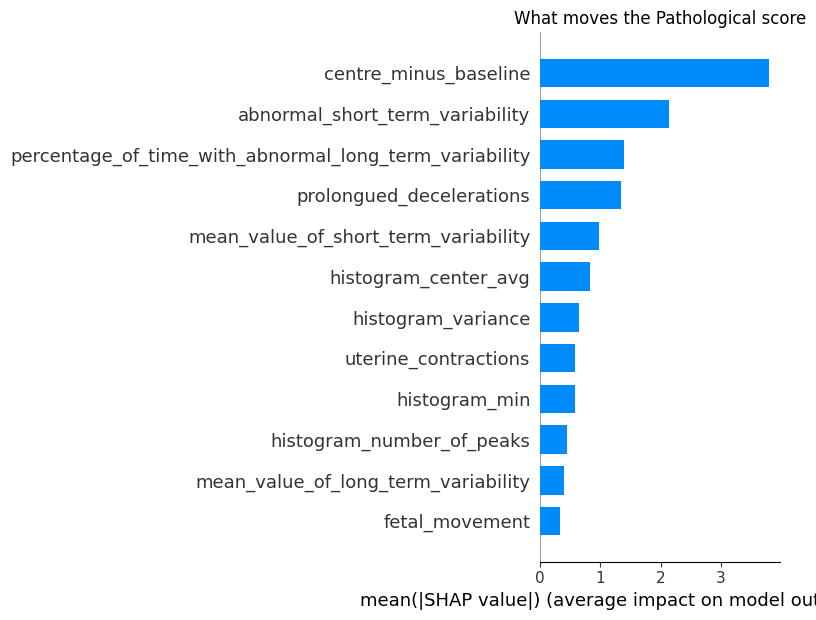

In [20]:
# Fitted on all training rows: SHAP explains a model rather than estimating its
# performance, and there is nothing to hold out from an explanation.
# Fitted on whatever section 17 SHIPS, which is not the same question as what section 17
# ADOPTED. Nothing was adopted for accuracy; the four-class target still goes forward, and
# this section is the reason it does, so it has to explain that model and not a stand-in.
if FOUR_CLASS_SHIPS:
    y_final = subtype_labels(X_feat, y_train)
    final_model = XGBClassifier(objective="multi:softprob", num_class=4,
                                eval_metric="mlogloss", random_state=SEED,
                                **BEST_PARAMS).fit(X_feat, y_final)
else:
    final_model = make_tree(**BEST_PARAMS).fit(X_feat, y_train)

# TreeExplainer is exact for tree ensembles rather than an approximation, and fast enough
# to run on every row. The output is one value per row per feature per class: how much
# that feature moved that row's score for that class, in log-odds.
sv = np.array(shap.TreeExplainer(final_model).shap_values(X_feat))
per_class = ([sv[:, :, k] for k in range(sv.shape[-1])] if sv.ndim == 3
             else [sv[k] for k in range(sv.shape[0])])
# The Pathological score is P(pattern A) + P(pattern B) when the four-class target is in
# use, so its attribution is the sum of the two. With three classes it is just class 2.
path_sv = (per_class[2] + per_class[3]) if len(per_class) == 4 else per_class[PATHOLOGICAL]

importance = pd.Series(np.abs(path_sv).mean(axis=0),
                       index=X_feat.columns).sort_values(ascending=False)
print("what moves the Pathological score most, mean |SHAP| in log-odds:\n")
for i, (name, v) in enumerate(importance.head(10).items(), 1):
    print(f"  {i:2d}. {name:56s} {v:.4f}")
print(f"\n  top feature is {importance.iloc[0]/importance.iloc[1]:.1f} times the second,")
print(f"  and {importance.iloc[0]/importance.iloc[1:4].sum():.1f} times the next three combined")

# Direction as well as size. Stated as "a LOW value" or "a HIGH value" pushes towards
# Pathological, because for centre_minus_baseline the worrying end is the negative one and
# a reader cannot be expected to infer that from a bare arrow.
print("\ndirection, for the top five:\n")
for name in importance.head(5).index:
    col = X_feat[name].values
    attr = path_sv[:, X_feat.columns.get_loc(name)]
    hi = attr[col >= np.quantile(col, 0.75)].mean()
    lo = attr[col <= np.quantile(col, 0.25)].mean()
    end = "HIGH values" if hi > lo else "LOW values"
    print(f"  {name:56s} {end} push towards Pathological")

# With the two patterns as separate targets, what drives each can be shown apart, which is
# the explanation section 7 said the pooled class was hiding.
if len(per_class) == 4:
    both = pd.DataFrame({
        "pattern A": pd.Series(np.abs(per_class[2]).mean(axis=0), index=X_feat.columns),
        "pattern B": pd.Series(np.abs(per_class[3]).mean(axis=0), index=X_feat.columns)})
    both = both.loc[both.max(axis=1).sort_values(ascending=False).head(8).index]
    print("\nwhat drives each pattern separately, mean |SHAP|:\n")
    print("  " + both.round(3).to_string().replace("\n", "\n  "))

plt.figure(figsize=(9, 5))
shap.summary_plot(path_sv, X_feat, plot_type="bar", max_display=12, show=False)
plt.title("What moves the Pathological score")
plt.tight_layout()
plt.show()


**Finding: the two patterns are read from different columns, and section 15's puzzle stays resolved.**

`centre_minus_baseline` moves the Pathological score by 3.79 in log-odds on a typical row,
**1.8 times the second feature** and about 0.8 times the next three added together. After it
come `abnormal_short_term_variability` at 2.13,
`percentage_of_time_with_abnormal_long_term_variability` at 1.39 and
`prolongued_decelerations` at 1.35.

**The directions are the right way round, and the code prints which end is the worrying
one** rather than leaving the reader to work it out. **Low** values of
`centre_minus_baseline` push towards Pathological, which is correct: the feature is centre
minus baseline, and a trace dragged down by repeated decelerations has a centre below its
baseline, so the worrying end is the negative one. Section 6's panel (d) showed the same
thing as a cloud below the diagonal, with a Pathological median of −18.0 bpm. **High**
values of `abnormal_short_term_variability`, of
`percentage_of_time_with_abnormal_long_term_variability` and of `prolongued_decelerations`
all push towards Pathological, and **low** values of `mean_value_of_short_term_variability`
push towards it. None of that had to come out that way, and a model whose top feature
pointed the wrong direction would be fitting something other than the physiology.

**The strongest result in this section is what the four-class target made visible.** Taking
the two Pathological patterns apart and asking what drives each one gives two nearly disjoint
sets of evidence:

| feature | pattern A | pattern B |
|---|---|---|
| `centre_minus_baseline` | 2.977 | 1.075 |
| `abnormal_short_term_variability` | 0.671 | 1.727 |
| `percentage_of_time_with_abnormal_long_term_variability` | **0.000** | **1.389** |
| `prolongued_decelerations` | **1.348** | **0.000** |
| `histogram_variance` | 0.642 | 0.028 |

Those two exact zeros are the point, and it is worth being precise about which columns they
are. `percentage_of_time_with_abnormal_long_term_variability` is pattern B's second largest
driver at 1.389 and contributes **exactly nothing** to pattern A.
`prolongued_decelerations` is pattern A's second largest at 1.348 and contributes **exactly
nothing** to pattern B. Each pattern has a column that the other does not use at all.

The rest of the table is shared rather than disjoint, and the claim should not be stretched
past what it shows. `centre_minus_baseline` and `abnormal_short_term_variability` both matter
to both patterns, just in different proportions: the first is worth 2.977 to A and 1.075 to
B, the second 0.671 to A and 1.727 to B. So the honest statement is that the two patterns
share the top two columns and lean on them the opposite way round, and each then has one
column of its own that the other ignores entirely.

**This is the reason the four-class target is still in the model, and it is the whole
reason.** Section 17 could not certify any accuracy gain from it: the precision difference
pointed the same way in all six of its stability worlds, but the verdict reversed in five of
them, so nothing was adopted. What survives that is this table. Asked for one pooled
Pathological answer, a depth-2 tree has to serve both patterns from the same handful of
splits, finding one threshold on `centre_minus_baseline` that suits a group at 2.977 and a
group at 1.075, and finding somewhere to put two columns that only one pattern uses. Asked
for four labels, it can put a separate set of splits behind each, and **it can be asked why
about each pattern separately**, which is what produced the two zeros above. A pooled model
cannot be asked that question at all. That is an explanation gain and it is not an accuracy
claim.

**It also matches what section 0 set out.** FIGO puts reduced variability and repeated
decelerations at the centre of a Pathological reading, and the top four features here are a
quantity that falls when decelerations drag the trace down, two measures of variability and a
count of prolonged decelerations. The split between the patterns lines up with the guideline
too: FIGO treats reduced variability and repeated decelerations as separate routes to the same
verdict, and that is what the table above shows the model doing.

**And it is consistent with section 15 rather than in tension with it.** That section
measured no accuracy gain from this feature and then showed why: the model was already
computing the same subtraction from the two parent columns, and dropping those parents once
C1 was present cost nothing. This section shows what it was computing them for. **The
accuracy did not move and the explanation did**, and those are separate things a project
can want.

One limit on all of this. SHAP explains the model, not the world. It says what this
particular fitted model leans on, and if the model learned something spurious then SHAP
will faithfully report the spurious thing.

## 20. The cases it still misses

**The question.** Some Pathological readings are still called something else. How many, what are they called instead, and is there anything they have in common?

**What the code does.** Builds the confusion matrix from out-of-fold predictions, then measures each missed row against the range of values Normal readings occupy.

**What to look for.** Where the misses go, and whether they look like healthy recordings or like abnormal ones that were outvoted.

In [21]:
pred_final = oof_proba_arch(FINAL_PROBA, X_feat, y_train, 0).argmax(1)

cm = pd.DataFrame(confusion_matrix(y_train, pred_final),
                  index=[f"true {CLASS_NAMES[k]}" for k in (0, 1, 2)],
                  columns=[f"called {CLASS_NAMES[k]}" for k in (0, 1, 2)])
print("out-of-fold confusion matrix, training rows, one fold assignment:\n")
print(cm.to_string(), "\n")

missed = (y_train == PATHOLOGICAL) & (pred_final != PATHOLOGICAL)
print(f"Pathological readings missed: {int(missed.sum())} of {N_PATH}")
print(f"  called Suspect  {int(((y_train == PATHOLOGICAL) & (pred_final == 1)).sum())}"
      f"   escalated, just not far enough")
print(f"  called Normal   {int(((y_train == PATHOLOGICAL) & (pred_final == 0)).sum())}"
      f"   sent home")
print(f"\nthe other direction: Normal readings called Pathological  "
      f"{int(((y_train == 0) & (pred_final == PATHOLOGICAL)).sum())} of {int((y_train == 0).sum())}\n")

# For each missed case, how many columns sit outside the range 90% of Normal readings
# occupy. A case that looks entirely Normal everywhere is a different problem from one
# that looks abnormal and was outvoted.
normal_rows = X_feat[y_train == 0]
lo, hi = normal_rows.quantile(0.05), normal_rows.quantile(0.95)
outside_missed = ((X_feat[missed] < lo) | (X_feat[missed] > hi)).sum(axis=1)
outside_normal = ((normal_rows < lo) | (normal_rows > hi)).sum(axis=1)

print(f"of the {X_feat.shape[1]} columns, how many sit outside the middle 90% of Normal:\n")
print(f"  {'called':>10s}   {'columns outside':>16s}")
for idx, n_out in outside_missed.items():
    print(f"  {CLASS_NAMES[pred_final[X_feat.index.get_loc(idx)]]:>10s}   {n_out:>16d}")
print(f"\n  median across the missed cases   {outside_missed.median():.0f} of {X_feat.shape[1]}")
print(f"  median for a Normal reading      {outside_normal.median():.0f} of {X_feat.shape[1]}")

# ---- the question section 7 left open --------------------------------------------
# Section 7 showed the Pathological class is two patterns, not one. A single recall figure
# averages across both. Whether the model handles them equally is a different question from
# how many it misses, and it is the one a clinician would ask.
#
# The grouping comes from section 7's clustering, which used no labels beyond "this row is
# Pathological" and never reaches the model. It stratifies the EVALUATION, not the fitting.
print("\n" + "=" * 78)
print("Does the model catch both Pathological patterns equally?")
print("=" * 78)
caught_by_seed = []
for fold_seed in range(N_SEEDS):
    p = oof_proba_arch(FINAL_PROBA, X_feat, y_train, fold_seed).argmax(1)
    caught_by_seed.append(pd.Series(
        p[(y_train == PATHOLOGICAL).nonzero()[0]] == PATHOLOGICAL, index=path_rows.index))
SUB = pd.DataFrame([{g: c[SUBTYPE == g].mean() for g in ("A", "B")}
                    for c in caught_by_seed])

LABEL = {"A": "A: wide ragged histogram, no sustained LTV abnormality",
         "B": "B: flat histogram, sustained abnormal LTV"}
print(f"out-of-fold recall within each pattern, {N_SEEDS} fold assignments:\n")
for g in ("A", "B"):
    n_g = int((SUBTYPE == g).sum())
    print(f"  {LABEL[g]:44s} {SUB[g].mean():.3f} +/- {sd(SUB[g]):.3f}   "
          f"({SUB[g].mean()*n_g:.0f} of {n_g} found)")
d_sub = (SUB["A"] - SUB["B"]).values
n_a, n_b = int((SUBTYPE == "A").sum()), int((SUBTYPE == "B").sum())
print(f"\n  difference {d_sub.mean():+.3f}, pattern A higher on "
      f"{int((d_sub > 0).sum())} of {N_SEEDS} assignments")
# Deliberately NOT converted into a single case count. The two rates have different
# denominators, so there is no one number of patients the gap is worth: closing it would
# mean finding {n_b} * {d_sub.mean():.3f} more of pattern B, which is what the counts above
# already say.
print(f"  Not converted to cases: the two rates sit on different denominators "
      f"({n_a} and {n_b}),")
print(f"  so the gap is {d_sub.mean()*n_b:.1f} more pattern-B readings found, not "
      f"{d_sub.mean()*N_PATH:.1f} cases overall.")
print(f"  The pooled Pathological recall averages across the two and hides the gap.")

# ---- how big a gap would appear by chance ----------------------------------------
# Section 7 chose the partition that separates these 140 rows best in the same feature
# space the model predicts from, so it sits close to the partition that separates RECALL
# best too. The gap above is a selected maximum rather than a neutral measurement. The
# control: split the same rows at random into the same two sizes and see what turns up
# with no structure behind it at all.
rng = np.random.default_rng(SEED)
n_a = int((SUBTYPE == "A").sum())
null_gaps = []
for _ in range(200):
    shuffled = rng.permutation(path_rows.index.values)
    in_a = pd.Series(np.isin(path_rows.index.values, shuffled[:n_a]), index=path_rows.index)
    null_gaps.append(abs(np.mean([c[in_a].mean() - c[~in_a].mean()
                                  for c in caught_by_seed])))
null_gaps = np.array(null_gaps)
print(f"\n  control: {len(null_gaps)} RANDOM splits of the same rows into groups of "
      f"{n_a} and {len(path_rows)-n_a}")
print(f"  give gaps of {null_gaps.mean():.3f} on average, 95th percentile "
      f"{np.percentile(null_gaps, 95):.3f}, largest {null_gaps.max():.3f}")
print(f"  a random split reaches {abs(d_sub.mean()):.3f} or more on "
      f"{float((null_gaps >= abs(d_sub.mean())).mean()):.1%} of tries")
print(f"\n  So the direction is worth following up and the SIZE is an upper bound. Ten out")
print(f"  of ten is not ten tests: the same 140 rows and the same frozen partition are")
print(f"  reused each time, with only the fold boundaries moving. The partition was")
print(f"  chosen to separate these rows as cleanly as possible, and a partition chosen")
print(f"  that way lands near the largest recall gap available in them.")


out-of-fold confusion matrix, training rows, one fold assignment:

                   called Normal  called Suspect  called Pathological
true Normal                 1288              21                    6
true Suspect                  38             189                    5
true Pathological              4               7                  129 

Pathological readings missed: 11 of 140
  called Suspect  7   escalated, just not far enough
  called Normal   4   sent home

the other direction: Normal readings called Pathological  6 of 1315

of the 20 columns, how many sit outside the middle 90% of Normal:

      called    columns outside
      Normal                  6
     Suspect                  5
     Suspect                  6
      Normal                  3
      Normal                  2
     Suspect                  6
     Suspect                  5
      Normal                  4
     Suspect                  3
     Suspect                  3
     Suspect                  4

  me

out-of-fold recall within each pattern, 10 fold assignments:

  A: wide ragged histogram, no sustained LTV abnormality 0.951 +/- 0.007   (86 of 90 found)
  B: flat histogram, sustained abnormal LTV    0.878 +/- 0.024   (44 of 50 found)

  difference +0.073, pattern A higher on 10 of 10 assignments
  Not converted to cases: the two rates sit on different denominators (90 and 50),
  so the gap is 3.7 more pattern-B readings found, not 10.2 cases overall.
  The pooled Pathological recall averages across the two and hides the gap.



  control: 200 RANDOM splits of the same rows into groups of 90 and 50
  give gaps of 0.034 on average, 95th percentile 0.079, largest 0.101
  a random split reaches 0.073 or more on 6.5% of tries

  So the direction is worth following up and the SIZE is an upper bound. Ten out
  of ten is not ten tests: the same 140 rows and the same frozen partition are
  reused each time, with only the fold boundaries moving. The partition was
  chosen to separate these rows as cleanly as possible, and a partition chosen
  that way lands near the largest recall gap available in them.


**Finding: 11 missed out of 140, and they do not look Normal.**

**One thing in the matrix answers a question section 11 left open.** Of the 43 misclassified
Suspect readings, **38 go to Normal and only 5 to Pathological**. So the confusion that
actually costs is Suspect against Normal, not Suspect against Pathological, despite the two
sitting on top of each other on section 6's strongest Normal-against-Pathological column. One column is not
the model, and a class can be easy to separate on one axis and hard to separate overall.

**Where the Pathological misses go matters more than how many there are.** Seven of the
eleven were called Suspect, which means the model escalated them, just not far enough, and a
midwife following a Suspect flag would be watching that trace more closely. Four were called
Normal, which is the error with a real cost.

The other direction is quiet. **Six Normal readings out of 1,315 were called
Pathological.** At this operating point the model is not generating false alarms in any
quantity, which is worth knowing before section 21 starts trading some away.

**The missed cases are not invisible.** Measuring each one against the range that 90% of
Normal readings occupy, the median missed case sits outside that range on 4 of 20 columns.
A typical Normal reading sits outside on 1. These readings look abnormal on several
measurements at once. They were not missed because they resemble healthy recordings, they
were missed because the evidence did not add up to enough confidence to cross the line.

**The pooled figure may be hiding a gap, and the control says be careful how much.** Section
7 found the Pathological class is two patterns, and section 19 has just shown they are read
from different columns. Measured separately and averaged over ten fold assignments, the
model catches pattern A, the wide ragged histogram, at 0.951, and pattern B, the flat trace
held abnormal, at 0.878. The output writes those as 86 of 90 and 44 of 50, which is the rate
multiplied back out by the size of each group to make it concrete. They are not counts from
any single run. Pattern A is higher on all ten fold assignments.

The gap is **0.073**, and the right way to read that is 3.7 more pattern-B readings found, not
10.2 cases. The two rates sit on denominators of 90 and 50, so converting a difference of
rates into a count of cases would be wrong.

**Then the control, which is the part that matters.** Section 7 chose that partition to
separate these 140 rows as cleanly as possible, in the same feature space the model predicts
from, so it lands near the biggest recall gap available in them. The honest question is how
big a gap appears from a partition with no structure behind it at all. Splitting the same
rows at random into the same groups of 90 and 50, two hundred times: **gaps average 0.034,
the 95th percentile is 0.079, and a random split reaches 0.073 or more on 6.5% of tries.**

**So this does not clear a bar anyone would call significant.** The ten out of ten does not
rescue it, because those ten share the same 140 rows and the same frozen partition with only
the fold boundaries moving, which makes them ten correlated redraws rather than ten tests.

**What it is worth is a lead, and the direction is the interesting half.** The pattern caught
less often is the flat trace held abnormal, which is the reduced-variability picture section 0
described and the one a clinician would least want missed. Fifty training cases cannot settle
it. It belongs in the next dataset's analysis plan, written down in advance, rather than in
this notebook's conclusions.

**That is a threshold problem, not a feature problem**, and it is the most useful thing
this section establishes. If the misses had looked entirely Normal on every column, the
answer would be that the 21 numbers do not contain what is needed, and section 8 already
named the most likely reason that could happen: the timing of decelerations is not in the
file. They do not look Normal. The information is there and the decision rule is discarding
it, which is a much cheaper thing to fix and is what the next section does.

One caution about the counts. This is one fold assignment, and section 12 measured a spread
of seven cases across ten of them. **Eleven missed should be read as roughly a dozen**, not
as exactly eleven.

## 20.1 A follow-up test, run after the fact

**The question.** Section 20 found the model catches pattern B, the flat trace held abnormal, less reliably than pattern A, and could not tell whether the gap was real at this sample size. Is there a resampling method that specifically helps the harder pattern, and how far does it get?

**What the code does.** Two changes stacked on the four-class architecture from section 17: all four FIGO candidates from section 8, rather than only `centre_minus_baseline`, and Borderline-SMOTE applied to the four training labels, so pattern A and pattern B are oversampled as separate classes rather than as one pooled Pathological label.

**Neither change is pre-registered, and that has to be said before the numbers are.** Both are motivated by results already seen, in sections 15, 16, 17 and 20, which is the exact thing sections 8 and 9 exist to prevent. This section is not measured against the adoption rule as if it belonged with the rest of the notebook. It is run once, reported once, and read as a lead for the next dataset rather than a change to this one.

**What to look for.** Whether any gain lands on pattern B specifically or spreads evenly across both, and how it sits against section 20's own control for what a gap this size looks like by chance.

In [22]:
# Not pre-registered. See the note above before reading the numbers.
from functools import partial
from imblearn.over_sampling import BorderlineSMOTE

# ---- all four FIGO candidates, not just the one that passed section 15 -----------
X_figo_all = X_cols.copy()
for _name in ("centre_minus_baseline", "baseline_outside_figo",
              "decels_per_contraction", "absent_accels_low_var"):
    _fit_fn, _tr_fn = CANDIDATES[_name]
    X_figo_all[_name] = np.asarray(_tr_fn(X_cols, _fit_fn(X_cols, y_train)), dtype=float)

# ---- section 17's four-class architecture, with an optional resampling step ------
def proba_four_class_bsmote(Xf, yf, Xs, resample=False):
    y4 = subtype_labels(Xf, yf)
    if len(np.unique(y4)) < 4:
        return XGBClassifier(objective="multi:softprob", num_class=3,
                             eval_metric="mlogloss", random_state=SEED,
                             **BEST_PARAMS).fit(Xf, yf).predict_proba(Xs)
    Xf_use, y4_use = Xf, y4
    if resample:
        # A and B are separate classes here (2 and 3), so BorderlineSMOTE resamples each
        # against everything else, including the OTHER pattern, rather than against
        # Normal and Suspect alone as it would if Pathological were still one label.
        try:
            Xf_use, y4_use = BorderlineSMOTE(random_state=SEED).fit_resample(Xf, y4)
        except ValueError:
            pass   # too few of a class in this fold for BorderlineSMOTE's own requirement
    p4 = XGBClassifier(objective="multi:softprob", num_class=4, eval_metric="mlogloss",
                       random_state=SEED, **BEST_PARAMS).fit(Xf_use, y4_use).predict_proba(Xs)
    return np.column_stack([p4[:, 0], p4[:, 1], p4[:, 2] + p4[:, 3]])


def cv_scores(fn):
    rows = []
    for s in range(N_SEEDS):
        p = oof_proba_arch(fn, X_figo_all, y_train, s).argmax(1)
        rows.append({"path": recall_score(y_train, p, labels=[PATHOLOGICAL], average="macro"),
                     "normal": recall_score(y_train, p, labels=[0], average="macro"),
                     "suspect": recall_score(y_train, p, labels=[1], average="macro"),
                     "precision": precision_score(y_train, p, labels=[PATHOLOGICAL],
                                                  average="macro", zero_division=0)})
    return pd.DataFrame(rows)


fn_plain = partial(proba_four_class_bsmote, resample=False)
fn_bsmote = partial(proba_four_class_bsmote, resample=True)

runs_plain = cv_scores(fn_plain)
runs_bsmote = cv_scores(fn_bsmote)

print("four-class target, all four FIGO features, no resampling:\n")
for col, label in (("path", "Pathological recall"), ("normal", "Normal recall"),
                   ("suspect", "Suspect recall"), ("precision", "Pathological precision")):
    print(f"  {label:22s} {runs_plain[col].mean():.3f}")
print()
compare("+ Borderline-SMOTE, resampling pattern A and pattern B as separate classes",
        runs_plain, runs_bsmote)

# ---- does the gain, if any, land on pattern B specifically? ----------------------
path_pos = (y_train == PATHOLOGICAL).nonzero()[0]

def pattern_recall(fn):
    a_r, b_r = [], []
    for s in range(N_SEEDS):
        p = oof_proba_arch(fn, X_figo_all, y_train, s).argmax(1)
        caught = pd.Series(p[path_pos] == PATHOLOGICAL, index=path_rows.index)
        a_r.append(caught[SUBTYPE == "A"].mean())
        b_r.append(caught[SUBTYPE == "B"].mean())
    return np.array(a_r), np.array(b_r)

a_plain, b_plain = pattern_recall(fn_plain)
a_bsmote, b_bsmote = pattern_recall(fn_bsmote)

print("\nper-pattern recall, fixed evaluation clustering from section 7:\n")
print(f"  {'':32s} {'pattern A':>10s} {'pattern B':>10s} {'gap':>7s}")
print(f"  {'no resampling':32s} {a_plain.mean():>10.3f} {b_plain.mean():>10.3f} "
      f"{a_plain.mean()-b_plain.mean():>7.3f}")
print(f"  {'with Borderline-SMOTE':32s} {a_bsmote.mean():>10.3f} {b_bsmote.mean():>10.3f} "
      f"{a_bsmote.mean()-b_bsmote.mean():>7.3f}")
print(f"\n  pattern B: {(b_bsmote.mean()-b_plain.mean())*100:+.2f} points, "
      f"better on {int((b_bsmote>b_plain).sum())} of {N_SEEDS}")
print(f"  pattern A: {(a_bsmote.mean()-a_plain.mean())*100:+.2f} points, "
      f"better on {int((a_bsmote>a_plain).sum())} of {N_SEEDS}")

# ---- read against section 20's own control, not a fresh one ----------------------
# Section 20 already measured what a gap this size looks like from a partition with no
# structure behind it: 200 random splits of the same 90/50 rows average a gap of 0.034,
# with a 95th percentile of 0.079. That control is reused here rather than rebuilt, since
# nothing about the resampling changes what a random split would produce.
print(f"\n  for scale, section 20's control: random 90/50 splits of these same rows")
print(f"  average a gap of 0.034, 95th percentile 0.079, reaching 0.073 or more on 6.5% of tries")

four-class target, all four FIGO features, no resampling:

  Pathological recall    0.924
  Normal recall          0.983
  Suspect recall         0.817
  Pathological precision 0.935

  + Borderline-SMOTE, resampling pattern A and pattern B as separate classes
     before 0.924   after 0.932   difference +0.0079  (+1.1 cases)
     better on 7 of 10   + = - + + + + + + -
     Normal recall 0.9833 -> 0.9656  (-1.77 points)
     VERDICT: no measurable effect; fails clause 1 and 2 (better on only 7 of 10; worth +1.1 cases)




per-pattern recall, fixed evaluation clustering from section 7:

                                    pattern A  pattern B     gap
  no resampling                         0.950      0.878   0.072
  with Borderline-SMOTE                 0.951      0.898   0.053

  pattern B: +2.00 points, better on 7 of 10
  pattern A: +0.11 points, better on 5 of 10

  for scale, section 20's control: random 90/50 splits of these same rows
  average a gap of 0.034, 95th percentile 0.079, reaching 0.073 or more on 6.5% of tries


**Finding: the gain is small, correctly targeted, and still not enough to prove itself.**

Borderline-SMOTE moves Pathological recall by roughly one case, better on 7 of 10 fold
assignments, at a cost of under two points of Normal recall. Judged by the rule that has
governed every other change in this notebook, that is **no measurable effect**, the same
verdict plain SMOTE received in section 16.

**The per-pattern breakdown is the reason this section exists rather than stopping there.**
Pattern A does not move: recall goes from 0.950 to 0.951, a tenth of a point,
better on only half the fold assignments, which is what no effect looks like. Pattern B
moves about two points, better on 7 of 10. Giving Borderline-SMOTE the four class labels
lets it treat pattern A and pattern B as different populations rather than one pooled
minority class, and the two patterns respond exactly as differently as that framing
predicts.

**Read against section 20's own control, the resulting gap sits inside the range chance
alone produces.** The gap between the two patterns narrows from about 0.07 to about 0.05,
and section 20 already measured a random 90/50 split of these same rows landing at 0.073 or
worse on 6.5% of tries, averaging 0.034. A gap of 0.05 is not distinguishable from that
noise floor, so this section cannot claim the gap closed for a reason rather than by luck.

**What this is evidence of is narrower and more useful than a result.** The mechanism
works as described: boundary-aware resampling that can see the two Pathological patterns
as separate classes spends its effort on the one that needs it, and only on that one.
What is missing is not the idea, it is the 50 pattern-B rows a resampling method would need
to demonstrate it on with any confidence. That is the shape the next dataset's analysis plan
should take: the same architecture, the same resampling step, run on a Pathological class
large enough that a two- or three-point shift in one subtype's recall is no longer inside
the fold assignment's own noise.

## 21. The threshold, and the held-out result

**The question.** The model outputs a probability and then picks the largest. That choice buries a decision about how many false alarms are acceptable. What does exposing it cost, and what does the whole thing score on rows it has never seen?

**What the code does.** Draws the trade-off curve from ten fold assignments rather than one, picks the cutoff reaching a chosen recall target on each, then applies the median of those to the held-out rows. This is the only time the held-out labels are used to score anything; section 5 counted them to report the split sizes and nothing has read them since.

**What to look for.** The shape of the curve, how much the chosen cutoff moves between fold assignments, and what the held-out rows say.

what a lower cutoff buys and what it costs, averaged over 10 fold assignments:

    cutoff   Path recall   Path precision   Normal recall
      0.50         0.921            0.938           0.983
      0.40         0.933            0.930           0.983
      0.30         0.938            0.920           0.982
      0.20         0.946            0.905           0.981


      0.15         0.951            0.892           0.981
      0.10         0.954            0.876           0.980
      0.05         0.961            0.840           0.978

  0.50 -> 0.30 : recall +1.7 points (+2.4 cases)  precision -1.7 points
  0.10 -> 0.05 : recall +0.8 points (+1.1 cases)  precision -3.6 points


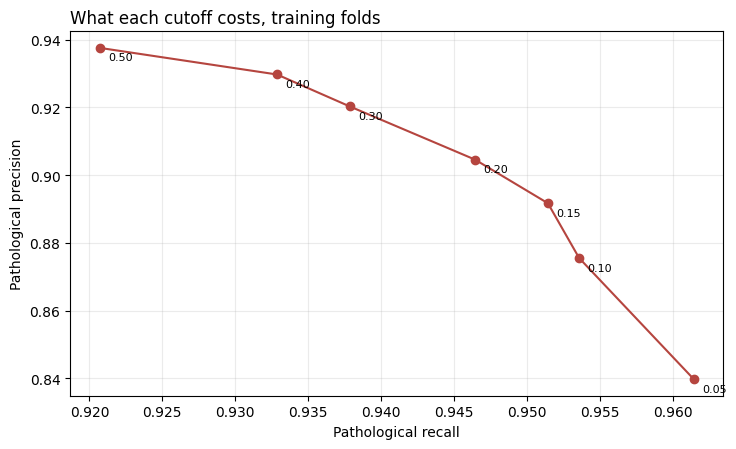


cutoff reaching a 95% Pathological recall target on the training folds:
  per assignment: 0.039, 0.057, 0.175, 0.179, 0.200, 0.203, 0.231, 0.246, 0.258, 0.385
  median taken forward: 0.2013
  that target is a choice, not a prediction: what the held-out rows test is
  whether a cutoff fixed on one set of rows still behaves on another.

  One mismatch worth naming rather than hiding. These cutoffs come from models
  fitted on four fifths of the training rows, and are about to be applied to a
  model fitted on all of them. More data makes probabilities a little sharper, so
  the same number does not mean quite the same thing on the two objects. The
  held-out result below is what settles whether that matters here.

HELD-OUT SET, 422 rows, first and only use

                             Path recall   Path precision   Normal recall
  largest probability wins         0.914            0.914           0.982
  cutoff at 0.201                  0.971            0.895           0.982

  34 of 35

  Row 0 is held out, and it is truly Suspect.
  Section 14 averages the three centre statistics, and section 15 keeps the
  result as centre_minus_baseline, which section 19 shows is the model's
  largest driver. So the bad cell reaches the feature that matters most:

                                  centre_minus_baseline   P(Pathological)   flagged
    as the file has it                          6.00 bpm             0.008        no
    bad cell excluded                           0.50 bpm             0.072        no

  The decision does not change, and that is the honest answer here: both
  scores sit well below the 0.201 cutoff, so this row is called the same
  way either way. It is not quite nothing. The bad cell moves the model's
  largest feature by 5.5 bpm and multiplies P(Pathological) by 9. On a row
  sitting nearer the cutoff, or on a Pathological row, the same size of error
  would cost a decision. Here it does not, and that is luck rather than a
  property of the fix.

  Tha

In [23]:
# ---------------------------------------------------------------- the curve
# Probabilities from ten fold assignments, so the curve is not one draw of the luck
# section 12 measured.
def tree_proba(X_fit, y_fit, X_score):
    return FINAL_PROBA(X_fit, y_fit, X_score)      # whatever section 17 adopted


def oof_proba(X, y, fold_seed):
    out = np.zeros((len(y), 3))
    for fit_idx, score_idx in StratifiedKFold(
            5, shuffle=True, random_state=fold_seed).split(X, y):
        out[score_idx] = tree_proba(X.iloc[fit_idx], y[fit_idx], X.iloc[score_idx])
    return out


probas = [oof_proba(X_feat, y_train, s) for s in range(N_SEEDS)]

CUTOFFS = (0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05)
print(f"what a lower cutoff buys and what it costs, averaged over {N_SEEDS} fold "
      f"assignments:\n")
print(f"  {'cutoff':>8s} {'Path recall':>13s} {'Path precision':>16s} {'Normal recall':>15s}")
curve = []
for t in CUTOFFS:
    rows = []
    for p in probas:
        pred_t = np.where(p[:, PATHOLOGICAL] >= t, PATHOLOGICAL, p[:, NON_PATHOLOGICAL].argmax(1))
        rows.append(score(y_train, pred_t))
    m = pd.DataFrame(rows).mean()
    curve.append((t, m["recall_pathological"], m["precision_pathological"],
                  m["recall_normal"]))
    print(f"  {t:>8.2f} {m['recall_pathological']:>13.3f} "
          f"{m['precision_pathological']:>16.3f} {m['recall_normal']:>15.3f}")

# the two steps quoted in the finding, computed rather than read off by eye
c = {t: (r, p, n) for t, r, p, n in curve}
print(f"\n  0.50 -> 0.30 : recall {(c[0.30][0]-c[0.50][0])*100:+.1f} points "
      f"({(c[0.30][0]-c[0.50][0])*N_PATH:+.1f} cases)  "
      f"precision {(c[0.30][1]-c[0.50][1])*100:+.1f} points")
print(f"  0.10 -> 0.05 : recall {(c[0.05][0]-c[0.10][0])*100:+.1f} points "
      f"({(c[0.05][0]-c[0.10][0])*N_PATH:+.1f} cases)  "
      f"precision {(c[0.05][1]-c[0.10][1])*100:+.1f} points")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot([r for _, r, _, _ in curve], [p for _, _, p, _ in curve], "o-", color="#b5453f")
for t, r, p, _ in curve:
    ax.annotate(f"{t:.2f}", (r, p), textcoords="offset points", xytext=(6, -9), fontsize=8)
ax.set_xlabel("Pathological recall")
ax.set_ylabel("Pathological precision")
ax.set_title("What each cutoff costs, training folds", loc="left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------- choose, then apply
# A target, not a prediction. The cutoff reaching it is found separately on each fold
# assignment and the median taken, so one unlucky draw cannot set it.
TARGET = 0.95
chosen_cutoffs = []
for p in probas:
    pp = p[:, PATHOLOGICAL]
    candidates = np.sort(np.unique(pp))[::-1]
    reached = [t for t in candidates if (pp[y_train == PATHOLOGICAL] >= t).mean() >= TARGET]
    chosen_cutoffs.append(reached[0] if reached else candidates[-1])
CUTOFF = float(np.median(chosen_cutoffs))
print(f"\ncutoff reaching a {TARGET:.0%} Pathological recall target on the training folds:")
print(f"  per assignment: {', '.join(f'{c:.3f}' for c in sorted(chosen_cutoffs))}")
print(f"  median taken forward: {CUTOFF:.4f}")
print(f"  that target is a choice, not a prediction: what the held-out rows test is")
print(f"  whether a cutoff fixed on one set of rows still behaves on another.\n")
print(f"  One mismatch worth naming rather than hiding. These cutoffs come from models")
print(f"  fitted on four fifths of the training rows, and are about to be applied to a")
print(f"  model fitted on all of them. More data makes probabilities a little sharper, so")
print(f"  the same number does not mean quite the same thing on the two objects. The")
print(f"  held-out result below is what settles whether that matters here.\n")

# ---------------------------------------------------------------- the held-out set
def prepare(frame):
    """Every column decision from sections 14 and 15, applied to unseen rows.

    Written out rather than reused, because this is the function that would have to exist
    in production and any step missing here is a step the model would not get at
    inference time.
    """
    out = frame.drop(columns=["histogram_width", "histogram_mean", "histogram_median",
                              "histogram_mode", "severe_decelerations",
                              "histogram_tendency"]).copy()
    out["histogram_center_avg"] = frame[["histogram_mean", "histogram_median",
                                         "histogram_mode"]].mean(axis=1)
    out["severe_decelerations_present"] = (frame["severe_decelerations"] > 0).astype(int)
    out["tendency_falling"] = (frame["histogram_tendency"] == -1).astype(int)
    out["tendency_rising"] = (frame["histogram_tendency"] == 1).astype(int)
    for name in going_forward:
        # the SAME reference points the model was fitted with, never refitted on the rows
        # being predicted, which is the whole reason CAND_PARAMS exists
        out[name] = np.asarray(CANDIDATES[name][1](out, CAND_PARAMS[name]), dtype=float)
    return out[X_feat.columns]


# The same function the curve was built from, fitted on all the training rows and applied
# to the held-out ones. Going through FINAL_PROBA keeps the four-class collapse in one place.
proba_test = FINAL_PROBA(X_feat, y_train, prepare(X_test))
pred_argmax = proba_test.argmax(1)
pred_cutoff = np.where(proba_test[:, PATHOLOGICAL] >= CUTOFF, PATHOLOGICAL,
                       proba_test[:, NON_PATHOLOGICAL].argmax(1))

print(f"HELD-OUT SET, {len(y_test)} rows, first and only use\n")
print(f"  {'':24s} {'Path recall':>13s} {'Path precision':>16s} {'Normal recall':>15s}")
for name, p in (("largest probability wins", pred_argmax),
                (f"cutoff at {CUTOFF:.3f}", pred_cutoff)):
    s = score(y_test, p)
    print(f"  {name:24s} {s['recall_pathological']:>13.3f} "
          f"{s['precision_pathological']:>16.3f} {s['recall_normal']:>15.3f}")

caught = int(((y_test == PATHOLOGICAL) & (pred_cutoff == PATHOLOGICAL)).sum())
print(f"\n  {caught} of {N_PATH_TEST} Pathological readings found, "
      f"{N_PATH_TEST-caught} missed")
print(f"  one held-out case is {1/N_PATH_TEST:.1%}, so the two neighbouring values this")
print(f"  figure could have taken are {(caught-1)/N_PATH_TEST:.3f} and "
      f"{min(caught+1, N_PATH_TEST)/N_PATH_TEST:.3f}")

# ---- what section 4's kept row costs, measured rather than assumed ----------------
# Section 4 found one row that contradicts itself and kept it, promising to report the
# price here. That row is in the held-out set, so this is the first point in the notebook
# allowed to look at it. Nothing below changes a model or a decision: it scores one row
# twice and prints the difference.
_pos = int(np.where(test_source_index == BAD_ROW)[0][0]) if (
    test_source_index == BAD_ROW).any() else -1
print("\n" + "-" * 78)
print(f"WHAT SECTION 4's KEPT ROW COSTS")
print("-" * 78)
if _pos < 0:
    print(f"  Row {BAD_ROW} landed in the training rows this time, so its effect is spread")
    print(f"  through the fitted model rather than visible as one prediction.")
else:
    _X_bad = prepare(X_test).iloc[[_pos]].copy()
    _p_as_is = FINAL_PROBA(X_feat, y_train, _X_bad)[0]
    # the same row with the impossible cell excluded from the centre average, which is the
    # 'drop the cell' option section 4 set out and did not take
    _med, _mode = X_test.iloc[_pos]["histogram_median"], X_test.iloc[_pos]["histogram_mode"]
    _base = X_test.iloc[_pos]["baseline value"]
    _X_fix = _X_bad.copy()
    _X_fix["histogram_center_avg"] = np.mean([_med, _mode])
    _X_fix["centre_minus_baseline"] = np.mean([_med, _mode]) - _base
    _p_fix = FINAL_PROBA(X_feat, y_train, _X_fix)[0]
    print(f"  Row {BAD_ROW} is held out, and it is truly "
          f"{CLASS_NAMES[int(y_test[_pos])]}.")
    print(f"  Section 14 averages the three centre statistics, and section 15 keeps the")
    print(f"  result as centre_minus_baseline, which section 19 shows is the model's")
    print(f"  largest driver. So the bad cell reaches the feature that matters most:")
    print()
    print(f"    {'':28s} {'centre_minus_baseline':>22s} {'P(Pathological)':>17s} "
          f"{'flagged':>9s}")
    for _lbl, _cmb, _pr in (("as the file has it", float(_X_bad['centre_minus_baseline'].iloc[0]), _p_as_is),
                            ("bad cell excluded", float(_X_fix['centre_minus_baseline'].iloc[0]), _p_fix)):
        print(f"    {_lbl:28s} {_cmb:>19.2f} bpm {_pr[PATHOLOGICAL]:>17.3f} "
              f"{('yes' if _pr[PATHOLOGICAL] >= CUTOFF else 'no'):>9s}")
    print()
    _flips = (_p_as_is[PATHOLOGICAL] >= CUTOFF) != (_p_fix[PATHOLOGICAL] >= CUTOFF)
    if _flips:
        print(f"  One bad cell flips the decision on this row. The row is Suspect and the")
        print(f"  corrupt value is the one that keeps it unflagged, so the error happens to")
        print(f"  produce the tidier outcome here. That is luck and not a defence: the same")
        print(f"  size of error on a Pathological row would cost a missed case.")
    else:
        _ratio = _p_fix[PATHOLOGICAL] / max(_p_as_is[PATHOLOGICAL], 1e-9)
        print(f"  The decision does not change, and that is the honest answer here: both")
        print(f"  scores sit well below the {CUTOFF:.3f} cutoff, so this row is called the same")
        print(f"  way either way. It is not quite nothing. The bad cell moves the model's")
        print(f"  largest feature by {abs(float(_X_bad['centre_minus_baseline'].iloc[0]) - float(_X_fix['centre_minus_baseline'].iloc[0])):.1f} bpm and multiplies P(Pathological) by "
              f"{_ratio:.0f}. On a row")
        print(f"  sitting nearer the cutoff, or on a Pathological row, the same size of error")
        print(f"  would cost a decision. Here it does not, and that is luck rather than a")
        print(f"  property of the fix.")
    print()
    print(f"  That is the whole bill: one row of {len(y_test)} held out, and it does not")
    print(f"  touch the {N_PATH_TEST} Pathological readings the headline number is measured")
    print(f"  on. Weigh it against reshuffling the split, which section 4 set out. A reader")
    print(f"  who would rather drop the row has a case, and it is a case about method")
    print(f"  rather than about this result.")

s_final = score(y_test, pred_cutoff)
log_step("final model, held-out set", "the held-out rows, used once",
         [s_final["recall_pathological"]], single=True)
state_of_play("nothing further, this is the end of the chain")


**Finding: the curve is worth handing over, and the cutoff on it is much less stable than the recall it buys.**

**The curve is not linear and that is the point.** Going from the default down to 0.30 buys
1.7 points of Pathological recall, which is 2.4 cases, for 1.7 points of precision. Going
from 0.10 down to 0.05 buys 0.8 points, about one case, for another 3.6 points of precision.
There is a region where the trade is good and a region where it is not, and the only way to
see that is to draw it.

**The cutoff was chosen on the training folds and applied unchanged**, which is the
discipline the whole notebook has been building towards. Reading a cutoff off a table and
then reporting a score from that same table would flatter it, because the cutoff would have
been fitted to the noise in those particular rows.

**The surprise is how much the cutoff itself moves.** Asking each of the ten fold
assignments for the cutoff that reaches a 95% recall target gives answers from **0.039 to
0.385**, close to a ten-fold range, for a target that only moves the recall figure by a few
points. The median, 0.201, is what goes forward. **A single cross-validation run would have
returned one of those ten numbers and given no hint that the others existed**, and a
deployment built on 0.039 would behave very differently from one built on 0.385. This is the
strongest argument in the notebook for repeating a measurement rather than taking it once.

Section 18 asked whether calibrating the probabilities would settle this, and the answer was
no. The spread is not a property of the scale the scores are written on. It is which few of
140 Pathological readings sit nearest the boundary, and that changes with the fold assignment
whatever the scores are rescaled to.

**Held out, 422 rows, used once:**

| | Pathological recall | Pathological precision | Normal recall |
|---|---|---|---|
| largest probability wins | 0.914 | 0.914 | 0.982 |
| cutoff at 0.201 | 0.971 | 0.895 | 0.982 |

34 of 35 Pathological readings found, 1 missed, for 1.9 points of precision. **Normal recall
did not move at all**, which says the extra flags came out of the Suspect band rather than
out of healthy readings.

**Do not read 0.971 to three decimal places.** There are 35 Pathological readings held out,
so the two neighbouring values this figure could have taken are 0.943 and 1.000. One patient
either way. The honest way to quote it is 34 of 35. What the held-out set establishes is that a cutoff fixed on one set of
rows still behaves sensibly on rows it has never seen, and it is far too small to establish
anything finer.

**What is actually being handed over is the curve, not the cutoff.** The 95% target was
chosen here to have something concrete to demonstrate, and it is a choice rather than a
finding. Which target is right depends on how many flagged traces a ward can review in a
shift, and that is not a question the data can answer.

### 21.1 The same trade-off, as something you can move

The table above is the deliverable, and a table is a poor way to hand a trade-off to
somebody who has to live with it. The panel below is the same curve with a slider on it.

**It answers a different question from the table.** The table asks what each cutoff does on
the training folds. The panel asks what happens when you name a recall target, let the
cutoff be chosen on training data alone to hit it, and then apply that cutoff to patients
that split's model never saw. That is done forty times over, on forty different
train-and-test boundaries, so every figure comes with the range it moved across rather than
as a single number.

**One thing to be clear about, because section 5 made a promise.** These forty splits are cut
out of the 1,687 training rows, not out of the whole file. The 422 held-out rows were read
once, in the table above, and nothing here touches them again. What the panel measures is how
much a cutoff MOVES between refits, which is a different question from how well the model
performs, and it needs many boundaries rather than one clean set of unseen rows.

In [24]:
# Forty resampled train/test boundaries. On each one the cutoff is chosen out-of-fold on
# the training side alone to hit a requested recall, then applied unchanged to the held-out
# fifth. Everything reported is measured on those held-out rows.
#
# This is the same discipline as the rest of section 21, repeated forty times so that the
# console can show a range instead of a point. It is the most expensive cell in the
# notebook, and the reason is that a single split cannot say how much a cutoff moves.
import json, html as html_mod, warnings, re
from IPython.display import HTML

CONSOLE_SPLITS = 40
TARGETS = [round(0.80 + 0.01 * i, 2) for i in range(21)]

# Resampled INSIDE the training rows, not across the whole file. The configuration this
# panel uses (the hyperparameters, the column decisions, the candidate that went forward)
# was chosen on these 1,687 rows, so putting the original held-out rows into the training
# side of these splits would let a configuration selected on one set of rows be scored on
# rows sitting in the other. The held-out 422 stay untouched, exactly as section 21 used
# them once and stopped.
X_pool = prepare(X_train)                 # the section 14 and 15 columns, training rows
y_pool = y_train
rows_by_target = {t: [] for t in TARGETS}

for split_seed in range(CONSOLE_SPLITS):
    itr, ite = train_test_split(np.arange(len(X_pool)), test_size=0.2,
                                stratify=y_pool, random_state=split_seed)
    Xtr, Xte = X_pool.iloc[itr], X_pool.iloc[ite]
    ytr, yte = y_pool[itr], y_pool[ite]

    # out-of-fold probabilities on the TRAINING side, which is where the cutoff is chosen
    p_in = np.zeros(len(ytr))
    for fit_idx, score_idx in StratifiedKFold(
            5, shuffle=True, random_state=SEED).split(Xtr, ytr):
        p_in[score_idx] = FINAL_PROBA(Xtr.iloc[fit_idx], ytr[fit_idx],
                                      Xtr.iloc[score_idx])[:, PATHOLOGICAL]

    # one model per split, fitted on the whole training side, scored on held-out rows
    p_out = FINAL_PROBA(Xtr, ytr, Xte)
    pp_out = p_out[:, PATHOLOGICAL]
    fallback = p_out[:, NON_PATHOLOGICAL].argmax(1)

    is_path_in, is_path_out = ytr == PATHOLOGICAL, yte == PATHOLOGICAL
    is_norm_out = yte == 0
    grid = np.sort(np.unique(p_in))[::-1]
    for t in TARGETS:
        # grid runs high to low, so the FIRST cutoff meeting the target is the highest
        # one that does, which is the least aggressive setting still reaching it
        hits = [c for c in grid if (p_in[is_path_in] >= c).mean() >= t]
        cut = float(hits[0]) if hits else float(grid[-1])
        pred = np.where(pp_out >= cut, PATHOLOGICAL, fallback)
        rows_by_target[t].append({
            "cut": cut,
            "recall": float((pred[is_path_out] == PATHOLOGICAL).mean()),
            # false alarm: a healthy reading flagged Pathological
            "fa": float((pred[is_norm_out] == PATHOLOGICAL).mean()),
        })

# ---- fold the forty splits into the shape the console expects --------------------
def band(values, lo=10, hi=90):
    return float(np.percentile(values, lo)), float(np.percentile(values, hi))


console_curve = []
for t in TARGETS:
    rs = np.array([r["recall"] for r in rows_by_target[t]])
    fs = np.array([r["fa"] for r in rows_by_target[t]])
    cs = np.array([r["cut"] for r in rows_by_target[t]])
    r_lo, r_hi = band(rs)
    f_lo, f_hi = band(fs)
    console_curve.append({
        "target": t, "recall": float(rs.mean()), "recallLo": r_lo, "recallHi": r_hi,
        "recallWorst": float(rs.min()), "fa": float(fs.mean()), "faLo": f_lo, "faHi": f_hi,
        "thrMed": float(np.median(cs)), "thrRatio": float(cs.max() / max(cs.min(), 1e-9)),
        # how often the cutoff actually reached the target it was aiming at
        "hitRate": float((rs >= t).mean()),
    })

n_path_test = int(round(len(y_pool) * 0.2 * (y_pool == PATHOLOGICAL).mean()))
n_norm_test = int(round(len(y_pool) * 0.2 * (y_pool == 0).mean()))
DATA = {"meta": {"nSplits": CONSOLE_SPLITS, "nPathTest": n_path_test,
                 "nNormTest": n_norm_test,
                 "prevalence": {"normal": float((y_pool == 0).mean()),
                                "suspect": float((y_pool == 1).mean()),
                                "path": float((y_pool == PATHOLOGICAL).mean())}},
        "curve": console_curve}

print(f"{CONSOLE_SPLITS} resampled splits of the 1,687 TRAINING rows x {len(TARGETS)} "
      f"targets.")
print(f"Every figure below is scored on the fifth of those rows each split holds back, and")
print(f"the cutoff is chosen on the other four fifths. The original 422 held-out rows are")
print(f"not used here: section 21 used them once and that is the only time they are read.\n")
print(f"  {'target':>7s} {'recall':>8s} {'10-90 band':>16s} {'false alarms':>13s} "
      f"{'cutoff':>8s} {'stability':>10s} {'target met':>11s}")
for d in console_curve:
    if round(d["target"] * 100) % 5 == 0:
        print(f"  {d['target']:>7.0%} {d['recall']:>8.1%} "
              f"{d['recallLo']:>7.1%} to {d['recallHi']:<6.1%} {d['fa']:>13.2%} "
              f"{d['thrMed']:>8.3f} {d['thrRatio']:>9.1f}x {d['hitRate']:>10.0%}")
print()
print("  'target met' is the share of the 40 refits where recall actually reached the")
print("  target. A cutoff tuned to land exactly on a target lands below it about half the")
print("  time by construction, which is why that column matters when naming one.")

# ---- rebuild the console page from the project template ---------------------------
# The page itself is unchanged: it is one const DATA line and then generic HTML, CSS and
# JavaScript. Only the data and the methods note are replaced, so the walkthrough's console
# and the companion notebook's stay the same object with different numbers in it.
TEMPLATE = None
for folder in (".", "..", "/mnt/user-data/uploads/fetal-health-ctg"):
    candidate = Path(folder) / "threshold_console.html"
    if candidate.exists():
        TEMPLATE = candidate.read_text(encoding="utf-8")
        break

if TEMPLATE is None:
    print("\nthreshold_console.html not found, so the panel below cannot be rebuilt.")
else:
    page = re.sub(r"const DATA = \{.*?\};",
                  "const DATA = " + json.dumps(DATA) + ";", TEMPLATE, flags=re.S)
    elbow = next(d for d in console_curve if d["target"] == 0.95)
    methods = (
        "<h2>How these numbers were produced</h2>\n"
        f"<p>{CONSOLE_SPLITS} resampled train/test boundaries. On each, the cutoff is "
        "chosen out-of-fold on the training data alone to hit the requested recall, then "
        "applied unchanged to the fifth held back on that split. Everything is measured "
        "on rows that split's model never saw. The splits are drawn from the training rows "
        "only, and the model configuration was chosen on that same pool, so read these as "
        "how much a cutoff MOVES between refits rather than as a fresh estimate of how well "
        "the model performs.</p>\n"
        f"<p>Two honest limits. A held-out set holds about {n_path_test} Pathological "
        f"cases, so recall moves in steps of {1/n_path_test:.1%} and the bands above are "
        "one to two cases wide. And a cutoff tuned to hit a target exactly lands below it "
        "about half the time by construction, so aim a little high: a 95% target delivers "
        f"{elbow['recall']:.0%} on average and reaches 95% on "
        f"{elbow['hitRate']:.0%} of refits.</p>\n"
        "<p>The cutoff stability figure is the ratio between the largest and smallest "
        f"cutoff chosen across the {CONSOLE_SPLITS} refits. At a 95% target it is "
        f"{elbow['thrRatio']:.0f} times, the largest figure in the table. Up to about a 90% "
        "target it behaves like an ordinary quantile. By 95% it is already being set by "
        "whichever single case happened to be hardest in that sample, which is what the "
        "jump from single figures to tens is showing.</p>\n"
        "<p style=\"color:var(--ink-3)\">Model: XGBoost "
        f"({FINAL_NAME}), "
        f"<code>max_depth={BEST_PARAMS['max_depth']}</code>, "
        f"<code>learning_rate={BEST_PARAMS['learning_rate']}</code>, "
        f"<code>n_estimators={BEST_PARAMS['n_estimators']}</code>, on "
        f"{len(X_pool):,} training cardiotocogram summaries with the section 15 feature. "
        "Triage "
        "support only. Nothing here is a diagnostic claim.</p>")
    page = re.sub(r"<h2>How these numbers were produced</h2>.*?(?=\s*</section>)",
                  methods, page, flags=re.S)

    OUT = Path("threshold_console_walkthrough.html")
    OUT.write_text(page, encoding="utf-8")
    print(f"\nwrote {OUT} ({len(page):,} bytes)")

    warnings.filterwarnings("ignore", message="Consider using IPython.display.IFrame")
    display(HTML('<iframe srcdoc="' + html_mod.escape(page, quote=True)
                 + '" style="width:100%;height:940px;border:1px solid #d8d8d8;'
                   'border-radius:10px;background:#eaeaea"></iframe>'))


40 resampled splits of the 1,687 TRAINING rows x 21 targets.
Every figure below is scored on the fifth of those rows each split holds back, and
the cutoff is chosen on the other four fifths. The original 422 held-out rows are
not used here: section 21 used them once and that is the only time they are read.

   target   recall       10-90 band  false alarms   cutoff  stability  target met
      80%    81.7%   71.1% to 92.9%          0.24%    0.919       1.2x        57%
      85%    86.2%   75.0% to 92.9%          0.35%    0.834       1.7x        57%
      90%    91.2%   82.1% to 100.0%         0.57%    0.561       5.6x        55%
      95%    94.7%   88.9% to 100.0%         0.87%    0.102      45.0x        60%
     100%    99.3%   96.4% to 100.0%         7.03%    0.001      30.1x        80%

  'target met' is the share of the 40 refits where recall actually reached the
  target. A cutoff tuned to land exactly on a target lands below it about half the
  time by construction, which is why

**Finding: naming a recall target is easy and holding it is not.**

**Move the slider and watch what the cutoff does.** Up to about a 90% target it behaves
like an ordinary quantile: the stability figure, which is the largest cutoff chosen across
the forty refits divided by the smallest, is 1.2 at 80%, 1.7 at 85% and 5.6 at 90%. **By the
95% target it is 45**, the largest value in the table, and that is the target this notebook
chose. The false-alarm cost rises far more gently over the same stretch, from 0.24% to 0.87%,
which is the trap: the thing that blows up is not the one being watched. Past 90% the cutoff stops being a
statistic about the distribution and becomes a statistic about one patient: it has to drop
below whichever Pathological case happened to be hardest in that particular sample, and which
case that is changes every time the data is resampled.

**A target is not a promise, and the last column is where that shows.** A cutoff tuned to
reach exactly 95% on the training folds actually reaches it on **60% of the refits**, so it
falls short on the other 40%, and the average recall delivered is 94.7% rather than 95%. That
is not a bug in the method, it is what fitting a cutoff to land ON a target rather than above
it does. Every target from 80% to 95% behaves the same way, meeting it on 55% to 60% of
refits. The 100% row reaches 80% and that is an artifact of the ceiling rather than a better
cutoff: a target of 100% drives the cutoff to 0.001, almost everything is flagged, and the
false-alarm rate goes from 0.87% to 7.03%. It hits the target more often because it has
stopped discriminating. If a ward genuinely needs 95%,
the cutoff should be set from a higher target, and the panel is the honest way to see how
much higher.

**What this panel is for, in a handover.** Nobody in this notebook can say how many flagged
traces a ward can review in a shift, and that number is what picks the operating point. The
deliverable is not the cutoff in section 21. It is this: a named target, the false-alarm
rate it costs, and how much both of them move when the data changes underneath you.

## 21.2 A postscript, run after the held-out read

**The question.** Every architecture in section 17 changed the shape of the MODEL. None of them changed the shape of the TARGET. Two ways of doing that: encode severity as a number, so Normal, Suspect and Pathological become 0, 1 and 3 and the model regresses on it, or drop the ordering entirely and fit one binary head for the rare class. The ordinal version comes with a specific prediction attached, which is what makes it worth running.

**Why the prediction is specific.** Section 7 found the Pathological class is two patterns, and it put their mean `histogram_variance` at 83 for pattern A and 0.5 for pattern B, with Normal sitting between them at 17. An ordinal target assumes severity increases in one direction. If Normal sits between the two Pathological patterns on the separating axis, that assumption holds on one pattern and is violated on the other, so an ordinal target should help pattern A and hurt pattern B. That is a falsifiable per-stratum claim, and it can be tested without building a router.

**None of this is pre-registered, and the timing is worse than in 20.1.** Section 9's rule was fixed before any model was fitted, and section 21 has already read the held-out rows. Anything found here was chosen after seeing both, so it is not measured against the adoption rule and it cannot change the shipped model. Acting on it would need a second read of a held-out set that has been spent.

**What the code does.** Checks the monotonicity premise directly, then scores five target encodings by PR-AUC, which needs no cutoff and so avoids the confound that sank the route B reading in section 17. PR-AUC is reported inside each side of the clinical gate from section 17, prolonged decelerations present or absent, because ranking within one stratum is scale free and a regression output and a probability are otherwise not comparable. Then the two designs worth watching are re-run under section 17's own perturbations.

**What to look for.** Whether the per-stratum signs match the prediction, what the spacing sweep does as the gap widens, and whether any of it survives the perturbation that section 17's adoption did not.

In [25]:
# Not pre-registered, and run after the held-out read. See the note above.
from sklearn.metrics import average_precision_score
from xgboost import XGBRegressor

GATE_COL = "prolongued_decelerations"        # section 17's clinical gate, no fitting needed
gate_tr = (X_feat[GATE_COL] > 0).values

# ---- the premise: is severity monotone in the columns that separate? --------------
# subtype_labels is section 17's, refitted here on all training rows purely to describe
# them. Nothing below trains on these labels.
_y4_desc = subtype_labels(X_feat, y_train)
print("=" * 86)
print("THE PREMISE: DOES SEVERITY MOVE IN ONE DIRECTION?")
print("=" * 86)
print(f"  {'column':46s} {'Normal':>9s} {'Suspect':>9s} {'path A':>9s} {'path B':>9s} "
      f"{'ordered':>8s}")
for c in ["histogram_variance", "abnormal_short_term_variability",
          "mean_value_of_long_term_variability", "accelerations"]:
    v = X_feat[c].values
    n, s = v[y_train == 0].mean(), v[y_train == 1].mean()
    a, b = v[_y4_desc == 2].mean(), v[_y4_desc == 3].mean()
    # "ordered" asks whether BOTH Pathological patterns sit the same side of Normal and
    # Suspect. Where they do not, an ordinal target is being asked for something the
    # column cannot give it.
    ordered = "yes" if (n <= s <= a and n <= s <= b) or (n >= s >= a and n >= s >= b) else "NO"
    print(f"  {c:46s} {n:>9.3f} {s:>9.3f} {a:>9.3f} {b:>9.3f} {ordered:>8s}")

# ---- five ways to encode the same three labels -----------------------------------
def s_softmax(Xf, yf, Xs):
    """What ships: one softmax over three classes."""
    return make_tree(**BEST_PARAMS).fit(Xf, yf).predict_proba(Xs)[:, PATHOLOGICAL]


def s_binary(Xf, yf, Xs):
    """No ordering at all. One head, Pathological against everything else."""
    return binary_tree().fit(Xf, (yf == PATHOLOGICAL).astype(int)).predict_proba(Xs)[:, 1]


def make_ordinal(spacing):
    """Regress on the class index mapped onto a severity scale. Wider spacing says
    Pathological sits further above Suspect than Suspect sits above Normal."""
    def inner(Xf, yf, Xs):
        target = np.asarray(spacing, dtype=float)[yf]
        m = XGBRegressor(objective="reg:squarederror", random_state=SEED, **BEST_PARAMS)
        return m.fit(Xf, target).predict(Xs)
    return inner


def s_ovr3(Xf, yf, Xs):
    """Three independent binary heads, normalised. The deployable 3-column version."""
    p = np.column_stack([binary_tree().fit(Xf, (yf == k).astype(int))
                         .predict_proba(Xs)[:, 1] for k in range(3)])
    return (p / np.clip(p.sum(1, keepdims=True), 1e-12, None))[:, PATHOLOGICAL]


ENCODINGS = {
    "softmax, 3 class (ships)": s_softmax,
    "ordinal 0,1,2": make_ordinal([0, 1, 2]),
    "ordinal 0,1,3": make_ordinal([0, 1, 3]),
    "ordinal 0,1,5": make_ordinal([0, 1, 5]),
    "one binary head, no ordering": s_binary,
}


def oof_1d(fn, Xd, yd, fold_seed):
    out = np.zeros(len(yd))
    for a, b in StratifiedKFold(5, shuffle=True, random_state=fold_seed).split(Xd, yd):
        out[b] = fn(Xd.iloc[a], yd[a], Xd.iloc[b])
    return out


def prauc_split(fn, Xd, yd, g, fold_seed):
    """PR-AUC overall and inside each side of the gate."""
    sc, is_p = oof_1d(fn, Xd, yd, fold_seed), yd == PATHOLOGICAL
    row = [average_precision_score(is_p, sc)]
    for side in (True, False):
        m = g == side
        row.append(average_precision_score(is_p[m], sc[m]) if is_p[m].any() else np.nan)
    return row


print("\n" + "=" * 86)
print(f"FIVE TARGET ENCODINGS, PR-AUC, {N_SEEDS} FOLD ASSIGNMENTS, NO CUTOFF INVOLVED")
print("=" * 86)
_n_on = int((gate_tr & (y_train == PATHOLOGICAL)).sum())
_n_off = int((~gate_tr & (y_train == PATHOLOGICAL)).sum())
print(f"  gate on,  mostly pattern A: {int(gate_tr.sum()):>5d} rows, {_n_on:>3d} Pathological")
print(f"  gate off, mostly pattern B: {int((~gate_tr).sum()):>5d} rows, {_n_off:>3d} "
      f"Pathological\n")
ENC = {k: np.array([prauc_split(fn, X_feat, y_train, gate_tr, s) for s in range(N_SEEDS)])
       for k, fn in ENCODINGS.items()}
_base_enc = ENC["softmax, 3 class (ships)"]
print(f"  {'how the target is encoded':30s} {'overall':>9s} {'d':>8s} {'pattern A':>10s} "
      f"{'d':>8s} {'wins':>6s} {'pattern B':>10s} {'d':>8s} {'wins':>6s}")
for k, r in ENC.items():
    if k.startswith("softmax"):
        print(f"  {k:30s} {r[:, 0].mean():>9.4f} {'':>8s} {r[:, 1].mean():>10.4f} "
              f"{'':>8s} {'':>6s} {r[:, 2].mean():>10.4f}")
        continue
    d = r - _base_enc
    print(f"  {k:30s} {r[:, 0].mean():>9.4f} {d[:, 0].mean()*100:>+7.2f}p "
          f"{r[:, 1].mean():>10.4f} {d[:, 1].mean()*100:>+7.2f}p "
          f"{int((d[:, 1] > 0).sum()):>3d}/{N_SEEDS} "
          f"{r[:, 2].mean():>10.4f} {d[:, 2].mean()*100:>+7.2f}p "
          f"{int((d[:, 2] > 0).sum()):>3d}/{N_SEEDS}")

# ---- does any of it reproduce? section 17's perturbations, reused ------------------
print("\n" + "=" * 86)
print("THE QUESTION SECTION 17 ASKS: DOES IT REPRODUCE?")
print("=" * 86)
_rng21 = np.random.default_rng(11)
POST_WORLDS = [("nothing, the run above", None, list(range(N_SEEDS)))]
POST_WORLDS += [(f"drop row {int(i)}", int(i), list(range(N_SEEDS)))
                for i in _rng21.choice(clean.index.values, 2, replace=False)]
POST_WORLDS += [(f"average fold assignments {lo} to {lo+9}", None, list(range(lo, lo + 10)))
                for lo in (10, 20)]
print(f"  {'design':30s} {'what changed':34s} {'d pattern A':>13s} {'wins':>6s} "
      f"{'d pattern B':>13s} {'wins':>6s}")
for name in ("ordinal 0,1,3", "one binary head, no ordering"):
    for lbl, drop_pos, sds in POST_WORLDS:
        Xw, yw = _world(drop_pos)
        Xw = Xw.reset_index(drop=True)
        gw = (Xw[GATE_COL] > 0).values
        bw = np.array([prauc_split(s_softmax, Xw, yw, gw, s) for s in sds])
        rw = np.array([prauc_split(ENCODINGS[name], Xw, yw, gw, s) for s in sds])
        d = rw - bw
        print(f"  {name:30s} {lbl:34s} {d[:, 1].mean()*100:>+12.2f}p "
              f"{int((d[:, 1] > 0).sum()):>3d}/10 {d[:, 2].mean()*100:>+12.2f}p "
              f"{int((d[:, 2] > 0).sum()):>3d}/10")
    print()

# ---- what is it worth in cases, at this notebook's own operating point -------------
# PR-AUC is the honest measure but it is not in patients. This converts the binary-head
# version into the same three-column shape the rest of the notebook uses, and reads it at
# the 95% target with the cutoff chosen by cutoff_on_fit, exactly as section 21 does.
def proba_ovr3(Xf, yf, Xs):
    p = np.column_stack([binary_tree().fit(Xf, (yf == k).astype(int))
                         .predict_proba(Xs)[:, 1] for k in range(3)])
    return p / np.clip(p.sum(1, keepdims=True), 1e-12, None)


print("=" * 86)
print(f"AND WHAT IS IT WORTH IN CASES, AT THIS NOTEBOOK'S OWN {TARGET_95:.0%} TARGET?")
print("=" * 86)
_post_pair = {"flat, one model": proba_flat, "one-vs-rest, 3 class": proba_ovr3}
_post_runs = {k: _paired_runs(X_feat, y_train, fn, range(N_SEEDS))
              for k, fn in _post_pair.items()}
_pb = _post_runs["flat, one model"]
print(f"  {'design':24s} {'Path recall':>13s} {'cases':>9s} {'wins':>7s} {'precision':>11s} "
      f"{'d prec':>9s} {'wins':>7s} {'Normal':>9s}")
for k, r in _post_runs.items():
    d = (r["path"] - _pb["path"]).values
    dp = (r["precision"] - _pb["precision"]).values
    if k.startswith("flat"):
        print(f"  {k:24s} {r['path'].mean():>13.3f} {'':>9s} {'':>7s} "
              f"{r['precision'].mean():>11.3f} {'':>9s} {'':>7s} {r['normal'].mean():>9.3f}")
        continue
    print(f"  {k:24s} {r['path'].mean():>13.3f} {d.mean()*N_PATH:>+9.1f} "
          f"{int((d > 0).sum()):>4d}/{N_SEEDS} {r['precision'].mean():>11.3f} "
          f"{dp.mean()*100:>+8.2f}p {int((dp > 0).sum()):>4d}/{N_SEEDS} "
          f"{r['normal'].mean():>9.3f}")

# This lands in route B of section 9's rule, the branch that holds recall and asks a named
# second metric to improve. Route B's threshold is the same 8 of 10, so print the verdict
# in those terms rather than leaving the reader to assemble it.
_d_rec = (_post_runs["one-vs-rest, 3 class"]["path"] - _pb["path"]).values
_d_prec = (_post_runs["one-vs-rest, 3 class"]["precision"] - _pb["precision"]).values
print("\n  judged the way route B judges, recall held and precision the named metric:")
print(f"    recall     {_d_rec.mean()*N_PATH:+.1f} cases, better on "
      f"{int((_d_rec > 0).sum())} of {N_SEEDS}, so recall is held rather than improved")
print(f"    precision  {_d_prec.mean()*100:+.2f} points, better on "
      f"{int((_d_prec > 0).sum())} of {N_SEEDS}, against a threshold of {ADOPT_WINS}")

print("\n  Read this against section 20's stratum table before calling it a win. The gate-on")
print("  stratum is the one a single model already scores highest on, and the gate-off")
print("  stratum is where the remaining misses live. A gain concentrated on the first of")
print("  those is a gain in the cases that were never the problem.")

THE PREMISE: DOES SEVERITY MOVE IN ONE DIRECTION?
  column                                            Normal   Suspect    path A    path B  ordered
  histogram_variance                                17.373     6.560    83.300     0.460       NO
  abnormal_short_term_variability                   42.151    62.595    57.144    76.380       NO
  mean_value_of_long_term_variability                8.648     8.116     2.724     5.152      yes
  accelerations                                      0.004     0.000     0.001     0.000       NO

FIVE TARGET ENCODINGS, PR-AUC, 10 FOLD ASSIGNMENTS, NO CUTOFF INVOLVED
  gate on,  mostly pattern A:   145 rows,  79 Pathological
  gate off, mostly pattern B:  1542 rows,  61 Pathological



  how the target is encoded        overall        d  pattern A        d   wins  pattern B        d   wins
  softmax, 3 class (ships)          0.9609              0.9750                     0.9395
  ordinal 0,1,2                     0.9418   -1.92p     0.9789   +0.39p   7/10     0.9106   -2.90p   1/10
  ordinal 0,1,3                     0.9521   -0.88p     0.9787   +0.36p   7/10     0.9262   -1.33p   2/10
  ordinal 0,1,5                     0.9577   -0.32p     0.9794   +0.44p   7/10     0.9298   -0.97p   2/10
  one binary head, no ordering      0.9680   +0.70p     0.9849   +0.98p   8/10     0.9440   +0.45p   8/10

THE QUESTION SECTION 17 ASKS: DOES IT REPRODUCE?
  design                         what changed                         d pattern A   wins   d pattern B   wins


  ordinal 0,1,3                  nothing, the run above                    +0.36p   7/10        -1.33p   2/10


  ordinal 0,1,3                  drop row 282                              +0.34p   9/10        -0.16p   7/10


  ordinal 0,1,3                  drop row 271                              +0.40p   8/10        -0.34p   4/10


...

  one binary head, no ordering   drop row 282                              +0.32p   8/10        +0.05p   4/10


  one binary head, no ordering   drop row 271                              +0.36p   7/10        +0.09p   4/10


  one binary head, no ordering   average fold assignments 10 to 19         +0.83p   8/10        +0.34p   8/10


  one binary head, no ordering   average fold assignments 20 to 29         +1.56p  10/10        +0.22p   7/10

AND WHAT IS IT WORTH IN CASES, AT THIS NOTEBOOK'S OWN 95% TARGET?


  design                     Path recall     cases    wins   precision    d prec    wins    Normal
  flat, one model                  0.952                         0.830                       0.976
  one-vs-rest, 3 class             0.954      +0.3    5/10       0.867    +3.73p   10/10     0.979

  judged the way route B judges, recall held and precision the named metric:
    recall     +0.3 cases, better on 5 of 10, so recall is held rather than improved
    precision  +3.73 points, better on 10 of 10, against a threshold of 8

  Read this against section 20's stratum table before calling it a win. The gate-on
  stratum is the one a single model already scores highest on, and the gate-off
  stratum is where the remaining misses live. A gain concentrated on the first of
  those is a gain in the cases that were never the problem.


**Finding: the prediction was right, the ordering was the wrong lever, and the thing that reproduced arrived too late to use.**

**The premise holds, and the table says so in one column.** Mean `histogram_variance` is 17.4 for Normal, 6.6 for Suspect, 83.3 for pattern A and 0.46 for pattern B. Three of the four columns checked are marked NO: both Pathological patterns do not sit on the same side of Normal and Suspect, so severity does not move in one direction. An ordinal target assumes it does.

**So the ordinal encoding does exactly what that predicts, and it does it in every world.** Pattern A's stratum gains 0.36 points of PR-AUC and pattern B's loses 1.33. Under the four perturbations section 17 uses, pattern A stays positive at +0.34, +0.40, +0.90 and +0.98, and pattern B stays negative at −0.16, −0.34, −0.21 and −0.89. Five worlds of five, both signs, as stated before the run. That is the cleanest confirmed prediction in this notebook, and it is a confirmation that the lever is the wrong one: helping one stratum by as much as it hurts the other is not an improvement, it is a description of the two patterns.

**The spacing sweep is the part worth keeping, because it points somewhere.** Overall PR-AUC goes −1.92, −0.88 and −0.32 as the Pathological end moves from 2 to 3 to 5, and lands at +0.70 when the ordering is dropped entirely for one binary head. That sweep is a continuum: widening the gap makes the regression care less about separating Normal from Suspect and more about isolating Pathological, and the limit of it is a model that does nothing else. **What helps is isolating the rare class. Ordering the three is what was costing.** Section 16's imbalance methods were aiming at the same target and missed it, because reweighting changes what the loss counts, not how much of a depth-2 model's capacity reaches the rare class.

**And that version reproduces where section 17's adoption did not.** The binary head is better on both strata in all five worlds, and at this notebook's own 95% operating point it holds recall, +0.3 cases on 5 of 10, and gains **3.73 points of Pathological precision on 10 of 10**. That is route B's shape exactly, and route B's threshold is 8. Section 17's four-class target cleared the same bar at 8 of 10 with +2.87 and then failed to reproduce in five worlds of six. This one clears it at 10 of 10 with +3.73 and holds its sign everywhere it is re-tested.

**It still does not ship, for two reasons that have nothing to do with the numbers.** The first is where the gain lands. Pattern A's stratum gains +0.98 and pattern B's gains +0.45, and section 20 already showed that a single model catches 77 of 79 in the first and 51 of 61 in the second. The larger share of this gain is in the cases that were never the problem, which is the same sentence sections 17 and 20 ended on. The second is timing, and it is the binding one. Section 9's rule was fixed before any model was fitted, section 21 has already read the held-out rows once, and this was found after both. A verdict is only worth its reproducibility, and the reproducibility of a result chosen after seeing the answer cannot be established on the data that produced it.

**What to do with it is therefore not a change to this model.** It is the first line of the next analysis plan: pre-register a one-vs-rest baseline alongside the softmax, at the depth the grid picks, and judge it on a held-out set that has not been spent. The notebook's own method is what turned a promising result into a testable claim rather than an adopted one, and applying it to this finding costs the finding. That is the method working, not the method failing.

## 22. Every number in one place

**The question.** A reader, or a questioner, needs one place to find any figure quoted above.

**What the code does.** Prints the running log as a single table, then the counts and the chosen settings.

**What to look for.** The whole notebook as one column of numbers, with what each was measured on.

In [26]:
T = pd.DataFrame([{
    "step": s["step"],
    "changed": s["changed"],
    "Path recall": round(s["mean"], 3),
    "sd": round(s["sd"], 4) if s["n_seeds"] > 1 else None,
    "Normal recall": round(s["normal"], 3) if s["n_seeds"] > 1 else None,
    "Path precision": round(s["precision"], 3) if s["n_seeds"] > 1 else None,
    "measured on": (f"{s['n_seeds']} fold assignments" if s["n_seeds"] > 1
                    else "a single run"),
} for s in STEPS])
print("EVERY STEP, IN ORDER\n")
print(T.to_string(index=False))
print("\n  Two cautions about reading this table down the page.")
_n_mid = sum(1 for s_ in STEPS if s_["n_seeds"] > 1)
print(f"  The FIRST and the LAST rows are single runs; the {_n_mid} in between are averages")
print("  of ten fold assignments, and the last row is the only one measured on held-out")
print("  rows, so it is not on the same footing as the rest.")
print("  And the last two cross-validated rows carry some selection optimism: the column")
print("  decisions, the candidate and the hyperparameters were all chosen using these same")
print("  training rows, so their figures are the best of several looks rather than a fresh")
print("  measurement. Only the held-out row is free of that.\n")

print(f"\nTHE TRADE-OFF CURVE, training folds, {N_SEEDS} fold assignments")
print(f"  {'cutoff':>8s} {'Path recall':>13s} {'Path precision':>16s} {'Normal recall':>15s}")
for t, r, p, n in curve:
    print(f"  {t:>8.2f} {r:>13.3f} {p:>16.3f} {n:>15.3f}")

print(f"\n\nKEY COUNTS")
print(f"  rows in the raw file                     {len(raw)}")
print(f"  removed as conflicting or duplicated     {len(raw) - len(clean)}")
print(f"  rows used                                {len(clean)}")
print(f"  training rows                            {len(X_train)}")
print(f"  held-out rows                            {len(X_test)}")
print(f"  Pathological cases for training          {N_PATH}   (one case = {1/N_PATH:.2%})")
print(f"  Pathological cases held out              {N_PATH_TEST}   (one case = "
      f"{1/N_PATH_TEST:.1%})")
print(f"  columns after the section 14 decisions   {X_cols.shape[1]}")
print(f"  columns in the final model               {X_feat.shape[1]}")
print(f"  candidates proposed / carried forward    {len(CANDIDATES)} / {len(going_forward)}")
print(f"  chosen hyperparameters                   {BEST_PARAMS}")
print(f"  chosen cutoff                            {CUTOFF:.4f}")


EVERY STEP, IN ORDER

                                               step                                                     changed  Path recall     sd  Normal recall  Path precision         measured on
                               always answer Normal                                  nothing, this is the floor        0.000    NaN            NaN             NaN        a single run
                   logistic regression, raw columns                            the model now reads the features        0.745 0.0128          0.954           0.823 10 fold assignments
                         random forest, raw columns                           linear model swapped for a forest        0.866 0.0139          0.982           0.932 10 fold assignments
                     gradient boosting, raw columns                                 forest swapped for boosting        0.913 0.0135          0.981           0.948 10 fold assignments
                    after the four column decisions            

## What this notebook does not do

- **The timing of decelerations is not in the data.** Section 8 established this and it is
  the hardest limit here. Early and late decelerations mean opposite things clinically and
  look identical in these 21 columns. Any model built on this file is working without the
  most informative reading on the trace.
- **No external validation.** Every number comes from one dataset, one source and one era.
  Nothing here says the model would work on a different hospital's equipment.
- **The labels are expert opinion, not outcomes.** Nobody checked which babies were
  actually in trouble. Matching these labels perfectly would mean reproducing three
  obstetricians, not being right.
- **No subgroup analysis.** The file carries no demographic columns, so no fairness check is
  possible. Saying that is the deliverable, not producing an empty table.
- **The held-out set holds 35 Pathological readings.** One case moves the held-out recall by
  2.9 points, so held-out Pathological figures are precise to about three points and no
  further. Normal recall, resting on 329 readings, is far finer.
- **Nothing here is deployable as it stands.** There is no saved model artefact, no
  monitoring, and no check for drift between the data the model was fitted on and the data
  it would see.

---

## Questions this notebook should be able to answer

**Why not accuracy?** Section 10. Always answering Normal scores 77.9% and finds no
Pathological cases at all.

**Did you tune on the test set?** No, and the structure is arranged so that it could not
have happened by accident. The split is made in section 5, before the data is explored, and
nothing between there and section 21 reads the held-out rows. The exploratory figures in
section 6 and the candidate screening in section 8 both run on training rows only.

**Why XGBoost?** Section 13 compared it against logistic regression on identical folds. It
won on all ten fold assignments by 23.5 Pathological cases. No claim is made that it beats
every alternative, only that it clearly beats the linear one.

**Why max_depth=2 when the grid preferred 5?** Section 16. The grid spans about 2.8
standard deviations of a grid cell, so the difference is probably real but small. Four of
the six settings sit within one standard deviation of the best, and the simplest of those
costs 0.8 cases.

**Why did you drop that column?** Section 14, one row per decision, with the check that
justified it printed before the decision is made. `histogram_width` equals max minus min on
every training row, with a largest deviation of exactly zero.

**Where did your engineered features come from, and how hard did you look?** Ten candidates
from two independent sources, all written down and committed to before any model was fitted.
Four come from FIGO's 2015 criteria in section 0. Six come from the exploration in sections 6
and 7: two from columns where the classes reverse direction, two from the discovery that the
Pathological class is really two patterns, one from a measurement artifact, one from the
deceleration columns being presence rather than magnitude. All ten were tested the same way
in section 15 against a rule fixed in advance. **None cleared it.** One is kept for a stated
non-accuracy reason. The ceiling here is set by the timing SisPorto discarded, not by how
many constructions were tried.

**Did you try anything beyond the guideline?** Yes, and section 7 is the record of it: a
monotonicity test across all 21 columns, a clustering of the Pathological class against a
null baseline built from Normal rows, and a check on whether one column measures the fetus or
the histogram binning. Five of the ten candidates come out of those three checks, and a
sixth comes from section 6's panel (c), where the deceleration columns turn out to record
presence rather than magnitude.

**Did the feature engineering help?** Not on accuracy, and the notebook says so. The one
feature kept is the model's largest driver in section 19, at 1.8 times the next feature,
which is an explanation gain rather than an accuracy gain.

**Why did the best separator in the file not improve the model?** Because the model was
already computing it. Section 15 tests that rather than asserting it: with
`centre_minus_baseline` present, dropping both `histogram_center_avg` and `baseline value`
costs nothing, and dropping the same two without it costs 2.2 cases.

**Why not use SMOTE, everyone uses SMOTE?** Section 16. On this data it was worth 0.3
Pathological cases and better on 7 of 10 fold assignments, which is what no effect looks
like. Section 6 predicted it: these columns are mostly exact zeros, and interpolating
between mostly empty rows invents patients. Undersampling did work and was rejected for a
different reason, that it cost 9.9 points of Normal recall, roughly 130 extra false alarms
to catch three or four more Pathological cases.

**What does a false alarm cost?** That is the question the data cannot answer and the reason
section 21 hands over a curve rather than a number. The right operating point depends on how
many flagged traces a ward can review.

**How confident are you in the final number?** 0.971 on 35 held-out Pathological readings.
One case is 2.9 points, so the neighbouring possible values are 0.943 and 1.000. Quote it as
34 of 35, and not to three decimals.

**How stable is the cutoff?** Much less stable than the recall. Across ten fold assignments
the cutoff reaching a 95% target ranged from 0.039 to 0.385, and 0.201 is the median. Section
18 checked whether calibration would tighten that and it does not, because a recall target is
rank-based and calibration is a monotone transform.

**Did you try anything other than one model on three classes?** Four alternative
architectures, in section 17: a gated cascade, a screen cascade with a three-class second
stage, a pair of pattern specialists and a four-class target, which is not a cascade at all.
All four fail, and they fail differently. The gated cascade loses to arithmetic rather than
bad luck, because recall multiplies across stages and two stages each doing a respectable job
compose into one that does worse than either. The other two lose differently: the screen
cascade reaches the highest default recall in the table and pays for it in precision, so it
is moving along the trade-off rather than lifting off it, and the specialists lose outright.
The fourth is a four-class target that splits the
Pathological class into the two patterns section 7 found and adds them back at the end. All four fail. Route
B accepts the fourth, and the section then tests whether that acceptance reproduces: **it
holds in one world out of six**, reversed by dropping any single row or by changing which fold assignments
are averaged. So nothing is adopted for accuracy. The four-class target is still what sections
19 to 21 run on, kept for the interpretability reason section 19 bears out.

**Then you changed the adoption rule to let it in?** The rule gained a second route, for
changes that hold Pathological recall and clearly improve something else, and the reason it
was needed is that the original rule could only ever recognise recall gains. **In the end
route B adopts nothing**, because section 17 shows its own acceptance is not reproducible and
that its clause B1 sets a recall tolerance of 0.5 cases against a measured noise floor of 1.9.
The failed amendment is left in the notebook rather than deleted, because a rule that was
changed and then shown not to work is worth more to a reader than a tidy rule. The check on
whether that made the rule loose is section 17 itself: the same amended rule was applied to
all four architectures and the other three still fail. The stronger check is the retrospective one printed in that
section: all 21 comparisons made before route B existed were re-judged under it, with
precision as the named second metric, and **not one changes verdict.**

**That was the wrong check, and section 17 says so.** It tests a loosened rule in one
direction, whether it now admits things it used to reject. It never asks whether the rule's
own adoption is reproducible. When that question is asked, by dropping one row or by changing
which fold assignments are averaged, **route B's single adoption survives one world out of
six.** So route B adopts nothing here. The four-class target still goes forward, for the
interpretability reason section 19 bears out, and not as an accuracy result.

**What is the single biggest limitation?** That the labels are opinions, and that the timing
is missing. Everything downstream inherits whatever the three obstetricians disagreed about,
and inter-observer agreement on CTG interpretation is known to be moderate at best.

**Why remove only 17 rows, is the rest of the data clean?** Section 4 looked for three
faults. Two are comparisons between rows, contradictory labels and exact duplicates, and
those are what the 17 removals are. The third is a twelve-check sweep asking whether each
row agrees with itself, and eleven of those twelve come back empty. So the file is
internally consistent almost everywhere.

**Then what did the twelfth find, and why is it still in there?** One row, row 0, whose
`histogram_mean` sits 11 bpm above the largest value in its own histogram. It is kept, which
is a judgement call rather than a consequence of the rule, and section 4 argues it rather
than asserting it: dropping the row would reshuffle the stratified split and move every
cross-validated digit in the notebook without changing a single conclusion. Section 21 reports
what keeping it costs on that row, which is one prediction in 422 held-out rows and none of
the 35 Pathological readings the headline number rests on. It is the one place in this
notebook where convenience is part of the argument, and it is labelled as such.

**Could there be measurement error you did not find?** Certainly. Twelve checks can only
catch a row that contradicts itself. A mis-set baseline, or a recording the three
obstetricians simply got wrong, leaves every column internally consistent and is invisible to
anything that can be run on 21 summary numbers with no trace behind them.